In [1]:
# =============================================================================
# CELL 1 — IMPORTS
# =============================================================================
from __future__ import annotations

import os, sys, json, glob, sqlite3, warnings, traceback
from dataclasses import dataclass, field
from datetime import datetime
from typing import Any, Literal, Optional, TypedDict

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.linear_model import LogisticRegression, LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score,
)

import xgboost as xgb
import lightgbm as lgb

# Install catboost if not already installed
!pip install catboost
import catboost as cb

!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

!pip install faiss-cpu
import shap
import faiss

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Imports OK")
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"xgboost     : {xgb.__version__}")
print(f"lightgbm    : {lgb.__version__}")
print(f"catboost    : {cb.__version__}")
print(f"optuna      : {optuna.__version__}")
print(f"shap        : {shap.__version__}")
print(f"faiss       : available")
import langgraph, langchain
print(f"langgraph   : installed (StateGraph API)")
print(f"langchain   : {langchain.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 102.2 MB/s eta 0:00:00
Imports OK
Python      : 3.12.13
pandas      : 2.2.2
numpy       : 2.0.2
xgboost     : 3.3.0
lightgbm    : 4.6.0
catboost    : 1.2.10
optuna      : 4.9.0
shap        : 0.52.0
faiss       : available
langgraph   : installed (StateGraph API)
langchain   : 1.3.13


In [2]:
# =============================================================================
# CELL 2 — CONFIG
# =============================================================================
@dataclass(frozen=True)
class Config:
    """Central configuration for the adaptive multi-agent pipeline.
    ...(see docstring for full field descriptions)...
    """
    random_state: int = 42
    test_size: float = 0.2
    cv_folds: int = 5
    n_optuna_trials: int = 20
    max_graph_iterations: int = 3
    high_cardinality_threshold: int = 15
    imbalance_ratio_threshold: float = 1.5
    pca_variance_threshold: float = 0.95
    overfit_gap_threshold: float = 0.12
    use_mock_llm: bool = True
    anthropic_model: str = "claude-sonnet-4-6"
    sqlite_path: str = "pipeline_memory.db"
    faiss_dim: int = 32
    uploads_dir: str = "/mnt/user-data/uploads"
    artifacts_dir: str = "artifacts"
    # EDIT to CELL 2 — add three fields to the existing Config dataclass
    embedding_provider: str = "local"          # "local" | "openai" | "voyageai" | "gemini"
    memory_retrieval_top_k: int = 5
    memory_min_similarity: float = 0.0         # 0.0 = no threshold filtering


CFG = Config()
os.makedirs(CFG.artifacts_dir, exist_ok=True)

print("Config loaded:")
for k, v in CFG.__dict__.items():
    print(f"  {k:28s} = {v}")

Config loaded:
  random_state                 = 42
  test_size                    = 0.2
  cv_folds                     = 5
  n_optuna_trials              = 20
  max_graph_iterations         = 3
  high_cardinality_threshold   = 15
  imbalance_ratio_threshold    = 1.5
  pca_variance_threshold       = 0.95
  overfit_gap_threshold        = 0.12
  use_mock_llm                 = True
  anthropic_model              = claude-sonnet-4-6
  sqlite_path                  = pipeline_memory.db
  faiss_dim                    = 32
  uploads_dir                  = /mnt/user-data/uploads
  artifacts_dir                = artifacts
  embedding_provider           = local
  memory_retrieval_top_k       = 5
  memory_min_similarity        = 0.0


In [4]:
# =============================================================================
# CELL 3 — DATASET UPLOAD
# =============================================================================
def _find_uploaded_csv(uploads_dir: str) -> Optional[str]:
    """Return the path of the first CSV found in ``uploads_dir``, if any."""
    if not os.path.isdir(uploads_dir):
        return None
    csvs = sorted(glob.glob(os.path.join(uploads_dir, "*.csv")))
    return csvs[0] if csvs else None


def _try_colab_upload() -> Optional[str]:
    """Attempt an interactive upload via Google Colab's ``files.upload()``."""
    try:
        from google.colab import files  # type: ignore
    except ImportError:
        return None
    print("Google Colab detected and no CSV found in uploads_dir — please upload a CSV file.")
    uploaded = files.upload()
    for fname in uploaded.keys():
        if fname.lower().endswith(".csv"):
            return fname
    return None


def make_synthetic_dataset(random_state: int) -> pd.DataFrame:
    """Generate a synthetic tabular classification dataset for fallback demo use."""
    from sklearn.datasets import make_classification

    X, y = make_classification(
        n_samples=1200, n_features=10, n_informative=6, n_redundant=2,
        n_clusters_per_class=2, weights=[0.85, 0.15], flip_y=0.02,
        random_state=random_state,
    )
    rng = np.random.RandomState(random_state)
    df = pd.DataFrame(X, columns=[f"num_feature_{i}" for i in range(X.shape[1])])
    df["target"] = y

    df["category_region"] = rng.choice(["North", "South", "East", "West"], size=len(df))
    df["category_segment"] = rng.choice(["Retail", "Corporate", "SMB"], size=len(df))
    df["category_id_highcard"] = rng.choice([f"ID_{i}" for i in range(60)], size=len(df))

    for col in [c for c in df.columns if c.startswith("num_feature_")]:
        mask = rng.rand(len(df)) < 0.07
        df.loc[mask, col] = np.nan
    mask = rng.rand(len(df)) < 0.04
    df.loc[mask, "category_segment"] = np.nan

    return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)


def load_dataset(cfg: Config) -> tuple[pd.DataFrame, str]:
    """Resolve and load the dataset the pipeline will operate on."""
    csv_path = _find_uploaded_csv(cfg.uploads_dir)
    if csv_path:
        return pd.read_csv(csv_path), f"user-uploaded CSV: {csv_path}"

    csv_path = _try_colab_upload()
    if csv_path:
        return pd.read_csv(csv_path), f"Colab-uploaded CSV: {csv_path}"

    print(f"No CSV found in '{cfg.uploads_dir}' and Colab upload unavailable/skipped — "
          f"falling back to a synthetic dataset so the pipeline can run end-to-end.")
    return make_synthetic_dataset(cfg.random_state), "synthetic fallback dataset (make_classification-based)"


raw_df, dataset_source = load_dataset(CFG)

print(f"\nDataset source : {dataset_source}")
print(f"Shape          : {raw_df.shape}")
raw_df.head()

Google Colab detected and no CSV found in uploads_dir — please upload a CSV file.


No CSV found in '/mnt/user-data/uploads' and Colab upload unavailable/skipped — falling back to a synthetic dataset so the pipeline can run end-to-end.

Dataset source : synthetic fallback dataset (make_classification-based)
Shape          : (1200, 14)


,num_feature_0,num_feature_1,num_feature_2,num_feature_3,num_feature_4,num_feature_5,num_feature_6,num_feature_7,num_feature_8,num_feature_9,target,category_region,category_segment,category_id_highcard
0,-1.123800,0.735872,0.164667,-0.076239,-1.331234,1.496880,1.205314,-0.136601,1.719411,-1.148429,1,East,SMB,ID_15
1,1.977560,-2.911406,-3.251566,-0.098721,-3.490857,0.826422,NaN,-2.861173,5.389840,0.388606,0,North,SMB,ID_54
2,-2.789887,0.129252,1.632287,-0.117981,0.075582,-1.156996,-0.488423,0.368286,-0.033668,-3.408635,1,South,Retail,ID_19
3,-1.540580,2.178636,0.088810,-0.423691,-0.276412,-0.489156,1.676084,-0.068902,1.095312,-2.610078,0,East,SMB,ID_7
4,-2.129473,1.802213,0.124109,-1.256565,-1.398771,1.289203,1.839286,0.760394,1.763986,-2.043756,0,East,NaN,ID_19


In [5]:
# =============================================================================
# CELL 4 — MEMORY INITIALIZATION
# =============================================================================
class StructuredMemory:
    """SQLite-backed structured memory of past pipeline runs."""

    def __init__(self, db_path: str) -> None:
        self.db_path = db_path
        self.conn = sqlite3.connect(self.db_path)
        self._create_schema()

    def _create_schema(self) -> None:
        self.conn.execute(
            """
            CREATE TABLE IF NOT EXISTS runs (
                run_id INTEGER PRIMARY KEY AUTOINCREMENT,
                created_at TEXT NOT NULL,
                dataset_summary_json TEXT NOT NULL,
                planner_reasoning_json TEXT,
                chosen_model TEXT,
                metrics_json TEXT,
                critic_notes_json TEXT,
                embedding_json TEXT NOT NULL,
                experience_payload_json TEXT
            )
            """
        )
        self.conn.commit()

    def add_run(self, dataset_summary, embedding, planner_reasoning=None,
                chosen_model=None, metrics=None, critic_notes=None,
                experience_payload=None) -> int:
        """``experience_payload`` (Implementation Task 1/2, persistence audit):
        the full versioned Experience payload (schema_version, planner
        decision, executed preprocessing, transformation summary, training
        configuration, evaluation metrics, explainability summary, critic
        observations, experience score) — stored as a single JSON blob
        rather than one column per field, so PostgreSQL migration only
        needs to swap this column's type to JSONB. Existing searchable
        columns (dataset_summary_json, chosen_model, metrics_json,
        critic_notes_json, embedding_json, created_at) are unchanged and
        keep working exactly as before this payload existed.
        """
        cur = self.conn.execute(
            """
            INSERT INTO runs (
                created_at, dataset_summary_json, planner_reasoning_json,
                chosen_model, metrics_json, critic_notes_json, embedding_json,
                experience_payload_json
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """,
            (
                datetime.utcnow().isoformat(),
                json.dumps(dataset_summary, default=str),
                json.dumps(planner_reasoning, default=str) if planner_reasoning else None,
                chosen_model,
                json.dumps(metrics, default=str) if metrics else None,
                json.dumps(critic_notes, default=str) if critic_notes else None,
                json.dumps(embedding.tolist()),
                json.dumps(experience_payload, default=str) if experience_payload else None,
            ),
        )
        self.conn.commit()
        return int(cur.lastrowid)

    def get_run(self, run_id: int) -> Optional[dict[str, Any]]:
        cur = self.conn.execute("SELECT * FROM runs WHERE run_id = ?", (run_id,))
        row = cur.fetchone()
        if row is None:
            return None
        cols = [d[0] for d in cur.description]
        return dict(zip(cols, row))

    def all_runs(self) -> list[dict[str, Any]]:
        cur = self.conn.execute("SELECT * FROM runs")
        cols = [d[0] for d in cur.description]
        return [dict(zip(cols, row)) for row in cur.fetchall()]

    def count(self) -> int:
        cur = self.conn.execute("SELECT COUNT(*) FROM runs")
        return int(cur.fetchone()[0])


class SemanticMemory:
    """FAISS-backed semantic index over dataset-summary embeddings."""

    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.index = faiss.IndexFlatL2(dim)
        self.run_ids: list[int] = []

    def add(self, run_id: int, embedding: np.ndarray) -> None:
        vec = embedding.astype("float32").reshape(1, -1)
        self.index.add(vec)
        self.run_ids.append(run_id)

    def search(self, embedding: np.ndarray, k: int = 3) -> list[tuple[int, float]]:
        if self.index.ntotal == 0:
            return []
        k = min(k, self.index.ntotal)
        vec = embedding.astype("float32").reshape(1, -1)
        distances, indices = self.index.search(vec, k)
        return [
            (self.run_ids[idx], float(dist))
            for idx, dist in zip(indices[0], distances[0])
            if idx != -1
        ]


def embed_dataset_summary(summary: dict[str, Any], dim: int) -> np.ndarray:
    """Build a fixed-length numeric embedding from a dataset summary.

    L2-normalized (Task 4, architecture audit) so every embedding — whether
    produced here for storage (``MemoryRepository.save_memory``) or for a
    query (``MemoryRepository.retrieve_memories``, the Planner's fallback
    path) — is a unit vector. FAISS's ``IndexFlatL2`` (unchanged) then gives
    a distance that is monotonically related to cosine similarity for every
    vector in the index, not just at query time: ``cos = 1 - d^2/2``. Without
    this, only the query vector was ever normalized, so stored vectors and
    query vectors weren't on a consistent footing and the "cosine similarity"
    computed downstream was not actually correct.
    """
    base_features = np.array(
        [
            np.log1p(summary.get("n_rows", 0)),
            np.log1p(summary.get("n_cols", 0)),
            summary.get("pct_missing", 0.0),
            np.log1p(summary.get("imbalance_ratio", 1.0)),
            summary.get("n_categorical", 0) / max(summary.get("n_cols", 1), 1),
            summary.get("n_numerical", 0) / max(summary.get("n_cols", 1), 1),
            np.log1p(summary.get("avg_cardinality", 0.0)),
        ],
        dtype="float32",
    )
    reps = int(np.ceil(dim / len(base_features)))
    tiled = np.tile(base_features, reps)[:dim]
    phase = np.arange(dim, dtype="float32") * 0.01
    vec = (tiled + phase).astype("float32")

    norm = np.linalg.norm(vec)
    return (vec / norm).astype("float32") if norm > 0 else vec


def _ensure_experience_payload_column(conn: sqlite3.Connection) -> None:
    """Migration guard (Implementation Task 1/6, persistence audit): a
    ``runs`` table created by an older notebook run (before this column
    existed) won't get ``experience_payload_json`` from
    ``CREATE TABLE IF NOT EXISTS`` alone, since that only applies to brand
    new tables. Adds the column if it's missing, exactly like the existing
    ``_ensure_memory_quality_columns`` migration cell below. Safe to call
    every startup — a no-op once the column exists.
    """
    cols = [row[1] for row in conn.execute("PRAGMA table_info(runs)").fetchall()]
    if "experience_payload_json" not in cols:
        conn.execute("ALTER TABLE runs ADD COLUMN experience_payload_json TEXT")
        conn.commit()


structured_memory = StructuredMemory(CFG.sqlite_path)
_ensure_experience_payload_column(structured_memory.conn)
semantic_memory = SemanticMemory(CFG.faiss_dim)

print(f"SQLite memory initialized at '{CFG.sqlite_path}' — existing runs: {structured_memory.count()}")
print(f"FAISS semantic index initialized — dim={CFG.faiss_dim}, vectors: {semantic_memory.index.ntotal}")

SQLite memory initialized at 'pipeline_memory.db' — existing runs: 0
FAISS semantic index initialized — dim=32, vectors: 0


In [6]:
# =============================================================================
# CELL 5 — LANGGRAPH STATE
# =============================================================================
# EDIT to CELL 5 — add memory-retrieval and experience-scoring keys; the
# old `memory` key (set only by the now-removed memory_manager_node) is
# dropped since nothing in the graph sets or reads it anymore.
class PipelineState(TypedDict, total=False):
    dataset: pd.DataFrame
    dataset_source: str
    target_column: str
    metadata: dict[str, Any]
    dataset_summary: dict[str, Any]          # NEW
    retrieved_memories: list[dict[str, Any]] # NEW
    retrieval_scores: dict[int, float]       # NEW
    planner_context: dict[str, Any]          # NEW
    planner_decision: dict[str, Any]
    eda: dict[str, Any]
    features: dict[str, Any]
    model_recommendation: dict[str, Any]
    models: dict[str, Any]
    metrics: dict[str, Any]
    critic: dict[str, Any]
    report: str
    history: list[dict[str, Any]]
    iteration: int
    needs_revision: bool
    current_experience: dict[str, Any]        # NEW
    experience_score: dict[str, Any]          # NEW
    memory_update_decision: dict[str, Any]    # NEW
    # memory_quality removed — Implementation Task 5, persistence audit: this
    # PipelineState key was write-only (set by memory_update_policy_node, never
    # read by any node or by report generation). The *persisted* memory_quality
    # column on the `runs` table (a different thing — the curated-memory quality
    # score written via MemoryRepository.set_quality and read back via
    # best_match.get("memory_quality") when deciding replace/merge/ignore) is
    # unaffected and still fully used; only the redundant in-run state copy is gone.
    similar_memories: list[dict[str, Any]]    # NEW
    update_reason: str                        # NEW
    explainability: dict[str, Any]            # NEW — producer: shap_explainability_node (Cell 10);
                                               # consumers: critic_agent_node (Cell 6g), build_experience
                                               # (Task 6), generate_markdown_report (Cell 11). Holds only
                                               # the compact ExplainabilitySummary (Task 5) — never raw
                                               # SHAP tensors.


# ---- Structured JSON schemas (pydantic) returned by each agent -------------

class PlannerDecision(BaseModel):
    """Structured decision produced by the Planner agent."""
    problem_type: Literal["classification", "regression"] = Field(...)
    imputation_strategy: Literal["mean", "median", "most_frequent", "none"] = Field(...)
    categorical_encoding: Literal["onehot", "ordinal", "mixed"] = Field(...)
    scaling: Literal["standard", "none"] = Field(...)
    use_pca: bool = Field(...)
    handle_imbalance: bool = Field(...)
    feature_selection_k: Optional[int] = Field(
        default=None,
        description="Planner's recommended SelectKBest width, or None if no "
                     "feature selection is recommended. Consumed by the "
                     "Feature Engineering Agent as the primary value, with "
                     "the Agent's own metadata-based estimate used only as "
                     "a fallback when this is None.",
    )
    candidate_models: list[str] = Field(...)
    reasoning: str = Field(...)


class EDAObservations(BaseModel):
    """Structured observations produced by the EDA agent."""
    key_observations: list[str]
    target_balance_note: str
    correlation_note: str
    artifact_paths: list[str]


class FeatureEngineeringDecision(BaseModel):
    """Structured decision produced by the Feature Engineering agent."""
    numerical_columns: list[str]
    categorical_columns: list[str]
    high_cardinality_columns: list[str]
    imputation_strategy: str
    encoding_strategy: str
    scaling: bool
    use_pca: bool
    pca_n_components: Optional[int] = None
    feature_selection_k: Optional[int] = None
    handle_imbalance: bool = False
    reasoning: str


class ModelRecommendation(BaseModel):
    """Structured decision produced by the Model Recommendation agent."""
    ranked_models: list[str]
    reasoning: dict[str, str]


class CriticReview(BaseModel):
    """Structured review produced by the Critic agent."""
    overfitting_detected: bool
    leakage_suspected: bool
    feature_engineering_ok: bool
    metrics_acceptable: bool
    issues: list[str] = Field(default_factory=list)
    recommendation: Literal["approve", "revise"]
    comments: str


print("PipelineState TypedDict defined with keys:")
for k in PipelineState.__annotations__:
    print(f"  - {k}")

print("\nStructured JSON schemas defined:")
for cls in [PlannerDecision, EDAObservations, FeatureEngineeringDecision, ModelRecommendation, CriticReview]:
    print(f"  - {cls.__name__}: {list(cls.model_fields.keys())}")


PipelineState TypedDict defined with keys:
  - dataset
  - dataset_source
  - target_column
  - metadata
  - dataset_summary
  - retrieved_memories
  - retrieval_scores
  - planner_context
  - planner_decision
  - eda
  - features
  - model_recommendation
  - models
  - metrics
  - critic
  - report
  - history
  - iteration
  - needs_revision
  - current_experience
  - experience_score
  - memory_update_decision
  - similar_memories
  - update_reason
  - explainability

Structured JSON schemas defined:
  - PlannerDecision: ['problem_type', 'imputation_strategy', 'categorical_encoding', 'scaling', 'use_pca', 'handle_imbalance', 'feature_selection_k', 'candidate_models', 'reasoning']
  - EDAObservations: ['key_observations', 'target_balance_note', 'correlation_note', 'artifact_paths']
  - FeatureEngineeringDecision: ['numerical_columns', 'categorical_columns', 'high_cardinality_columns', 'imputation_strategy', 'encoding_strategy', 'scaling', 'use_pca', 'pca_n_components', 'feature_selec

In [7]:
# =============================================================================
# CELL 6a — LLM CLIENT (mock + real structured-output backends) & DATASET
#           ANALYZER AGENT
# =============================================================================
from pydantic import BaseModel as _BaseModel
from typing import Callable, Type, TypeVar

_SchemaT = TypeVar("_SchemaT", bound=_BaseModel)


class LLMClient:
    """Thin structured-output wrapper around either a deterministic mock
    backend or a real Anthropic model (via ``langchain_anthropic``).

    Every agent in this pipeline calls :meth:`structured_call` with a
    pydantic schema plus a ``mock_fn`` that deterministically derives the
    same schema from dataset statistics. This keeps the notebook fully
    executable offline (``CFG.use_mock_llm = True``) while allowing a
    one-line switch to a real LLM when an API key is available.
    """

    def __init__(self, cfg: Config) -> None:
        self.cfg = cfg
        self._real_llm_available = False
        if not cfg.use_mock_llm and os.environ.get("ANTHROPIC_API_KEY"):
            try:
                from langchain_anthropic import ChatAnthropic  # type: ignore

                self._chat_model = ChatAnthropic(
                    model=cfg.anthropic_model, temperature=0
                )
                self._real_llm_available = True
            except Exception as exc:  # noqa: BLE001
                print(f"[LLMClient] Falling back to mock backend ({exc})")

    def structured_call(
        self,
        schema: Type[_SchemaT],
        system_prompt: str,
        user_prompt: str,
        mock_fn: Callable[[], _SchemaT],
    ) -> _SchemaT:
        """Return an instance of ``schema``, either mocked or LLM-generated."""
        if not self._real_llm_available:
            return mock_fn()
        try:
            structured_model = self._chat_model.with_structured_output(schema)
            result = structured_model.invoke(
                [("system", system_prompt), ("human", user_prompt)]
            )
            return result if isinstance(result, schema) else schema(**dict(result))
        except Exception as exc:  # noqa: BLE001
            print(f"[LLMClient] Real LLM call failed, using mock instead ({exc})")
            return mock_fn()


llm_client = LLMClient(CFG)
print(f"LLMClient ready — backend: {'real (' + CFG.anthropic_model + ')' if llm_client._real_llm_available else 'mock (deterministic heuristics)'}")


# -----------------------------------------------------------------------------
# Dataset Analyzer Agent
# -----------------------------------------------------------------------------
def _infer_target_column(df: pd.DataFrame) -> str:
    """Pick the target column: prefer a column literally named 'target',
    otherwise fall back to the last column of the frame."""
    for candidate in ("target", "label", "y"):
        if candidate in df.columns:
            return candidate
    return df.columns[-1]


def _infer_problem_type(series: pd.Series) -> Literal["classification", "regression"]:
    """Heuristically decide classification vs. regression from the target."""
    if series.dtype == object or str(series.dtype).startswith("category"):
        return "classification"
    n_unique = series.nunique(dropna=True)
    if n_unique <= max(20, int(0.05 * len(series))):
        return "classification"
    return "regression"


class PipelineValidationError(ValueError):
    """Raised when the input dataset fails a pre-training sanity check.

    Carries a clear, human-readable message describing exactly which check
    failed, instead of letting the failure surface later as a raw/opaque
    library error deep inside the graph (e.g. a bare KeyError for a missing
    target column, or a StratifiedKFold ValueError with no dataset context).
    """


def validate_dataset_for_training(df: pd.DataFrame, target_column: str, cfg: Config) -> None:
    """Fail fast, with an informative message, before any agent reasons over
    the dataset. Called once from ``dataset_analyzer_node`` so every
    downstream agent (Planner, Feature Engineering, Training, ...) can
    assume these invariants already hold.
    """
    if df is None or df.empty:
        raise PipelineValidationError("Dataset is empty — nothing to analyze or train on.")

    if target_column not in df.columns:
        raise PipelineValidationError(
            f"Target column '{target_column}' was not found in the dataset. "
            f"Available columns: {list(df.columns)}"
        )

    feature_columns = [c for c in df.columns if c != target_column]
    if not feature_columns:
        raise PipelineValidationError(
            f"Dataset has no feature columns besides the target column '{target_column}'. "
            "At least one feature column is required to train a model."
        )

    target = df[target_column]
    if target.isna().all():
        raise PipelineValidationError(f"Target column '{target_column}' is entirely missing (all NaN).")

    n_valid_rows = int(target.notna().sum())
    min_rows_required = max(cfg.cv_folds, 10)
    if n_valid_rows < min_rows_required:
        raise PipelineValidationError(
            f"Only {n_valid_rows} row(s) have a non-null target value — at least "
            f"{min_rows_required} are required for a {cfg.cv_folds}-fold cross-validated "
            "training run. Reduce cv_folds or supply more data."
        )

    n_unique_target = int(target.nunique(dropna=True))
    if n_unique_target < 2:
        raise PipelineValidationError(
            f"Target column '{target_column}' has only {n_unique_target} distinct value(s) — "
            "there is nothing to learn (at least 2 distinct values are required)."
        )

    problem_type = _infer_problem_type(target)
    if problem_type == "classification":
        class_counts = target.value_counts(dropna=True)
        smallest_class_size = int(class_counts.min())
        if smallest_class_size < cfg.cv_folds:
            raise PipelineValidationError(
                f"The smallest class in target column '{target_column}' has only "
                f"{smallest_class_size} sample(s), which is fewer than cv_folds={cfg.cv_folds}. "
                "Stratified cross-validation is not feasible — reduce cv_folds in Config or "
                "collect more samples for that class."
            )
    else:
        if n_valid_rows < cfg.cv_folds:
            raise PipelineValidationError(
                f"Only {n_valid_rows} valid row(s) available, fewer than cv_folds={cfg.cv_folds} "
                "— K-fold cross-validation is not feasible. Reduce cv_folds or supply more data."
            )


def compute_dataset_metadata(df: pd.DataFrame, target_column: Optional[str] = None) -> dict[str, Any]:
    """Deterministically compute the dataset metadata block described in the
    master prompt: shape, missingness, column typing, target type, class
    imbalance, correlations and summary statistics.

    This function is pure Python/pandas — the Dataset Analyzer step does not
    require an LLM call, only downstream agents (Planner, EDA, Feature
    Engineering, ...) reason over its structured output.
    """
    target_column = target_column or _infer_target_column(df)
    feature_df = df.drop(columns=[target_column])

    numerical_columns = feature_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_columns = [c for c in feature_df.columns if c not in numerical_columns]

    missing_per_column = df.isna().sum().to_dict()
    pct_missing = float(df.isna().mean().mean())

    cardinality = {c: int(df[c].nunique(dropna=True)) for c in categorical_columns}
    avg_cardinality = float(np.mean(list(cardinality.values()))) if cardinality else 0.0

    problem_type = _infer_problem_type(df[target_column])

    imbalance_ratio = 1.0
    class_counts: dict[str, int] = {}
    if problem_type == "classification":
        counts = df[target_column].value_counts(dropna=True)
        class_counts = {str(k): int(v) for k, v in counts.items()}
        if len(counts) >= 2:
            imbalance_ratio = float(counts.iloc[0] / max(counts.iloc[-1], 1))

    corr_matrix = feature_df[numerical_columns].corr(numeric_only=True) if numerical_columns else pd.DataFrame()
    summary_statistics = df.describe(include="all").to_dict()

    metadata: dict[str, Any] = {
        "target_column": target_column,
        "problem_type": problem_type,
        "n_rows": int(df.shape[0]),
        "n_cols": int(df.shape[1] - 1),
        "numerical_columns": numerical_columns,
        "categorical_columns": categorical_columns,
        "n_numerical": len(numerical_columns),
        "n_categorical": len(categorical_columns),
        "missing_per_column": missing_per_column,
        "pct_missing": pct_missing,
        "cardinality": cardinality,
        "avg_cardinality": avg_cardinality,
        "high_cardinality_columns": [
            c for c, card in cardinality.items() if card > CFG.high_cardinality_threshold
        ],
        "class_counts": class_counts,
        "imbalance_ratio": imbalance_ratio,
        "is_imbalanced": imbalance_ratio > CFG.imbalance_ratio_threshold,
        "correlation_matrix": corr_matrix.round(4).to_dict(),
        "summary_statistics": summary_statistics,
    }
    return metadata


def dataset_analyzer_node(state: PipelineState) -> PipelineState:
    """LangGraph node: validate the dataset, then populate
    ``state['metadata']`` and ``state['target_column']``.

    Validation (Task 7, architecture audit) runs first and raises a clear
    ``PipelineValidationError`` — empty dataset, missing/invalid target
    column, no feature columns, too few samples, or cross-validation not
    being feasible for ``CFG.cv_folds`` — instead of letting the same
    problem surface later as an opaque library error deep inside training.
    """
    df = state["dataset"]
    target_column = state.get("target_column") or _infer_target_column(df)
    validate_dataset_for_training(df, target_column, CFG)

    metadata = compute_dataset_metadata(df, target_column)
    state["target_column"] = metadata["target_column"]
    state["metadata"] = metadata
    state.setdefault("history", []).append({"node": "dataset_analyzer", "status": "ok"})
    return state


# ---- Smoke test on the loaded dataset --------------------------------------
_preview_state: PipelineState = {"dataset": raw_df, "history": []}
_preview_state = dataset_analyzer_node(_preview_state)
_meta_preview = _preview_state["metadata"]

print(f"\nDataset Analyzer — target column : '{_meta_preview['target_column']}'")
print(f"Problem type                     : {_meta_preview['problem_type']}")
print(f"Rows x feature-cols               : {_meta_preview['n_rows']} x {_meta_preview['n_cols']}")
print(f"Numerical / Categorical columns   : {_meta_preview['n_numerical']} / {_meta_preview['n_categorical']}")
print(f"High-cardinality columns          : {_meta_preview['high_cardinality_columns']}")
print(f"Pct missing (overall)             : {_meta_preview['pct_missing']:.3%}")
print(f"Imbalance ratio (majority:minority): {_meta_preview['imbalance_ratio']:.2f}  -> imbalanced={_meta_preview['is_imbalanced']}")


LLMClient ready — backend: mock (deterministic heuristics)

Dataset Analyzer — target column : 'target'
Problem type                     : classification
Rows x feature-cols               : 1200 x 13
Numerical / Categorical columns   : 10 / 3
High-cardinality columns          : ['category_id_highcard']
Pct missing (overall)             : 5.470%
Imbalance ratio (majority:minority): 5.35  -> imbalanced=True


In [8]:
# =============================================================================
# CELL 6b — EDA AGENT
# =============================================================================
def _plot_histograms(df: pd.DataFrame, numerical_columns: list[str], artifacts_dir: str) -> str:
    """Grid of histograms for numerical columns. Returns the saved file path."""
    cols = numerical_columns or []
    n = len(cols)
    if n == 0:
        return ""
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, cols):
        df[col].dropna().hist(ax=ax, bins=30, color="#4C72B0", edgecolor="white")
        ax.set_title(col, fontsize=10)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Feature Histograms", fontsize=13)
    fig.tight_layout()
    path = os.path.join(artifacts_dir, "eda_histograms.png")
    fig.savefig(path, dpi=110)
    plt.close(fig)
    return path


def _plot_boxplots(df: pd.DataFrame, numerical_columns: list[str], artifacts_dir: str) -> str:
    """Grid of boxplots for numerical columns (outlier inspection)."""
    cols = numerical_columns or []
    n = len(cols)
    if n == 0:
        return ""
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, cols):
        ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#DD8452", alpha=0.7))
        ax.set_title(col, fontsize=10)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Feature Boxplots (Outlier Inspection)", fontsize=13)
    fig.tight_layout()
    path = os.path.join(artifacts_dir, "eda_boxplots.png")
    fig.savefig(path, dpi=110)
    plt.close(fig)
    return path


def _plot_correlation_heatmap(corr_df: pd.DataFrame, artifacts_dir: str) -> str:
    """Correlation heatmap for numerical features. Returns '' if <2 numeric cols."""
    if corr_df.empty or corr_df.shape[1] < 2:
        return ""
    fig, ax = plt.subplots(figsize=(max(5, 0.6 * corr_df.shape[1]), max(4, 0.6 * corr_df.shape[0])))
    im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_xticklabels(corr_df.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_yticklabels(corr_df.index, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("Correlation Heatmap", fontsize=13)
    fig.tight_layout()
    path = os.path.join(artifacts_dir, "eda_correlation_heatmap.png")
    fig.savefig(path, dpi=110)
    plt.close(fig)
    return path


def _plot_missing_values(df: pd.DataFrame, artifacts_dir: str) -> str:
    """Bar chart of missing-value counts per column. Returns '' if no missing values."""
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        return ""
    fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(missing)), 4))
    ax.bar(missing.index.astype(str), missing.values, color="#C44E52")
    ax.set_ylabel("Missing count")
    ax.set_title("Missing Values per Column", fontsize=13)
    ax.tick_params(axis="x", rotation=75, labelsize=8)
    fig.tight_layout()
    path = os.path.join(artifacts_dir, "eda_missing_values.png")
    fig.savefig(path, dpi=110)
    plt.close(fig)
    return path


def _plot_target_distribution(
    df: pd.DataFrame, target_column: str, problem_type: str, artifacts_dir: str
) -> str:
    """Interactive Plotly chart of the target distribution. Saved as HTML."""
    if problem_type == "classification":
        counts = df[target_column].value_counts(dropna=False)
        fig = px.bar(
            x=counts.index.astype(str), y=counts.values,
            labels={"x": target_column, "y": "count"},
            title="Target Class Distribution",
        )
    else:
        fig = px.histogram(df, x=target_column, nbins=40, title="Target Distribution")
    path = os.path.join(artifacts_dir, "eda_target_distribution.html")
    fig.write_html(path)
    return path


def generate_eda_artifacts(df: pd.DataFrame, metadata: dict[str, Any], cfg: Config) -> dict[str, str]:
    """Run all EDA plotting routines and return {artifact_name: file_path} for
    every plot that was actually produced (empty results are skipped)."""
    corr_df = pd.DataFrame(metadata["correlation_matrix"])
    artifacts = {
        "histograms": _plot_histograms(df, metadata["numerical_columns"], cfg.artifacts_dir),
        "boxplots": _plot_boxplots(df, metadata["numerical_columns"], cfg.artifacts_dir),
        "correlation_heatmap": _plot_correlation_heatmap(corr_df, cfg.artifacts_dir),
        "missing_values": _plot_missing_values(df, cfg.artifacts_dir),
        "target_distribution": _plot_target_distribution(
            df, metadata["target_column"], metadata["problem_type"], cfg.artifacts_dir
        ),
    }
    return {name: path for name, path in artifacts.items() if path}


def _top_correlated_pairs(metadata: dict[str, Any], top_k: int = 3) -> list[tuple[str, str, float]]:
    """Extract the top-k most (absolute) correlated numerical feature pairs."""
    corr_df = pd.DataFrame(metadata["correlation_matrix"])
    if corr_df.empty or corr_df.shape[1] < 2:
        return []
    pairs: list[tuple[str, str, float]] = []
    cols = corr_df.columns.tolist()
    for i, c1 in enumerate(cols):
        for c2 in cols[i + 1:]:
            val = corr_df.loc[c1, c2]
            if pd.notna(val):
                pairs.append((c1, c2, float(val)))
    pairs.sort(key=lambda t: abs(t[2]), reverse=True)
    return pairs[:top_k]


def _mock_eda_observations(metadata: dict[str, Any], artifact_paths: dict[str, str]) -> EDAObservations:
    """Deterministic, rule-based stand-in for an LLM's EDA narrative."""
    observations: list[str] = [
        f"Dataset has {metadata['n_rows']} rows and {metadata['n_cols']} feature columns "
        f"({metadata['n_numerical']} numerical, {metadata['n_categorical']} categorical).",
        f"Overall missingness is {metadata['pct_missing']:.2%}.",
    ]
    if metadata["high_cardinality_columns"]:
        observations.append(
            f"High-cardinality categorical column(s) detected: {metadata['high_cardinality_columns']} "
            f"— candidates for target/frequency encoding rather than one-hot."
        )
    top_pairs = _top_correlated_pairs(metadata)
    if top_pairs:
        strongest = top_pairs[0]
        observations.append(
            f"Strongest numerical correlation is between '{strongest[0]}' and '{strongest[1]}' (r={strongest[2]:.2f})."
        )

    if metadata["problem_type"] == "classification":
        target_balance_note = (
            f"Target is imbalanced (majority:minority ratio = {metadata['imbalance_ratio']:.2f})."
            if metadata["is_imbalanced"]
            else f"Target classes are reasonably balanced (ratio = {metadata['imbalance_ratio']:.2f})."
        )
    else:
        target_balance_note = "Target is continuous; class-imbalance handling is not applicable."

    correlation_note = (
        f"Top correlated numerical pairs: {[(a, b, round(v, 2)) for a, b, v in top_pairs]}."
        if top_pairs
        else "No strong pairwise numerical correlations detected (or fewer than 2 numerical columns)."
    )

    return EDAObservations(
        key_observations=observations,
        target_balance_note=target_balance_note,
        correlation_note=correlation_note,
        artifact_paths=list(artifact_paths.values()),
    )


def eda_agent_node(state: PipelineState) -> PipelineState:
    """LangGraph node: generate EDA plots and structured observations."""
    df = state["dataset"]
    metadata = state["metadata"]
    artifact_paths = generate_eda_artifacts(df, metadata, CFG)

    system_prompt = (
        "You are the EDA Agent in a multi-agent ML pipeline. Given dataset "
        "metadata, return structured exploratory observations as JSON."
    )
    user_prompt = json.dumps(
        {k: v for k, v in metadata.items() if k != "summary_statistics"}, default=str
    )
    eda_observations = llm_client.structured_call(
        schema=EDAObservations,
        system_prompt=system_prompt,
        user_prompt=user_prompt,
        mock_fn=lambda: _mock_eda_observations(metadata, artifact_paths),
    )

    state["eda"] = {
        "observations": eda_observations.model_dump(),
        "artifact_paths": artifact_paths,
    }
    state.setdefault("history", []).append({"node": "eda_agent", "status": "ok"})
    return state


# ---- Smoke test (reuses _preview_state populated by the Dataset Analyzer) --
_preview_state = eda_agent_node(_preview_state)
_eda_preview = _preview_state["eda"]

print("EDA Agent — artifacts generated:")
for name, path in _eda_preview["artifact_paths"].items():
    print(f"  - {name:20s} -> {path}")

print("\nKey observations:")
for obs in _eda_preview["observations"]["key_observations"]:
    print(f"  • {obs}")
print(f"\nTarget balance note : {_eda_preview['observations']['target_balance_note']}")
print(f"Correlation note    : {_eda_preview['observations']['correlation_note']}")

EDA Agent — artifacts generated:
  - histograms           -> artifacts/eda_histograms.png
  - boxplots             -> artifacts/eda_boxplots.png
  - correlation_heatmap  -> artifacts/eda_correlation_heatmap.png
  - missing_values       -> artifacts/eda_missing_values.png
  - target_distribution  -> artifacts/eda_target_distribution.html

Key observations:
  • Dataset has 1200 rows and 13 feature columns (10 numerical, 3 categorical).
  • Overall missingness is 5.47%.
  • High-cardinality categorical column(s) detected: ['category_id_highcard'] — candidates for target/frequency encoding rather than one-hot.
  • Strongest numerical correlation is between 'num_feature_4' and 'num_feature_8' (r=-0.80).

Target balance note : Target is imbalanced (majority:minority ratio = 5.35).
Correlation note    : Top correlated numerical pairs: [('num_feature_4', 'num_feature_8', -0.8), ('num_feature_2', 'num_feature_8', -0.57), ('num_feature_0', 'num_feature_2', -0.57)].


In [9]:
# =============================================================================
# CELL 6c — FEATURE ENGINEERING AGENT
# =============================================================================
def _mock_feature_engineering_decision(
    metadata: dict[str, Any],
    planner_decision: Optional[dict[str, Any]] = None,
) -> FeatureEngineeringDecision:
    """Rule-based feature-engineering plan.

    The Planner is the execution authority (architecture-audit Task 1): every
    metadata-derived heuristic below is still computed unconditionally, but
    it is used ONLY as a safe fallback for whichever fields the Planner
    didn't supply — e.g. on a standalone smoke test run before the Planner
    has executed (``planner_decision is None``), or for ``feature_selection_k``
    when the Planner didn't recommend a value (``None``). Whenever the
    Planner *does* supply a value, that value is used as-is; execution never
    silently overrides or contradicts a Planner decision.
    """
    planner_decision = planner_decision or {}

    numerical_columns = metadata["numerical_columns"]
    categorical_columns = metadata["categorical_columns"]
    high_cardinality_columns = metadata["high_cardinality_columns"]
    low_cardinality_columns = [c for c in categorical_columns if c not in high_cardinality_columns]

    # ---- Fallback heuristics (used only where the Planner is silent) ------
    if numerical_columns:
        imputation_heuristic = "median"
    elif categorical_columns:
        imputation_heuristic = "most_frequent"
    else:
        imputation_heuristic = "none"

    if high_cardinality_columns and low_cardinality_columns:
        encoding_heuristic = "mixed"
    elif high_cardinality_columns:
        encoding_heuristic = "ordinal"
    else:
        encoding_heuristic = "onehot"

    scaling_heuristic = bool(numerical_columns)

    top_pairs = _top_correlated_pairs(metadata, top_k=1)
    strong_multicollinearity = bool(top_pairs) and abs(top_pairs[0][2]) > 0.9
    use_pca_heuristic = len(numerical_columns) > 15 or strong_multicollinearity

    # Rough post-encoding width estimate (one-hot inflates low-card columns ~3x on average).
    estimated_post_encoding_width = (
        len(numerical_columns) + len(low_cardinality_columns) * 3 + len(high_cardinality_columns)
    )
    feature_selection_k_heuristic = (
        min(20, estimated_post_encoding_width) if estimated_post_encoding_width > 25 else None
    )

    handle_imbalance_heuristic = bool(metadata.get("is_imbalanced", False))

    # ---- Planner-first resolution ------------------------------------------
    imputation_strategy = planner_decision.get("imputation_strategy") or imputation_heuristic
    encoding_strategy = planner_decision.get("categorical_encoding") or encoding_heuristic
    scaling = (
        planner_decision["scaling"] != "none"
        if "scaling" in planner_decision
        else scaling_heuristic
    )
    use_pca = (
        planner_decision["use_pca"] if "use_pca" in planner_decision else use_pca_heuristic
    )
    pca_n_components = min(10, len(numerical_columns)) if use_pca and numerical_columns else None
    feature_selection_k = planner_decision.get("feature_selection_k")
    if feature_selection_k is None:
        feature_selection_k = feature_selection_k_heuristic
    handle_imbalance = (
        planner_decision["handle_imbalance"]
        if "handle_imbalance" in planner_decision
        else handle_imbalance_heuristic
    )

    imputation_source = "the Planner recommendation" if planner_decision.get("imputation_strategy") else (
        f"column-type mix and {metadata['pct_missing']:.2%} overall missingness"
    )
    source_note = (
        "Planner decision supplied — used as the primary execution plan; "
        "metadata heuristics applied only where the Planner was silent."
        if planner_decision
        else "No Planner decision available (standalone run) — falling back "
             "to metadata-derived heuristics for every field."
    )
    reasoning_parts = [
        source_note,
        f"{len(numerical_columns)} numerical / {len(categorical_columns)} categorical columns detected.",
        f"Imputation='{imputation_strategy}' chosen based on {imputation_source}.",
        f"Encoding='{encoding_strategy}': low-cardinality categoricals ({low_cardinality_columns or 'none'}) "
        f"get one-hot, high-cardinality columns ({high_cardinality_columns or 'none'}) get ordinal encoding "
        f"to avoid dimensionality blow-up.",
        f"Scaling={'enabled' if scaling else 'disabled'} "
        f"({'per Planner' if 'scaling' in planner_decision else 'per heuristic'}).",
    ]
    if use_pca:
        reasoning_parts.append(
            f"PCA enabled (n_components={pca_n_components}) "
            f"({'per Planner' if 'use_pca' in planner_decision else 'per heuristic'})."
        )
    if feature_selection_k:
        reasoning_parts.append(
            f"SelectKBest(k={feature_selection_k}) enabled "
            f"({'per Planner' if planner_decision.get('feature_selection_k') else 'per heuristic'})."
        )
    if handle_imbalance:
        reasoning_parts.append(
            f"Imbalance handling enabled (class_weight='balanced' where supported) "
            f"({'per Planner' if 'handle_imbalance' in planner_decision else 'per heuristic'})."
        )

    return FeatureEngineeringDecision(
        numerical_columns=numerical_columns,
        categorical_columns=categorical_columns,
        high_cardinality_columns=high_cardinality_columns,
        imputation_strategy=imputation_strategy,
        encoding_strategy=encoding_strategy,
        scaling=scaling,
        use_pca=use_pca,
        pca_n_components=pca_n_components,
        feature_selection_k=feature_selection_k,
        handle_imbalance=handle_imbalance,
        reasoning=" ".join(reasoning_parts),
    )


def build_preprocessing_pipeline(decision: FeatureEngineeringDecision) -> ColumnTransformer:
    """Translate a FeatureEngineeringDecision into a fittable sklearn
    ColumnTransformer covering imputation, encoding and scaling.

    PCA and feature-selection are intentionally left to the Training Agent
    (Cell 6f), since they are appended as later Pipeline steps and, in the
    case of SelectKBest, need to know the problem type (f_classif vs
    f_regression) to pick a scoring function.
    """
    transformers: list[tuple[str, Pipeline, list[str]]] = []

    numeric_strategy = decision.imputation_strategy
    if numeric_strategy not in ("mean", "median", "most_frequent"):
        numeric_strategy = "median"  # safety fallback for numeric columns

    if decision.numerical_columns:
        num_steps: list[tuple[str, Any]] = [("imputer", SimpleImputer(strategy=numeric_strategy))]
        if decision.scaling:
            num_steps.append(("scaler", StandardScaler()))
        transformers.append(("num", Pipeline(num_steps), decision.numerical_columns))

    low_card_cols = [c for c in decision.categorical_columns if c not in decision.high_cardinality_columns]
    high_card_cols = decision.high_cardinality_columns

    if low_card_cols and decision.encoding_strategy in ("onehot", "mixed"):
        transformers.append((
            "cat_low",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            low_card_cols,
        ))

    if high_card_cols:
        high_card_encoder = (
            OneHotEncoder(handle_unknown="ignore")
            if decision.encoding_strategy == "onehot"
            else OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        )
        transformers.append((
            "cat_high",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", high_card_encoder),
            ]),
            high_card_cols,
        ))

    if not transformers:
        raise ValueError("Feature Engineering Agent found no usable columns to build a pipeline from.")

    return ColumnTransformer(transformers=transformers, remainder="drop")


def feature_engineering_node(state: PipelineState) -> PipelineState:
    """LangGraph node: decide preprocessing strategy and build the (unfitted)
    ColumnTransformer that the Training Agent will slot into a full Pipeline.

    The Planner (``state["planner_decision"]``) is the execution authority —
    its imputation/encoding/scaling/PCA/imbalance recommendations are used
    as-is when present. Metadata-based heuristics only fill in whatever the
    Planner didn't specify (see ``_mock_feature_engineering_decision``).
    """
    metadata = state["metadata"]
    planner_decision = state.get("planner_decision")

    system_prompt = (
        "You are the Feature Engineering Agent in a multi-agent ML pipeline. "
        "The Planner has already decided a first-pass imputation, encoding, "
        "scaling, PCA and imbalance-handling strategy — treat it as the "
        "primary execution plan and only fill in gaps using dataset "
        "metadata. Return structured JSON."
    )
    user_prompt = json.dumps(
        {
            "metadata": {k: v for k, v in metadata.items() if k != "summary_statistics"},
            "planner_decision": planner_decision,
        },
        default=str,
    )
    decision = llm_client.structured_call(
        schema=FeatureEngineeringDecision,
        system_prompt=system_prompt,
        user_prompt=user_prompt,
        mock_fn=lambda: _mock_feature_engineering_decision(metadata, planner_decision),
    )

    preprocessor = build_preprocessing_pipeline(decision)

    state["features"] = {
        "decision": decision.model_dump(),
        "preprocessor": preprocessor,
    }
    state.setdefault("history", []).append({"node": "feature_engineering_agent", "status": "ok"})
    return state


# ---- Smoke test (reuses _preview_state populated by earlier agents) --------
# NOTE: at this point in the notebook's physical cell order, the Planner
# (CELL 6i) hasn't been defined/run yet — _preview_state has no
# "planner_decision" key, so this call naturally exercises the fallback
# (metadata-heuristics-only) path. In the actual compiled LangGraph graph,
# planner_node always runs before feature_engineering_node, so the Planner
# path is exercised there instead (see CELL 7/8).
_preview_state = feature_engineering_node(_preview_state)
_fe_preview = _preview_state["features"]["decision"]

print("Feature Engineering Agent decision:")
print(f"  Imputation strategy   : {_fe_preview['imputation_strategy']}")
print(f"  Encoding strategy     : {_fe_preview['encoding_strategy']}")
print(f"  Scaling               : {_fe_preview['scaling']}")
print(f"  Use PCA               : {_fe_preview['use_pca']} (n_components={_fe_preview['pca_n_components']})")
print(f"  Feature selection k   : {_fe_preview['feature_selection_k']}")
print(f"  Handle imbalance      : {_fe_preview['handle_imbalance']}")
print(f"  Reasoning             : {_fe_preview['reasoning']}")

# Fit-transform sanity check on the actual loaded dataset.
_X_check = raw_df.drop(columns=[_preview_state["target_column"]])
_transformed = _preview_state["features"]["preprocessor"].fit_transform(_X_check)
print(f"\nPreprocessor fit_transform OK — output shape: {_transformed.shape}")

Feature Engineering Agent decision:
  Imputation strategy   : median
  Encoding strategy     : mixed
  Scaling               : True
  Use PCA               : False (n_components=None)
  Feature selection k   : None
  Handle imbalance      : True
  Reasoning             : No Planner decision available (standalone run) — falling back to metadata-derived heuristics for every field. 10 numerical / 3 categorical columns detected. Imputation='median' chosen based on column-type mix and 5.47% overall missingness. Encoding='mixed': low-cardinality categoricals (['category_region', 'category_segment']) get one-hot, high-cardinality columns (['category_id_highcard']) get ordinal encoding to avoid dimensionality blow-up. Scaling=enabled (per heuristic). Imbalance handling enabled (class_weight='balanced' where supported) (per heuristic).

Preprocessor fit_transform OK — output shape: (1200, 18)


In [10]:
# =============================================================================
# CELL 6d — MODEL RECOMMENDATION AGENT
# =============================================================================
CLASSIFICATION_MODELS: list[str] = [
    "Random Forest", "XGBoost", "LightGBM", "CatBoost", "Logistic Regression", "SVM",
]
REGRESSION_MODELS: list[str] = [
    "Random Forest", "XGBoost", "LightGBM", "CatBoost", "Linear Regression", "ElasticNet", "SVM",
]

# Static traits used by both the mock scorer here and the Training Agent (6f).
MODEL_TRAITS: dict[str, dict[str, bool]] = {
    "Random Forest":       {"tree_based": True,  "native_categorical": False, "needs_scaling": False},
    "XGBoost":              {"tree_based": True,  "native_categorical": False, "needs_scaling": False},
    "LightGBM":              {"tree_based": True,  "native_categorical": False, "needs_scaling": False},
    "CatBoost":              {"tree_based": True,  "native_categorical": True,  "needs_scaling": False},
    "Logistic Regression": {"tree_based": False, "native_categorical": False, "needs_scaling": True},
    "Linear Regression":   {"tree_based": False, "native_categorical": False, "needs_scaling": True},
    "ElasticNet":            {"tree_based": False, "native_categorical": False, "needs_scaling": True},
    "SVM":                    {"tree_based": False, "native_categorical": False, "needs_scaling": True},
}


def _score_model_candidates(metadata: dict[str, Any]) -> dict[str, float]:
    """Heuristic suitability score per candidate model given dataset traits."""
    problem_type = metadata["problem_type"]
    n_rows = metadata["n_rows"]
    n_categorical = metadata["n_categorical"]
    high_card = bool(metadata["high_cardinality_columns"])
    imbalanced = metadata["is_imbalanced"]
    n_cols = metadata["n_numerical"] + metadata["n_categorical"]

    candidates = CLASSIFICATION_MODELS if problem_type == "classification" else REGRESSION_MODELS
    scores: dict[str, float] = {}
    for model_name in candidates:
        traits = MODEL_TRAITS[model_name]
        score = 1.0
        if traits["tree_based"]:
            score += 1.5  # strong default for tabular data (handles nonlinearity, mixed scales)
            if high_card or n_categorical > 0:
                score += 1.0
            if imbalanced and model_name in ("XGBoost", "LightGBM", "CatBoost"):
                score += 0.5  # native class-weighting / scale_pos_weight support
            if n_rows > 10_000 and model_name == "LightGBM":
                score += 0.5  # histogram-based, scales well
            if n_categorical >= 3 and model_name == "CatBoost":
                score += 0.5  # native categorical handling
        else:
            if model_name in ("Logistic Regression", "Linear Regression", "ElasticNet"):
                score += 0.5  # interpretable, fast baseline
                if n_cols <= 15:
                    score += 0.5  # linear models shine on low-dimensional data
                if n_rows < 500:
                    score += 0.3  # lower overfitting risk than deep trees on tiny data
            if model_name == "SVM":
                score += 0.7 if n_rows <= 3000 else -1.5  # SVM training cost blows up on large n
        scores[model_name] = round(score, 2)
    return scores


def _reason_for_model(model_name: str, metadata: dict[str, Any]) -> str:
    """Human-readable justification for a single candidate model."""
    traits = MODEL_TRAITS[model_name]
    n_rows = metadata["n_rows"]
    high_card = bool(metadata["high_cardinality_columns"])
    imbalanced = metadata["is_imbalanced"]
    n_cols = metadata["n_numerical"] + metadata["n_categorical"]

    if traits["tree_based"]:
        parts = [f"Gradient/ensemble tree model — robust to feature scale and nonlinear interactions."]
        if high_card:
            parts.append("Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models.")
        if imbalanced and model_name in ("XGBoost", "LightGBM", "CatBoost"):
            parts.append("Supports native class-weighting to counter the observed target imbalance.")
        if model_name == "CatBoost":
            parts.append("Best native categorical-feature handling of the ensemble family.")
        if model_name == "LightGBM" and n_rows > 10_000:
            parts.append(f"Histogram-based training scales efficiently to {n_rows} rows.")
        return " ".join(parts)

    if model_name == "SVM":
        return (
            f"Kernel methods can capture nonlinear boundaries on small-to-medium data "
            f"({n_rows} rows), but training cost grows poorly beyond a few thousand rows."
        )

    return (
        f"Simple, interpretable, fast-to-train baseline; well suited to a "
        f"{'low' if n_cols <= 15 else 'moderate'}-dimensional ({n_cols} feature) "
        f"{'and small-sample ' if n_rows < 500 else ''}setting where linear decision boundaries are a reasonable prior."
    )


def _mock_model_recommendation(metadata: dict[str, Any]) -> ModelRecommendation:
    """Deterministic, rule-based stand-in for an LLM's model shortlist + rationale."""
    scores = _score_model_candidates(metadata)
    ranked_models = sorted(scores, key=lambda m: scores[m], reverse=True)
    reasoning = {
        model_name: f"(score={scores[model_name]}) {_reason_for_model(model_name, metadata)}"
        for model_name in ranked_models
    }
    return ModelRecommendation(ranked_models=ranked_models, reasoning=reasoning)


def model_recommendation_node(state: PipelineState) -> PipelineState:
    """LangGraph node: rank candidate models and justify the ranking.

    The final ranking is narrowed to the Planner's ``candidate_models``
    shortlist when present — this is the mechanism that makes a
    Critic-triggered Planner revision (which excludes a flagged model)
    actually change the Training Agent's next attempt. (Previously this
    logic lived in a separate monkeypatch cell that redefined this same
    function later in the notebook, silently shadowing this version at
    runtime — merged into one definition here; the monkeypatch cell has
    been removed.)
    """
    metadata = state["metadata"]
    fe_decision = state["features"]["decision"]

    system_prompt = (
        "You are the Model Recommendation Agent in a multi-agent ML pipeline. "
        "Choose among Random Forest, XGBoost, LightGBM, CatBoost, Logistic Regression, "
        "Linear Regression, ElasticNet, SVM (restricted to those valid for the problem "
        "type). Rank them and explain WHY each is/isn't suitable. Return structured JSON."
    )
    user_prompt = json.dumps(
        {
            "metadata": {k: v for k, v in metadata.items() if k != "summary_statistics"},
            "feature_engineering_decision": fe_decision,
        },
        default=str,
    )
    recommendation = llm_client.structured_call(
        schema=ModelRecommendation,
        system_prompt=system_prompt,
        user_prompt=user_prompt,
        mock_fn=lambda: _mock_model_recommendation(metadata),
    )

    planner_candidates = state.get("planner_decision", {}).get("candidate_models")
    if planner_candidates:
        filtered = [m for m in recommendation.ranked_models if m in planner_candidates]
        if filtered:
            recommendation = ModelRecommendation(ranked_models=filtered, reasoning=recommendation.reasoning)

    state["model_recommendation"] = recommendation.model_dump()
    state.setdefault("history", []).append({"node": "model_recommendation_agent", "status": "ok"})
    return state


# ---- Smoke test (reuses _preview_state populated by earlier agents) --------
_preview_state = model_recommendation_node(_preview_state)
_mr_preview = _preview_state["model_recommendation"]

print("Model Recommendation Agent — ranked candidates:")
for rank, model_name in enumerate(_mr_preview["ranked_models"], start=1):
    print(f"  {rank}. {model_name}")
    print(f"     -> {_mr_preview['reasoning'][model_name]}")

Model Recommendation Agent — ranked candidates:
  1. CatBoost
     -> (score=4.5) Gradient/ensemble tree model — robust to feature scale and nonlinear interactions. Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models. Supports native class-weighting to counter the observed target imbalance. Best native categorical-feature handling of the ensemble family.
  2. XGBoost
     -> (score=4.0) Gradient/ensemble tree model — robust to feature scale and nonlinear interactions. Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models. Supports native class-weighting to counter the observed target imbalance.
  3. LightGBM
     -> (score=4.0) Gradient/ensemble tree model — robust to feature scale and nonlinear interactions. Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models. Supports native class-weighting to counter the observed target imbalance.
  4. Random Forest
     -> (score

In [11]:
# =============================================================================
# CELL 6e — TRAINING AGENT (PART 1): PIPELINE BUILDER & CV SCORING
# =============================================================================
from sklearn.base import clone

# Baseline hyperparameters used when a model is trained without Optuna tuning
# (and as the starting point Optuna's search space is built around in 6f).
DEFAULT_HYPERPARAMS: dict[str, dict[str, Any]] = {
    "Random Forest":       {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    "XGBoost":              {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1},
    "LightGBM":              {"n_estimators": 200, "max_depth": -1, "learning_rate": 0.1},
    "CatBoost":              {"iterations": 200, "depth": 6, "learning_rate": 0.1},
    "Logistic Regression": {"C": 1.0},
    "Linear Regression":   {},
    "ElasticNet":            {"alpha": 1.0, "l1_ratio": 0.5},
    "SVM":                    {"C": 1.0, "kernel": "rbf"},
}


def build_estimator(
    model_name: str,
    problem_type: str,
    params: Optional[dict[str, Any]] = None,
    handle_imbalance: bool = False,
) -> Any:
    """Instantiate the sklearn/XGBoost/LightGBM/CatBoost estimator for
    ``model_name``, merging ``DEFAULT_HYPERPARAMS`` with any override
    ``params`` (e.g. supplied by an Optuna trial in Cell 6f).

    ``handle_imbalance`` (Task 3, architecture audit): when True and the
    problem is classification, applies ``class_weight="balanced"`` for the
    models that natively support that exact parameter — Random Forest,
    Logistic Regression, SVM, LightGBM. XGBoost and CatBoost use different
    APIs for imbalance (``scale_pos_weight`` / ``auto_class_weights``) and
    are intentionally left alone rather than bolting on a mismatched param
    or a new dependency (e.g. SMOTE).
    """
    merged_params = {**DEFAULT_HYPERPARAMS.get(model_name, {}), **(params or {})}
    is_classification = problem_type == "classification"

    if is_classification and handle_imbalance and model_name in (
        "Random Forest", "Logistic Regression", "SVM", "LightGBM"
    ):
        merged_params.setdefault("class_weight", "balanced")

    if model_name == "Random Forest":
        cls = RandomForestClassifier if is_classification else RandomForestRegressor
        return cls(**merged_params, random_state=CFG.random_state)
    if model_name == "XGBoost":
        cls = xgb.XGBClassifier if is_classification else xgb.XGBRegressor
        extra = {"eval_metric": "logloss"} if is_classification else {}
        return cls(**merged_params, **extra, random_state=CFG.random_state, verbosity=0)
    if model_name == "LightGBM":
        cls = lgb.LGBMClassifier if is_classification else lgb.LGBMRegressor
        return cls(**merged_params, random_state=CFG.random_state, verbose=-1)
    if model_name == "CatBoost":
        cls = cb.CatBoostClassifier if is_classification else cb.CatBoostRegressor
        return cls(**merged_params, random_state=CFG.random_state, verbose=0)
    if model_name == "Logistic Regression":
        return LogisticRegression(**merged_params, random_state=CFG.random_state, max_iter=1000)
    if model_name == "Linear Regression":
        return LinearRegression(**merged_params)
    if model_name == "ElasticNet":
        return ElasticNet(**merged_params, random_state=CFG.random_state)
    if model_name == "SVM":
        cls = SVC if is_classification else SVR
        extra = {"probability": True} if is_classification else {}
        return cls(**merged_params, **extra)

    raise ValueError(f"Unknown model_name: '{model_name}'")


def build_full_pipeline(
    preprocessor: ColumnTransformer,
    decision: dict[str, Any],
    problem_type: str,
    estimator: Any,
) -> Pipeline:
    """Assemble preprocess -> [SelectKBest] -> [PCA] -> model, per the
    Feature Engineering Agent's decision. ``preprocessor`` is cloned so each
    pipeline instance (e.g. across CV folds or candidate models) gets its own
    unfitted transformer."""
    steps: list[tuple[str, Any]] = [("preprocess", clone(preprocessor))]

    if decision.get("feature_selection_k"):
        score_func = f_classif if problem_type == "classification" else f_regression
        steps.append(("select", SelectKBest(score_func=score_func, k=decision["feature_selection_k"])))

    if decision.get("use_pca"):
        n_components = decision.get("pca_n_components") or CFG.pca_variance_threshold
        steps.append(("pca", PCA(n_components=n_components, random_state=CFG.random_state)))

    steps.append(("model", estimator))
    return Pipeline(steps)


def compute_metrics(
    y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray], problem_type: str
) -> dict[str, float]:
    """Task-appropriate metric bundle: Accuracy/Precision/Recall/F1/ROC-AUC
    for classification, RMSE/MAE/R² for regression."""
    if problem_type == "classification":
        metrics: dict[str, float] = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        }
        if y_proba is not None:
            try:
                if y_proba.shape[1] == 2:
                    metrics["roc_auc"] = float(roc_auc_score(y_true, y_proba[:, 1]))
                else:
                    metrics["roc_auc"] = float(
                        roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
                    )
            except ValueError:
                pass  # e.g. a class missing from a fold; skip ROC-AUC for that fold
        return metrics

    mse = mean_squared_error(y_true, y_pred)
    return {
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def get_primary_scorer(problem_type: str) -> str:
    """Single scalar sklearn scoring string used to rank models / drive Optuna."""
    return "f1_weighted" if problem_type == "classification" else "neg_root_mean_squared_error"


def cross_val_primary_score(
    pipeline: Pipeline, X: pd.DataFrame, y: pd.Series, problem_type: str, cfg: Config
) -> float:
    """Mean CV score on the primary metric (StratifiedKFold for
    classification, KFold for regression)."""
    cv = (
        StratifiedKFold(n_splits=cfg.cv_folds, shuffle=True, random_state=cfg.random_state)
        if problem_type == "classification"
        else KFold(n_splits=cfg.cv_folds, shuffle=True, random_state=cfg.random_state)
    )
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=get_primary_scorer(problem_type), n_jobs=1)
    return float(np.mean(scores))


# ---- Smoke test: build + CV-score the top-ranked model, no tuning yet ------
_target_col = _preview_state["target_column"]
_X_full = raw_df.drop(columns=[_target_col])
_y_full = raw_df[_target_col]
_problem_type = _preview_state["metadata"]["problem_type"]
_decision = _preview_state["features"]["decision"]
_top_model_name = _preview_state["model_recommendation"]["ranked_models"][0]

_estimator = build_estimator(_top_model_name, _problem_type, handle_imbalance=_decision.get("handle_imbalance", False))
_pipeline = build_full_pipeline(_preview_state["features"]["preprocessor"], _decision, _problem_type, _estimator)
_cv_score = cross_val_primary_score(_pipeline, _X_full, _y_full, _problem_type, CFG)

print(f"Top-ranked model         : {_top_model_name}")
print(f"Primary CV scorer        : {get_primary_scorer(_problem_type)}")
print(f"Mean CV score ({CFG.cv_folds}-fold)  : {_cv_score:.4f}")

_pipeline.fit(_X_full, _y_full)
_y_pred = _pipeline.predict(_X_full)
_y_proba = _pipeline.predict_proba(_X_full) if hasattr(_pipeline, "predict_proba") else None
_train_metrics = compute_metrics(_y_full.values, _y_pred, _y_proba, _problem_type)
print(f"In-sample fit metrics    : { {k: round(v, 4) for k, v in _train_metrics.items()} }")

Top-ranked model         : CatBoost
Primary CV scorer        : f1_weighted
Mean CV score (5-fold)  : 0.9116
In-sample fit metrics    : {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}


In [12]:
# =============================================================================
# CELL 6f — TRAINING AGENT (PART 2): OPTUNA TUNING & FULL TRAINING NODE
# =============================================================================
# Only the top-N recommended models are tuned — tuning every candidate with a
# full Optuna study each would be wasteful for a research prototype.
TOP_N_MODELS_TO_TUNE: int = 3


def _suggest_hyperparams(trial: "optuna.Trial", model_name: str) -> dict[str, Any]:
    """Model-specific Optuna search space."""
    if model_name == "Random Forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        }
    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        }
    if model_name == "LightGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        }
    if model_name == "CatBoost":
        return {
            "iterations": trial.suggest_int("iterations", 100, 500),
            "depth": trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        }
    if model_name == "Logistic Regression":
        return {"C": trial.suggest_float("C", 1e-3, 10.0, log=True)}
    if model_name == "Linear Regression":
        return {}  # closed-form solution — nothing to tune
    if model_name == "ElasticNet":
        return {
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        }
    if model_name == "SVM":
        return {
            "C": trial.suggest_float("C", 1e-2, 10.0, log=True),
            "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        }
    return {}


def tune_model_with_optuna(
    model_name: str,
    problem_type: str,
    preprocessor: ColumnTransformer,
    decision: dict[str, Any],
    X: pd.DataFrame,
    y: pd.Series,
    cfg: Config,
) -> dict[str, Any]:
    """Run an Optuna study maximizing the primary CV score for one candidate
    model. Returns {best_params, best_score, n_trials}."""
    handle_imbalance = bool(decision.get("handle_imbalance", False))

    if model_name == "Linear Regression":
        # No hyperparameters to search — one CV pass is sufficient and honest.
        estimator = build_estimator(model_name, problem_type, handle_imbalance=handle_imbalance)
        pipeline = build_full_pipeline(preprocessor, decision, problem_type, estimator)
        score = cross_val_primary_score(pipeline, X, y, problem_type, cfg)
        return {"best_params": {}, "best_score": score, "n_trials": 1}

    def objective(trial: optuna.Trial) -> float:
        params = _suggest_hyperparams(trial, model_name)
        estimator = build_estimator(model_name, problem_type, params, handle_imbalance=handle_imbalance)
        pipeline = build_full_pipeline(preprocessor, decision, problem_type, estimator)
        try:
            return cross_val_primary_score(pipeline, X, y, problem_type, cfg)
        except Exception as exc:  # noqa: BLE001
            raise optuna.TrialPruned(str(exc))

    sampler = optuna.samplers.TPESampler(seed=cfg.random_state)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=cfg.n_optuna_trials, show_progress_bar=False)

    return {"best_params": study.best_params, "best_score": study.best_value, "n_trials": len(study.trials)}


def training_agent_node(state: PipelineState) -> PipelineState:
    """LangGraph node: tune + cross-validate the top candidate models on a
    held-out train/test split, then select the best by held-out primary metric."""
    metadata = state["metadata"]
    problem_type = metadata["problem_type"]
    decision = state["features"]["decision"]
    preprocessor = state["features"]["preprocessor"]
    target_column = state["target_column"]
    df = state["dataset"]

    X = df.drop(columns=[target_column])
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=CFG.test_size, random_state=CFG.random_state,
        stratify=y if problem_type == "classification" else None,
    )

    candidates = state["model_recommendation"]["ranked_models"][:TOP_N_MODELS_TO_TUNE]

    trained_models: dict[str, Any] = {}
    tuning_results: dict[str, Any] = {}
    test_metrics: dict[str, dict[str, float]] = {}

    for model_name in candidates:
        tuning = tune_model_with_optuna(model_name, problem_type, preprocessor, decision, X_train, y_train, CFG)
        tuning_results[model_name] = tuning

        best_estimator = build_estimator(
            model_name, problem_type, tuning["best_params"],
            handle_imbalance=bool(decision.get("handle_imbalance", False)),
        )
        best_pipeline = build_full_pipeline(preprocessor, decision, problem_type, best_estimator)
        best_pipeline.fit(X_train, y_train)

        y_pred = best_pipeline.predict(X_test)
        y_proba = best_pipeline.predict_proba(X_test) if hasattr(best_pipeline, "predict_proba") else None
        metrics = compute_metrics(y_test.values, y_pred, y_proba, problem_type)
        test_metrics[model_name] = metrics
        trained_models[model_name] = best_pipeline

        headline = metrics.get("f1", metrics.get("rmse"))
        print(
            f"  [{model_name}] CV best={tuning['best_score']:.4f} ({tuning['n_trials']} trials) "
            f"| held-out {'f1' if problem_type == 'classification' else 'rmse'}={headline:.4f}"
        )

    def _rank_key(name: str) -> float:
        m = test_metrics[name]
        return m["f1"] if problem_type == "classification" else -m["rmse"]

    best_model_name = max(test_metrics, key=_rank_key)

    state["models"] = {
        "candidates_evaluated": candidates,
        "trained_pipelines": trained_models,
        "tuning_results": tuning_results,
        "best_model_name": best_model_name,
        "train_test_split": {"test_size": CFG.test_size, "n_train": len(X_train), "n_test": len(X_test)},
        "X_test": X_test,
        "y_test": y_test,
    }
    state["metrics"] = {
        "per_model_test_metrics": test_metrics,
        "best_model_name": best_model_name,
        "best_model_metrics": test_metrics[best_model_name],
        "primary_scorer": get_primary_scorer(problem_type),
    }
    state.setdefault("history", []).append({"node": "training_agent", "status": "ok", "best_model": best_model_name})
    return state


# ---- Smoke test (reuses _preview_state populated by earlier agents) --------
print(f"Training Agent — tuning top {TOP_N_MODELS_TO_TUNE} of "
      f"{len(_preview_state['model_recommendation']['ranked_models'])} recommended models "
      f"({CFG.n_optuna_trials} Optuna trials each):")
_preview_state = training_agent_node(_preview_state)

print(f"\nBest model: {_preview_state['metrics']['best_model_name']}")
print(f"Best model held-out metrics: { {k: round(v, 4) for k, v in _preview_state['metrics']['best_model_metrics'].items()} }")

Training Agent — tuning top 3 of 6 recommended models (20 Optuna trials each):
  [CatBoost] CV best=0.9128 (20 trials) | held-out f1=0.9101
  [XGBoost] CV best=0.9139 (20 trials) | held-out f1=0.9048
  [LightGBM] CV best=0.9218 (20 trials) | held-out f1=0.9330

Best model: LightGBM
Best model held-out metrics: {'accuracy': 0.9375, 'precision': 0.9369, 'recall': 0.9375, 'f1': 0.933, 'roc_auc': 0.8868}


In [13]:
# =============================================================================
# CELL 6g — CRITIC AGENT
# =============================================================================
MIN_ACCEPTABLE_F1: float = 0.55
MIN_ACCEPTABLE_R2: float = 0.3


def _max_feature_target_correlation(
    df: pd.DataFrame, target_column: str, numerical_columns: list[str], problem_type: str
) -> float:
    """Max |correlation| between any single numerical feature and the target.
    A simple, cheap leakage smell-test — returns 0.0 when it can't be computed
    (no numerical features, or a non-binary classification target)."""
    if not numerical_columns:
        return 0.0
    y = df[target_column]
    if problem_type == "classification":
        if y.nunique() != 2:
            return 0.0  # multiclass correlation isn't well-defined here; skip
        y_numeric = pd.factorize(y)[0].astype(float)
    else:
        y_numeric = y.astype(float).values

    correlations = []
    for col in numerical_columns:
        filled = df[col].fillna(df[col].mean())
        if filled.std() == 0:
            continue
        correlations.append(abs(np.corrcoef(filled, y_numeric)[0, 1]))
    return float(np.nanmax(correlations)) if correlations else 0.0


def _feature_engineering_review(decision: dict[str, Any], metadata: dict[str, Any]) -> tuple[bool, list[str]]:
    """Sanity-check the Feature Engineering Agent's decision against the
    dataset metadata. Returns (is_ok, issues)."""
    issues: list[str] = []
    if decision["encoding_strategy"] == "onehot" and metadata["high_cardinality_columns"]:
        issues.append(
            f"One-hot encoding chosen despite high-cardinality column(s) "
            f"{metadata['high_cardinality_columns']} — risk of dimensionality blow-up."
        )
    if decision["use_pca"] and metadata["n_numerical"] < 2:
        issues.append("PCA enabled with fewer than 2 numerical features — unlikely to be useful.")
    total_features = metadata["n_numerical"] + metadata["n_categorical"]
    if decision.get("feature_selection_k") and decision["feature_selection_k"] >= total_features:
        issues.append("SelectKBest k is >= total feature count — feature selection has no effect.")
    return (len(issues) == 0, issues)


def _mock_critic_review(state: PipelineState) -> CriticReview:
    """Deterministic, rule-based stand-in for an LLM's critique of the
    training run: overfitting (train/test gap), leakage (near-perfect score +
    a suspiciously strong single-feature correlation, now corroborated by
    SHAP evidence — Task 4), feature-engineering sanity, explainability
    concerns (over-reliance on one feature, low feature diversity, ignored
    domain features), and a minimum-acceptable-performance bar."""
    metadata = state["metadata"]
    decision = state["features"]["decision"]
    problem_type = metadata["problem_type"]
    target_column = state["target_column"]
    df = state["dataset"]
    best_model_name = state["metrics"]["best_model_name"]
    best_pipeline = state["models"]["trained_pipelines"][best_model_name]

    # Reproduce the exact train/test split used by the Training Agent (same
    # seed/test_size/stratify) so we can compare train- vs held-out performance.
    X = df.drop(columns=[target_column])
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=CFG.test_size, random_state=CFG.random_state,
        stratify=y if problem_type == "classification" else None,
    )

    y_train_pred = best_pipeline.predict(X_train)
    y_train_proba = best_pipeline.predict_proba(X_train) if hasattr(best_pipeline, "predict_proba") else None
    train_metrics = compute_metrics(y_train.values, y_train_pred, y_train_proba, problem_type)
    test_metrics = state["metrics"]["best_model_metrics"]

    metric_key = "f1" if problem_type == "classification" else "r2"
    gap = train_metrics[metric_key] - test_metrics[metric_key]
    overfitting_detected = gap > CFG.overfit_gap_threshold

    max_corr = _max_feature_target_correlation(df, target_column, metadata["numerical_columns"], problem_type)
    near_perfect = (
        (test_metrics.get("f1", 0.0) > 0.98 or test_metrics.get("roc_auc", 0.0) > 0.995)
        if problem_type == "classification"
        else test_metrics.get("r2", 0.0) > 0.995
    )
    leakage_suspected = bool(near_perfect and max_corr > 0.95)

    # --- Task 4: fold in SHAP explainability evidence -------------------------
    # The Critic now reasons over state["explainability"] (Task 5's compact
    # ExplainabilitySummary) in addition to raw metrics/correlations —
    # SHAP-corroborated leakage, over-reliance on a single feature, low
    # feature diversity, and ignored domain features can each independently
    # trigger a revision even when the metric/overfit checks pass clean.
    explainability = state.get("explainability", {})
    if explainability.get("suspected_target_leakage"):
        leakage_suspected = True

    feature_engineering_ok, fe_issues = _feature_engineering_review(decision, metadata)

    # NEW — Implementation Task 4, persistence audit: wire the Planner's
    # problem_type into real execution impact instead of leaving it a
    # decorative field that was only ever logged to history. The Dataset
    # Analyzer (which runs before the Planner) is the authority on
    # problem_type — if the Planner's own guess disagrees, that's a real
    # signal the Planner's preprocessing/model strategy may rest on a
    # mismatched premise, so it now independently contributes to the
    # revision decision below rather than being silently ignored.
    planner_decision_for_review = state.get("planner_decision", {}) or {}
    planner_problem_type = planner_decision_for_review.get("problem_type")
    planner_contract_violation = bool(planner_problem_type and planner_problem_type != problem_type)

    metrics_acceptable = (
        test_metrics.get("f1", 0.0) >= MIN_ACCEPTABLE_F1
        if problem_type == "classification"
        else test_metrics.get("r2", 0.0) >= MIN_ACCEPTABLE_R2
    )

    issues = list(fe_issues)
    if overfitting_detected:
        issues.append(
            f"Train/test gap of {gap:.3f} on '{metric_key}' exceeds the "
            f"{CFG.overfit_gap_threshold} threshold — possible overfitting."
        )
    if leakage_suspected:
        issues.append(
            f"Near-perfect held-out performance combined with a strong single-feature/target "
            f"correlation ({max_corr:.3f}) — possible data leakage."
        )
    if not metrics_acceptable:
        issues.append(f"Held-out '{metric_key}' does not clear the minimum acceptability bar.")

    explainability_concern = bool(
        explainability.get("dominant_feature_ratio", 0.0) > 0.6
        or explainability.get("feature_diversity_score", 1.0) < 0.3
    )
    for note in explainability.get("critic_explainability_notes", []):
        if "over-reliance" in note or "concentrated" in note or "leakage" in note:
            issues.append(note)

    if planner_contract_violation:
        issues.append(
            f"Planner recommended problem_type='{planner_problem_type}' but the Dataset "
            f"Analyzer determined problem_type='{problem_type}' from the target column — "
            "the Planner's preprocessing/model strategy may be based on a mismatched premise."
        )

    recommendation: Literal["approve", "revise"] = (
        "revise" if (
            overfitting_detected or leakage_suspected or not feature_engineering_ok
            or not metrics_acceptable or explainability_concern or planner_contract_violation
        ) else "approve"
    )

    comments = (
        f"Reviewed '{best_model_name}': train {metric_key}={train_metrics[metric_key]:.3f} vs "
        f"held-out {metric_key}={test_metrics[metric_key]:.3f} (gap={gap:.3f}). "
        + ("No material issues found; approving the pipeline." if recommendation == "approve"
           else "Issues found — recommending revision.")
    )

    return CriticReview(
        overfitting_detected=overfitting_detected,
        leakage_suspected=leakage_suspected,
        feature_engineering_ok=feature_engineering_ok,
        metrics_acceptable=metrics_acceptable,
        issues=issues,
        recommendation=recommendation,
        comments=comments,
    )


def critic_agent_node(state: PipelineState) -> PipelineState:
    """LangGraph node: review the training run and flag whether the pipeline
    needs a revision loop back through the Planner. Runs after
    shap_explainability_node (Task 4), so state["explainability"] is always
    populated by the time this executes inside the compiled graph."""
    system_prompt = (
        "You are the Critic Agent in a multi-agent ML pipeline. Review the "
        "preprocessing, chosen models, evaluation metrics, and explainability "
        "evidence. Detect overfitting, leakage, over-reliance on a single "
        "feature, ignored important features, suspicious importance "
        "distributions, or poor feature engineering. Return structured JSON "
        "with an 'approve' or 'revise' recommendation."
    )
    user_prompt = json.dumps(
        {
            "best_model": state["metrics"]["best_model_name"],
            "best_model_metrics": state["metrics"]["best_model_metrics"],
            "feature_engineering_decision": state["features"]["decision"],
            "explainability_summary": state.get("explainability", {}),
            # NEW — Implementation Task 4, persistence audit: the Planner's
            # problem_type (and rest of its decision) is now a real input to
            # the Critic's reasoning, not just a history-log entry.
            "planner_decision": state.get("planner_decision", {}),
            "metadata_summary": {
                k: v for k, v in state["metadata"].items()
                if k not in ("summary_statistics", "correlation_matrix")
            },
        },
        default=str,
    )
    review = llm_client.structured_call(
        schema=CriticReview,
        system_prompt=system_prompt,
        user_prompt=user_prompt,
        mock_fn=lambda: _mock_critic_review(state),
    )

    state["critic"] = review.model_dump()
    state["needs_revision"] = review.recommendation == "revise"
    state["iteration"] = state.get("iteration", 0) + 1
    state.setdefault("history", []).append({
        "node": "critic_agent", "status": "ok", "recommendation": review.recommendation,
    })
    return state


# ---- Smoke test (reuses _preview_state populated by earlier agents) --------
# NOTE: at this point in the notebook's physical cell order, SHAP hasn't run
# yet on _preview_state (Cell 10 is defined later), so this preview call
# naturally exercises the explainability-absent path (state.get("explainability", {})
# resolves to {}), matching a standalone smoke test. In the compiled LangGraph
# graph (Cell 7/8), shap_explainability_node always runs before critic_agent_node.
_preview_state = critic_agent_node(_preview_state)
_critic_preview = _preview_state["critic"]

print(f"Critic Agent — recommendation: {_critic_preview['recommendation'].upper()} "
      f"(iteration {_preview_state['iteration']})")
print(f"  overfitting_detected      : {_critic_preview['overfitting_detected']}")
print(f"  leakage_suspected         : {_critic_preview['leakage_suspected']}")
print(f"  feature_engineering_ok    : {_critic_preview['feature_engineering_ok']}")
print(f"  metrics_acceptable        : {_critic_preview['metrics_acceptable']}")
if _critic_preview["issues"]:
    print("  issues:")
    for issue in _critic_preview["issues"]:
        print(f"    - {issue}")
print(f"  comments: {_critic_preview['comments']}")


Critic Agent — recommendation: APPROVE (iteration 1)
  overfitting_detected      : False
  leakage_suspected         : False
  feature_engineering_ok    : True
  metrics_acceptable        : True
  comments: Reviewed 'LightGBM': train f1=1.000 vs held-out f1=0.933 (gap=0.067). No material issues found; approving the pipeline.


## Memory Persistence: the Versioned Experience Payload

*(Implementation Task 7, persistence audit — documentation for the changes below.)*

**Purpose.** Every completed pipeline run builds a rich in-memory `Experience`
(planner decision, executed preprocessing, transformation summary, training
configuration, evaluation metrics, explainability summary, critic
observations) plus an `experience_score`. Previously, only a subset of this
(`dataset_summary`, `planner_reasoning`, `chosen_model`, `metrics`,
`critic_notes`) was ever written to the long-term SQLite store — the rest
existed only for the current run and was lost the moment the notebook
finished. That meant a *future* run's Memory Retrieval could never actually
see what a *past* run's SHAP explainability or executed preprocessing had
found, even though the Critic had reasoned over it at the time.

**What changed.** `build_experience_payload()` assembles the complete
reasoning history into one dict and persists it as a single JSON column,
`experience_payload_json`, on the existing `runs` table — instead of adding
one new column per field. `memory_update_policy_node` passes this payload to
every persistence path (`store_new`, `replace`, `merge`).

**Schema.**
```python
{
    "schema_version": 2,
    "planner_decision": {...},          # Planner's full decision dict
    "executed_preprocessing": {...},    # Feature Engineering Agent's actual decision
    "transformation_summary": "...",    # human-readable FE reasoning string
    "training_configuration": {...},    # best model, hyperparameters, CV score
    "evaluation_metrics": {...},        # held-out metrics for the chosen model
    "explainability_summary": {...},    # SHAP ExplainabilitySummary (Task 5)
    "critic_observations": {...},       # Critic's structured review
    "experience_score": 0.0,            # scalar from score_experience
}
```

**Versioning strategy.** `EXPERIENCE_PAYLOAD_SCHEMA_VERSION` (currently `2`)
is stamped into every payload written from now on. On read,
`_normalize_experience_payload()` is the single place that understands how to
handle a payload of *any* version — including no payload at all, for rows
written before this column existed. It never assumes the latest shape:
missing fields resolve to `None` rather than raising, so a mix of legacy and
current-schema records can be retrieved side by side without special-casing
by callers. Bumping the schema in the future means: (1) increment
`EXPERIENCE_PAYLOAD_SCHEMA_VERSION`, (2) add the new field(s) to
`build_experience_payload()`, (3) add the corresponding `.get(...)` default in
`_normalize_experience_payload()`. No existing column changes, and no
existing stored row needs to be rewritten.

**Why full history, not just metrics.** The Planner and Critic's value comes
from *why* a past run succeeded or failed, not only *whether* it did — a
retrieved memory that only says "F1 was 0.81" can't tell the Planner that the
same dataset shape previously showed SHAP-suspected leakage on a particular
feature, or that a specific imputation strategy was what actually got
executed. Preserving the full payload is what makes that reasoning available
to `build_planner_context` on the next run, not just the bare metrics.

**PostgreSQL migration note.** `experience_payload_json` is stored as `TEXT`
in SQLite by necessity, but every read/write already treats it as an opaque
JSON blob (`json.dumps`/`json.loads` at the boundary). Migrating this single
column to `JSONB` in PostgreSQL requires no changes to
`build_experience_payload`, `_normalize_experience_payload`, or any call
site — only the column type in the new schema.


In [14]:
# =============================================================================
# NEW CELL — EXPERIENCE SCORING: EXPERIENCE MODEL
# =============================================================================
from dataclasses import dataclass, field, asdict


@dataclass
class Experience:
    """One completed pipeline run, assembled entirely from existing state —
    no new agent output is required to build this.

    Preprocessing provenance (Task 5/6, architecture audit) is preserved
    explicitly via four fields rather than folded silently into
    ``pipeline_configuration``: what the Planner recommended
    (``planner_preprocessing_decision``), what was actually executed
    (``executed_preprocessing``), a human-readable summary of the
    transformation (``transformation_summary``), and the training
    configuration used to produce the reported metrics
    (``training_configuration``). ``explainability_summary`` (Task 6) carries
    forward the compact SHAP-derived ExplainabilitySummary built by
    shap_explainability_node — never raw SHAP tensors, only the same
    top_features/feature_importance/dominant_feature_ratio/etc. dict the
    Critic reasoned over. None of these are left empty/None when the
    corresponding upstream state exists.
    """
    dataset_summary: dict[str, Any]
    pipeline_configuration: dict[str, Any]   # {preprocessing, feature_engineering, model}
    hyperparameters: dict[str, Any]
    evaluation_metrics: dict[str, Any]
    cv_metrics: dict[str, Any]
    critic_feedback: dict[str, Any]
    planner_reasoning: dict[str, Any]
    execution_time_seconds: float
    timestamp: str
    planner_preprocessing_decision: dict[str, Any] = field(default_factory=dict)
    executed_preprocessing: dict[str, Any] = field(default_factory=dict)
    transformation_summary: str = ""
    training_configuration: dict[str, Any] = field(default_factory=dict)
    explainability_summary: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return asdict(self)


def build_experience(state: PipelineState, execution_time_seconds: float) -> Experience:
    """Assembled purely from existing PipelineState sub-dicts — reuses
    Stage B's dataset_summary, and CELL 6c/6d/6f/6g/6i/10 outputs unchanged.

    Field mapping matches the *actual* shapes produced by CELL 6f (Training)
    and CELL 6d/16 (Model Recommendation) — chosen_model and held-out metrics
    live under ``state["metrics"]`` (best_model_name / best_model_metrics),
    not under ``state["model_recommendation"]``.

    Preprocessing provenance (Task 5): the Planner's own preprocessing
    fields, the Feature Engineering Agent's *executed* decision (which, per
    Task 1, is Planner-authoritative), a readable transformation summary,
    and the training configuration (best hyperparameters / CV score / trial
    count, sourced from the Training Agent's ``tuning_results``) are all
    captured explicitly so nothing is left empty or None when the data
    exists in state.

    Explainability provenance (Task 6): ``state["explainability"]`` (built by
    shap_explainability_node, Cell 10) is carried through unchanged — the
    same compact summary the Critic reasoned over, so an Experience record
    fully reconstructs the reasoning chain: planner decision -> executed
    preprocessing -> executed transformations -> training configuration ->
    evaluation metrics -> explainability summary -> critic observations ->
    experience score.
    """
    metrics = state.get("metrics", {})
    planner_decision = state.get("planner_decision", {}) or {}
    fe_decision = state.get("features", {}).get("decision", {}) or {}
    models_state = state.get("models", {}) or {}
    tuning_results = models_state.get("tuning_results", {}) or {}
    best_model_name = metrics.get("best_model_name")
    best_tuning = tuning_results.get(best_model_name, {}) if best_model_name else {}

    planner_preprocessing_decision = {
        k: planner_decision[k]
        for k in (
            "imputation_strategy", "categorical_encoding", "scaling",
            "use_pca", "handle_imbalance", "feature_selection_k",
        )
        if k in planner_decision
    }
    executed_preprocessing = dict(fe_decision) if fe_decision else {}
    transformation_summary = (
        fe_decision.get("reasoning")
        or "No feature-engineering decision was recorded for this run."
    )
    training_configuration = {
        "best_model": best_model_name,
        "best_hyperparameters": best_tuning.get("best_params", {}),
        "cv_best_score": best_tuning.get("best_score"),
        "n_optuna_trials": best_tuning.get("n_trials"),
        "train_test_split": models_state.get("train_test_split", {}),
    }
    explainability_summary = dict(state.get("explainability", {}))

    return Experience(
        dataset_summary=state.get("dataset_summary", {}),          # Stage B
        pipeline_configuration={
            "preprocessing": executed_preprocessing or planner_preprocessing_decision,
            "feature_engineering": fe_decision,
            "model": best_model_name,
        },
        hyperparameters=training_configuration["best_hyperparameters"],
        evaluation_metrics=metrics.get("best_model_metrics", {}),
        cv_metrics={
            "cv_best_score": best_tuning.get("best_score"),
            "n_trials": best_tuning.get("n_trials"),
        },
        critic_feedback=state.get("critic", {}),
        planner_reasoning=planner_decision,
        execution_time_seconds=execution_time_seconds,
        timestamp=datetime.utcnow().isoformat(),
        planner_preprocessing_decision=planner_preprocessing_decision,
        executed_preprocessing=executed_preprocessing,
        transformation_summary=transformation_summary,
        training_configuration=training_configuration,
        explainability_summary=explainability_summary,
    )


# Payload schema version. Bump this whenever the shape of
# build_experience_payload()'s dict changes, so retrieval code (Implementation
# Task 6) can tell which fields to expect on a given stored record.
EXPERIENCE_PAYLOAD_SCHEMA_VERSION: int = 2


def build_experience_payload(
    experience: dict[str, Any], experience_score: Optional[float] = None
) -> dict[str, Any]:
    """Implementation Task 1/2 (persistence audit): the versioned, structured
    payload persisted alongside the existing searchable columns.

    Rather than adding one new SQLite column per Experience field (Task 2),
    every piece of reasoning history the Experience already carries —
    planner decision, executed preprocessing, preprocessing summary,
    executed feature transformations, training configuration, evaluation
    metrics, explainability summary, critic observations, experience score —
    is assembled here into a single JSON-serializable dict and stored as one
    TEXT/JSON column (``experience_payload_json``). A future PostgreSQL
    migration only needs to change that one column's type to JSONB; no
    application code building or reading this dict needs to change.

    ``experience`` is the plain dict form already produced by
    ``Experience.to_dict()`` — this is exactly what ``experience_scorer_node``
    stores at ``state["current_experience"]`` — so no reconstruction of the
    ``Experience`` dataclass is needed and the dataclass itself is left
    completely unmodified (Implementation Task 2).

    ``experience_score`` is passed in separately because it is not a field
    on ``Experience`` itself — it's computed afterwards by
    ``score_experience`` and only known to ``memory_update_policy_node``,
    which is where this function is called from.
    """
    return {
        "schema_version": EXPERIENCE_PAYLOAD_SCHEMA_VERSION,
        "planner_decision": experience.get("planner_reasoning"),
        "executed_preprocessing": experience.get("executed_preprocessing"),
        "transformation_summary": experience.get("transformation_summary"),
        "training_configuration": experience.get("training_configuration"),
        "evaluation_metrics": experience.get("evaluation_metrics"),
        "explainability_summary": experience.get("explainability_summary"),
        "critic_observations": experience.get("critic_feedback"),
        "experience_score": experience_score,
    }


print("build_experience_payload defined — versioned (schema_version="
      f"{EXPERIENCE_PAYLOAD_SCHEMA_VERSION}) Experience payload for persistence "
      "(Implementation Task 1/2, persistence audit).")


build_experience_payload defined — versioned (schema_version=2) Experience payload for persistence (Implementation Task 1/2, persistence audit).


In [15]:
# =============================================================================
# NEW CELL — EXPERIENCE SCORING: SCORER
# =============================================================================
def _robustness_score(cv_metrics: dict[str, Any]) -> float:
    """Lower cross-fold spread => more stable/generalizing. Guards div-by-zero."""
    scores = cv_metrics.get("fold_scores") if cv_metrics else None
    if not scores or len(scores) < 2:
        return 0.5  # unknown — neutral, not penalized
    mean, std = float(np.mean(scores)), float(np.std(scores))
    if mean == 0:
        return 0.5
    return max(0.0, min(1.0, 1.0 - (std / abs(mean))))


def _overfitting_penalty(critic_feedback: dict[str, Any]) -> float:
    """1.0 = no overfitting concern, 0.2 = flagged. Reads the Critic's actual
    ``overfitting_detected`` boolean (CELL 6g's real CriticReview field)."""
    if "overfitting_detected" in critic_feedback:
        return 0.2 if critic_feedback["overfitting_detected"] else 1.0
    return 0.5  # unknown — neutral


def _preprocessing_quality(critic_feedback: dict[str, Any]) -> float:
    """Reads the Critic's actual ``feature_engineering_ok`` boolean."""
    if "feature_engineering_ok" in critic_feedback:
        return 1.0 if critic_feedback["feature_engineering_ok"] else 0.3
    return 0.7  # neutral-positive default when the Critic gave no explicit FE verdict


WEIGHTS = {
    "performance": 0.35, "robustness": 0.20, "critic_confidence": 0.15,
    "preprocessing_quality": 0.10, "planner_confidence": 0.10, "overfitting": 0.10,
}


def score_experience(experience: Experience) -> dict[str, Any]:
    """Weighted, multi-factor score — NOT just accuracy. See WEIGHTS above
    for the rationale: performance dominates but can't alone earn a high
    score if the run is unstable, overfit, or the Critic/Planner had low
    confidence in it.
    """
    performance = _performance_score(experience.evaluation_metrics)   # reuse Stage B
    robustness = _robustness_score(experience.cv_metrics)
    overfitting = _overfitting_penalty(experience.critic_feedback)
    preprocessing_quality = _preprocessing_quality(experience.critic_feedback)
    # Neither CriticReview nor PlannerDecision (CELL 5) has a numeric confidence
    # field, so these are honest proxies derived from the real boolean/verdict
    # fields each schema *does* have, rather than reads of a nonexistent key.
    critic = experience.critic_feedback
    critic_confidence = (
        0.9 if critic.get("recommendation") == "approve" and critic.get("metrics_acceptable", True)
        else 0.3 if critic.get("recommendation") == "revise"
        else 0.5
    )
    planner_confidence = 0.5  # PlannerDecision carries no confidence signal today

    experience_score = (
        WEIGHTS["performance"] * performance
        + WEIGHTS["robustness"] * robustness
        + WEIGHTS["critic_confidence"] * critic_confidence
        + WEIGHTS["preprocessing_quality"] * preprocessing_quality
        + WEIGHTS["planner_confidence"] * planner_confidence
        + WEIGHTS["overfitting"] * overfitting
    )
    generalization_score = round((robustness + overfitting) / 2.0, 4)
    confidence = round((critic_confidence + planner_confidence) / 2.0, 4)

    if experience_score >= 0.7 and generalization_score >= 0.6:
        recommendation = "retain"
    elif experience_score < 0.4 or generalization_score < 0.3:
        recommendation = "discard"
    else:
        recommendation = "borderline"

    reasoning = (
        f"performance={performance:.2f}, robustness={robustness:.2f}, "
        f"overfitting_penalty={overfitting:.2f}, critic_confidence={critic_confidence:.2f}, "
        f"planner_confidence={planner_confidence:.2f}, preprocessing_quality={preprocessing_quality:.2f} "
        f"=> experience_score={experience_score:.3f} ({recommendation})"
    )
    return {
        "experience_score": round(experience_score, 4),
        "confidence": confidence,
        "generalization_score": generalization_score,
        "recommendation": recommendation,
        "reasoning": reasoning,
    }


def experience_scorer_node(state: PipelineState) -> PipelineState:
    """LangGraph node. Reads Training/Critic/Planner output only — does not
    call or modify any of those agents."""
    execution_time = state.get("history", [{}])[-1].get("elapsed_seconds", 0.0) if state.get("history") else 0.0
    experience = build_experience(state, execution_time)
    scored = score_experience(experience)

    state["current_experience"] = experience.to_dict()
    state["experience_score"] = scored
    state.setdefault("history", []).append({"node": "experience_scorer", "status": "ok", **scored})
    return state

In [16]:
# NEW CELL — MEMORY QUALITY: SCHEMA MIGRATION
def _ensure_memory_quality_columns(conn: sqlite3.Connection) -> None:
    cols = [row[1] for row in conn.execute("PRAGMA table_info(runs)").fetchall()]
    new_cols = {
        "memory_quality": "REAL", "experience_score": "REAL", "confidence": "REAL",
        "success_rate": "REAL", "retrieval_count": "INTEGER DEFAULT 0",
        "last_retrieved": "TEXT", "last_updated": "TEXT",
    }
    for col, col_type in new_cols.items():
        if col not in cols:
            conn.execute(f"ALTER TABLE runs ADD COLUMN {col} {col_type}")
    conn.commit()


_ensure_memory_quality_columns(structured_memory.conn)

In [17]:
# =============================================================================
# NEW CELL — MEMORY UPDATE POLICY
# =============================================================================
REPLACE_SIMILARITY_THRESHOLD = 0.90   # "same strategy" territory
MERGE_QUALITY_TOLERANCE = 0.05        # scores within this band => merge, don't duplicate
MIN_EXPERIENCE_SCORE_TO_STORE = 0.40  # below this: never store, even if novel


def _memory_quality(scored: dict[str, Any]) -> float:
    """Single scalar used for ranking/replacement decisions."""
    return round(0.6 * scored["experience_score"] + 0.4 * scored["generalization_score"], 4)


def memory_update_policy_node(state: PipelineState) -> PipelineState:
    """Behaves like an experienced data scientist curating notes, not a log:
    - Poor experiences are discarded outright.
    - A near-duplicate of an existing memory is only replaced if demonstrably
      better; if roughly equal quality, the existing record is updated in
      place (merge) rather than proliferating near-duplicates.
    - Genuinely novel, decent experiences are stored fresh.
    - Superseded records are soft-deleted (marked inactive), never hard-deleted.
    """
    experience = state["current_experience"]
    scored = state["experience_score"]
    dataset_summary = experience["dataset_summary"]
    quality = _memory_quality(scored)

    if scored["recommendation"] == "discard" or scored["experience_score"] < MIN_EXPERIENCE_SCORE_TO_STORE:
        state["memory_update_decision"] = {"action": "ignore", "reason": scored["reasoning"], "total_runs_stored": memory_repository.structured.count()}
        # NEW — Implementation Task 5, persistence audit: state["memory_quality"]
        # removed (write-only PipelineState key; `quality` is still used locally
        # in this function and persisted to the DB's memory_quality column via
        # memory_repository.set_quality below where relevant).
        state["similar_memories"] = []
        state["update_reason"] = f"Discarded: {scored['reasoning']}"
        state.setdefault("history", []).append({"node": "memory_update_policy", "status": "ok", "action": "ignore"})
        return state

    similar = memory_repository.retrieve_memories(dataset_summary, k=1, min_similarity=REPLACE_SIMILARITY_THRESHOLD)
    state["similar_memories"] = similar

    critic_notes = experience["critic_feedback"]
    chosen_model = experience["pipeline_configuration"].get("model")

    # NEW — Implementation Task 1/2, persistence audit: the versioned,
    # structured Experience payload (planner decision, executed
    # preprocessing, transformation summary, training configuration,
    # evaluation metrics, explainability summary, critic observations,
    # experience score) that gets persisted alongside the existing
    # searchable columns in every store_new/replace/merge branch below.
    experience_payload = build_experience_payload(experience, experience_score=scored["experience_score"])

    run_id_to_report = None # Variable to hold the relevant run_id for reporting

    if not similar:
        run_id = memory_repository.save_memory(
            dataset_summary, planner_reasoning=experience["planner_reasoning"],
            chosen_model=chosen_model, metrics=experience["evaluation_metrics"], critic_notes=critic_notes,
            experience_payload=experience_payload,
        )
        memory_repository.set_quality(run_id, memory_quality=quality, experience_score=scored["experience_score"],
                                       confidence=scored["confidence"], success_rate=1.0 if scored["recommendation"] == "retain" else 0.0)
        decision = {"action": "store_new", "run_id": run_id, "reason": "No sufficiently similar memory found."}
        run_id_to_report = run_id
    else:
        best_match = similar[0]
        existing_quality = best_match.get("memory_quality") or 0.0
        if quality > existing_quality + MERGE_QUALITY_TOLERANCE:
            memory_repository.delete_memory(best_match["run_id"])  # soft delete — Stage B, reused as-is
            run_id = memory_repository.save_memory(
                dataset_summary, planner_reasoning=experience["planner_reasoning"],
                chosen_model=chosen_model, metrics=experience["evaluation_metrics"], critic_notes=critic_notes,
                experience_payload=experience_payload,
            )
            memory_repository.set_quality(run_id, memory_quality=quality, experience_score=scored["experience_score"],
                                           confidence=scored["confidence"], success_rate=1.0)
            decision = {"action": "replace", "replaced_run_id": best_match["run_id"], "new_run_id": run_id,
                        "reason": f"New quality {quality:.3f} > existing {existing_quality:.3f}"}
            run_id_to_report = run_id
        elif abs(quality - existing_quality) <= MERGE_QUALITY_TOLERANCE:
            memory_repository.update_memory(best_match["run_id"], chosen_model=chosen_model,
                                             metrics_json=experience["evaluation_metrics"], critic_notes_json=critic_notes,
                                             experience_payload_json=experience_payload)
            memory_repository.set_quality(best_match["run_id"], memory_quality=max(quality, existing_quality),
                                           experience_score=scored["experience_score"], confidence=scored["confidence"])
            decision = {"action": "merge", "run_id": best_match["run_id"],
                        "reason": f"Comparable quality ({quality:.3f} vs {existing_quality:.3f}) — merged in place."}
            run_id_to_report = best_match["run_id"]
        else:
            decision = {"action": "ignore", "reason": f"Existing memory (quality {existing_quality:.3f}) already stronger than new ({quality:.3f})."}

    # Add total_runs_stored and the reported run_id to the decision dictionary
    decision["total_runs_stored"] = memory_repository.structured.count()
    if run_id_to_report:
        decision["reported_run_id"] = run_id_to_report # Add the run_id that was acted upon

    state["memory_update_decision"] = decision
    # state["memory_quality"] removed — Implementation Task 5 (see note above)
    state["update_reason"] = decision["reason"]
    state.setdefault("history", []).append({"node": "memory_update_policy", "status": "ok", **decision})
    return state

In [18]:
# =============================================================================
# CELL 6h — MEMORY HELPERS (shared by the Planner's fallback path and the
# Memory Retrieval Agent). NOTE: memory_manager_node previously lived here
# and persisted every run unconditionally; it has been superseded by
# experience_scorer_node + memory_update_policy_node (see the Memory Update
# Policy cell) and removed, since it was no longer wired into the compiled
# LangGraph graph and its output key (state["memory"]) was never read.
# =============================================================================
def build_dataset_summary(metadata: dict[str, Any]) -> dict[str, Any]:
    """Compact dataset fingerprint used both for the SQLite record and as the
    input to ``embed_dataset_summary`` (defined in Cell 4)."""
    return {
        "n_rows": metadata["n_rows"],
        "n_cols": metadata["n_cols"],
        "pct_missing": metadata["pct_missing"],
        "imbalance_ratio": metadata["imbalance_ratio"],
        "n_categorical": metadata["n_categorical"],
        "n_numerical": metadata["n_numerical"],
        "avg_cardinality": metadata["avg_cardinality"],
        "problem_type": metadata["problem_type"],
    }


def retrieve_similar_runs(embedding: np.ndarray, k: int = 3) -> list[dict[str, Any]]:
    """Look up the k nearest past runs in the FAISS index and hydrate them
    from SQLite. Skips and logs any malformed record instead of letting one
    bad row abort retrieval for the rest (Task 6, architecture audit)."""
    hits = semantic_memory.search(embedding, k=k)
    results: list[dict[str, Any]] = []
    for run_id, distance in hits:
        try:
            run = structured_memory.get_run(run_id)
            if run is None:
                continue
            results.append({
                "run_id": run_id,
                "distance": distance,
                "chosen_model": run.get("chosen_model"),
                "metrics": json.loads(run["metrics_json"]) if run.get("metrics_json") else None,
                "created_at": run.get("created_at"),
            })
        except (json.JSONDecodeError, ValueError, TypeError, KeyError) as exc:
            print(f"[retrieve_similar_runs] Skipping malformed memory run_id={run_id}: {exc}")
            continue
    return results

print("Memory helpers defined: build_dataset_summary, retrieve_similar_runs "
      "(reused by the Planner's fallback path and by build_semantic_dataset_summary).")


Memory helpers defined: build_dataset_summary, retrieve_similar_runs (reused by the Planner's fallback path and by build_semantic_dataset_summary).


In [19]:
# =============================================================================
# NEW CELL — MEMORY RETRIEVAL: DATASET SUMMARY GENERATOR
# =============================================================================
def _compute_outlier_summary(df: pd.DataFrame, numerical_columns: list[str]) -> dict[str, int]:
    """IQR-based outlier count per numerical column. Deterministic, no LLM."""
    summary: dict[str, int] = {}
    for col in numerical_columns:
        series = df[col].dropna()
        if series.empty:
            continue
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            summary[col] = 0
            continue
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        summary[col] = int(((series < lower) | (series > upper)).sum())
    return summary


def build_semantic_dataset_summary(metadata: dict[str, Any], df: pd.DataFrame) -> dict[str, Any]:
    """Deterministic, compact dataset fingerprint for memory retrieval.

    Reuses ``build_dataset_summary`` (CELL 6h) for the fields it already
    covers, then adds target info, correlation characteristics, and an
    outlier summary. Never includes raw rows/values — only aggregates.
    """
    base = build_dataset_summary(metadata)  # reuse CELL 6h, unchanged

    corr_df = pd.DataFrame(metadata["correlation_matrix"])
    top_pairs = _top_correlated_pairs(metadata, top_k=3)  # reuse CELL 6b helper

    base.update({
        "target_column": metadata["target_column"],
        "class_counts": metadata.get("class_counts", {}),
        "high_cardinality_columns": metadata["high_cardinality_columns"],
        "correlation_characteristics": {
            "n_numerical_pairs_checked": max(0, corr_df.shape[1] * (corr_df.shape[1] - 1) // 2) if not corr_df.empty else 0,
            "top_pairs": [{"a": a, "b": b, "r": round(v, 3)} for a, b, v in top_pairs],
        },
        "outlier_summary": _compute_outlier_summary(df, metadata["numerical_columns"]),
    })
    return base

In [20]:
# =============================================================================
# NEW CELL — MEMORY RETRIEVAL: EMBEDDING PROVIDER ABSTRACTION
# =============================================================================
from abc import ABC, abstractmethod


class EmbeddingProvider(ABC):
    """The Planner/Memory Retrieval layer only ever talks to this interface —
    it never knows which concrete embedding backend is active."""

    @abstractmethod
    def embed(self, summary: dict[str, Any]) -> np.ndarray: ...

    @property
    @abstractmethod
    def dim(self) -> int: ...


class LocalHeuristicEmbeddingProvider(EmbeddingProvider):
    """Wraps CELL 4's ``embed_dataset_summary`` unchanged — today's default."""

    def __init__(self, dim: int) -> None:
        self._dim = dim

    def embed(self, summary: dict[str, Any]) -> np.ndarray:
        return embed_dataset_summary(summary, self._dim)  # reuse CELL 4, unchanged

    @property
    def dim(self) -> int:
        return self._dim


class OpenAIEmbeddingProvider(EmbeddingProvider):
    """Not wired up in this stage — placeholder for the future migration."""

    def __init__(self, dim: int = 1536) -> None:
        self._dim = dim

    def embed(self, summary: dict[str, Any]) -> np.ndarray:
        raise NotImplementedError("OpenAI embeddings are not enabled in Stage B.")

    @property
    def dim(self) -> int:
        return self._dim


class VoyageAIEmbeddingProvider(EmbeddingProvider):
    def __init__(self, dim: int = 1024) -> None:
        self._dim = dim

    def embed(self, summary: dict[str, Any]) -> np.ndarray:
        raise NotImplementedError("VoyageAI embeddings are not enabled in Stage B.")

    @property
    def dim(self) -> int:
        return self._dim


class GeminiEmbeddingProvider(EmbeddingProvider):
    def __init__(self, dim: int = 768) -> None:
        self._dim = dim

    def embed(self, summary: dict[str, Any]) -> np.ndarray:
        raise NotImplementedError("Gemini embeddings are not enabled in Stage B.")

    @property
    def dim(self) -> int:
        return self._dim


_EMBEDDING_REGISTRY: dict[str, type[EmbeddingProvider]] = {
    "local": LocalHeuristicEmbeddingProvider,
    "openai": OpenAIEmbeddingProvider,
    "voyageai": VoyageAIEmbeddingProvider,
    "gemini": GeminiEmbeddingProvider,
}


def get_embedding_provider(cfg: Config) -> EmbeddingProvider:
    """Factory the Memory Retrieval Agent calls — swap providers via config only."""
    provider_cls = _EMBEDDING_REGISTRY.get(cfg.embedding_provider, LocalHeuristicEmbeddingProvider)
    return provider_cls(cfg.faiss_dim)


embedding_provider = get_embedding_provider(CFG)
print(f"Embedding provider ready: {type(embedding_provider).__name__} (dim={embedding_provider.dim})")

Embedding provider ready: LocalHeuristicEmbeddingProvider (dim=32)


In [21]:
# =============================================================================
# NEW CELL — MEMORY RETRIEVAL: MEMORY REPOSITORY
# =============================================================================
def _ensure_soft_delete_column(conn: sqlite3.Connection) -> None:
    """Additive schema migration — safe to run on an existing DB file."""
    cols = [row[1] for row in conn.execute("PRAGMA table_info(runs)").fetchall()]
    if "deleted_at" not in cols:
        conn.execute("ALTER TABLE runs ADD COLUMN deleted_at TEXT")
        conn.commit()


LEGACY_EXPERIENCE_SCHEMA_VERSION: int = 1  # Implementation Task 6, persistence audit


def _normalize_experience_payload(raw_payload: Optional[dict[str, Any]]) -> dict[str, Any]:
    """Implementation Task 6 (persistence audit): make every retrieved
    memory's experience_payload safe to read regardless of which schema
    version — or none at all — wrote it.

    - A run persisted before ``experience_payload_json`` existed (or one
      whose payload failed to parse upstream) has ``raw_payload is None`` —
      this is a legacy record, not an error. It gets a stub dict with
      ``schema_version=LEGACY_EXPERIENCE_SCHEMA_VERSION`` and every detail
      field set to ``None``, so downstream ``.get(...)`` calls never
      KeyError/AttributeError on it.
    - A parsed payload missing its own ``schema_version`` key (shouldn't
      happen once every write goes through ``build_experience_payload``,
      but handled defensively) is treated the same way, without discarding
      whatever fields it does have.

    Callers should never assume every stored experience uses the latest
    schema — always read through this normalizer rather than the raw
    column.
    """
    if not raw_payload:
        return {
            "schema_version": LEGACY_EXPERIENCE_SCHEMA_VERSION,
            "planner_decision": None,
            "executed_preprocessing": None,
            "transformation_summary": None,
            "training_configuration": None,
            "evaluation_metrics": None,
            "explainability_summary": None,
            "critic_observations": None,
            "experience_score": None,
        }
    return {
        "schema_version": raw_payload.get("schema_version", LEGACY_EXPERIENCE_SCHEMA_VERSION),
        "planner_decision": raw_payload.get("planner_decision"),
        "executed_preprocessing": raw_payload.get("executed_preprocessing"),
        "transformation_summary": raw_payload.get("transformation_summary"),
        "training_configuration": raw_payload.get("training_configuration"),
        "evaluation_metrics": raw_payload.get("evaluation_metrics"),
        "explainability_summary": raw_payload.get("explainability_summary"),
        "critic_observations": raw_payload.get("critic_observations"),
        "experience_score": raw_payload.get("experience_score"),
    }


class MemoryRepository:
    """Reusable façade over the existing StructuredMemory + SemanticMemory +
    EmbeddingProvider. Does not change any of their internals — this is
    intentionally additive so a future Postgres/Qdrant swap only needs new
    implementations of the objects passed into __init__.
    """

    def __init__(
        self,
        structured: StructuredMemory,
        semantic: SemanticMemory,
        embedding_provider: EmbeddingProvider,
    ) -> None:
        self.structured = structured
        self.semantic = semantic
        self.embedding_provider = embedding_provider
        _ensure_soft_delete_column(self.structured.conn)
        self._rehydrate_semantic_index()

    def _rehydrate_semantic_index(self) -> None:
        """Rebuild the in-process FAISS index from SQLite on startup.

        SemanticMemory's IndexFlatL2 (CELL 4) lives only in process memory —
        every kernel restart creates a fresh, empty index even though
        StructuredMemory's SQLite file still has every past run. Without
        this, retrieval silently finds nothing after any "Restart & Run
        All," which looks exactly like "memory retrieval isn't working"
        even though the runs are all still on disk. Only runs on a fresh
        index (ntotal == 0) with existing SQLite rows, so it never
        double-adds vectors within a session that already built its index.
        """
        if self.semantic.index.ntotal > 0:
            return
        runs = [r for r in self.structured.all_runs() if not r.get("deleted_at")]
        if not runs:
            return
        n_skipped = 0
        for run in runs:
            try:
                embedding = np.array(json.loads(run["embedding_json"]), dtype="float32")
                if embedding.ndim != 1 or embedding.shape[0] != self.semantic.dim:
                    raise ValueError(
                        f"embedding has shape {embedding.shape}, expected ({self.semantic.dim},)"
                    )
            except Exception as exc:  # noqa: BLE001 — malformed row must not abort rehydration
                n_skipped += 1
                print(f"[MemoryRepository] Skipping malformed memory run_id={run.get('run_id')} "
                      f"during rehydration: {exc}")
                continue
            self.semantic.add(run["run_id"], embedding)
        n_loaded = len(runs) - n_skipped
        print(f"MemoryRepository: rehydrated FAISS index with {n_loaded} run(s) from SQLite "
              f"(existing memory now searchable after this restart)"
              + (f", skipped {n_skipped} malformed record(s)." if n_skipped else "."))

    # ---- write path -----------------------------------------------------
    def save_memory(
        self,
        dataset_summary: dict[str, Any],
        planner_reasoning: Optional[dict[str, Any]] = None,
        chosen_model: Optional[str] = None,
        metrics: Optional[dict[str, Any]] = None,
        critic_notes: Optional[dict[str, Any]] = None,
        experience_payload: Optional[dict[str, Any]] = None,
    ) -> int:
        """``experience_payload`` (Implementation Task 1/2, persistence audit):
        the full versioned Experience payload — optional so every existing
        caller keeps working unchanged; passed straight through to
        ``StructuredMemory.add_run`` for JSON storage alongside the existing
        searchable columns (Implementation Task 3 — nothing below is removed
        or replaced, only complemented).
        """
        embedding = self.embedding_provider.embed(dataset_summary)
        run_id = self.structured.add_run(  # reuse CELL 4
            dataset_summary, embedding, planner_reasoning, chosen_model, metrics, critic_notes,
            experience_payload=experience_payload,
        )
        self.semantic.add(run_id, embedding)  # reuse CELL 4, unchanged
        return run_id

    def update_memory(self, run_id: int, **fields: Any) -> bool:
        """Update mutable columns (chosen_model, metrics_json, critic_notes_json)
        on an existing run. Does not touch the embedding or FAISS index."""
        allowed = {
            "chosen_model", "metrics_json", "critic_notes_json", "planner_reasoning_json",
            "experience_payload_json",  # NEW — Implementation Task 1/2, persistence audit
        }
        updates = {k: v for k, v in fields.items() if k in allowed}
        if not updates:
            return False
        set_clause = ", ".join(f"{k} = ?" for k in updates)
        values = [json.dumps(v, default=str) if k.endswith("_json") and not isinstance(v, str) else v
                  for k, v in updates.items()]
        cur = self.structured.conn.execute(
            f"UPDATE runs SET {set_clause} WHERE run_id = ?", (*values, run_id)
        )
        self.structured.conn.commit()
        return cur.rowcount > 0

    def delete_memory(self, run_id: int) -> bool:
        """Soft delete: marks the row so it's excluded from retrieval/listing.
        FAISS IndexFlatL2 has no per-vector remove, so the vector stays in
        the index but is filtered out post-search — safe, no index rebuild."""
        cur = self.structured.conn.execute(
            "UPDATE runs SET deleted_at = ? WHERE run_id = ? AND deleted_at IS NULL",
            (datetime.utcnow().isoformat(), run_id),
        )
        self.structured.conn.commit()
        return cur.rowcount > 0

    def set_quality(self, run_id: int, **quality_fields: Any) -> None:
        """Writes memory_quality/experience_score/confidence/success_rate
        (columns added by the Memory Quality schema migration cell)."""
        allowed = {"memory_quality", "experience_score", "confidence", "success_rate"}
        updates = {k: v for k, v in quality_fields.items() if k in allowed}
        if not updates:
            return
        updates["last_updated"] = datetime.utcnow().isoformat()
        set_clause = ", ".join(f"{k} = ?" for k in updates)
        self.structured.conn.execute(
            f"UPDATE runs SET {set_clause} WHERE run_id = ?", (*updates.values(), run_id)
        )
        self.structured.conn.commit()

    def _touch_retrieved(self, run_ids: list[int]) -> None:
        """Bumps retrieval_count / last_retrieved for every memory that was
        actually returned by retrieve_memories()."""
        if not run_ids:
            return
        now = datetime.utcnow().isoformat()
        for run_id in run_ids:
            self.structured.conn.execute(
                "UPDATE runs SET retrieval_count = COALESCE(retrieval_count, 0) + 1, "
                "last_retrieved = ? WHERE run_id = ?", (now, run_id),
            )
        self.structured.conn.commit()

    # ---- read path --------------------------------------------------------
    def list_memories(self, limit: Optional[int] = None) -> list[dict[str, Any]]:
        runs = [r for r in self.structured.all_runs() if not r.get("deleted_at")]  # reuse CELL 4
        runs.sort(key=lambda r: r["created_at"], reverse=True)
        return runs[:limit] if limit else runs

    def retrieve_memories(
        self,
        dataset_summary: dict[str, Any],
        k: int = 5,
        min_similarity: float = 0.0,
    ) -> list[dict[str, Any]]:
        """Top-K semantic search with true cosine similarity.

        FAISS holds an IndexFlatL2 (unchanged, CELL 4). ``embed_dataset_summary``
        (CELL 4) now L2-normalizes every embedding at the source, so both the
        stored vectors and this query vector are unit length — for unit
        vectors, L2 distance and cosine similarity are monotonically related
        (cos = 1 - d²/2), giving an exact cosine score without touching
        SemanticMemory's index type. The normalization here is a cheap,
        idempotent safety net in case a caller ever supplies a
        non-unit-length embedding directly. Over-fetches 3x candidates to
        survive the deleted-row filter and the similarity threshold before
        truncating to k.
        """
        raw_embedding = self.embedding_provider.embed(dataset_summary)
        norm = np.linalg.norm(raw_embedding)
        query_vec = raw_embedding / norm if norm > 0 else raw_embedding

        hits = self.semantic.search(query_vec, k=max(k * 3, k))  # reuse CELL 4, unchanged
        results: list[dict[str, Any]] = []
        for run_id, l2_sq_distance in hits:
            try:
                run = self.structured.get_run(run_id)  # reuse CELL 4, unchanged
                if run is None or run.get("deleted_at"):
                    continue
                if "dataset_summary_json" not in run or "created_at" not in run:
                    raise ValueError("memory record is missing required field(s)")

                similarity = max(0.0, min(1.0, 1.0 - l2_sq_distance / 2.0))
                if similarity < min_similarity:
                    continue

                metrics = json.loads(run["metrics_json"]) if run.get("metrics_json") else None
                critic_notes = json.loads(run["critic_notes_json"]) if run.get("critic_notes_json") else None
                planner_reasoning = (
                    json.loads(run["planner_reasoning_json"]) if run.get("planner_reasoning_json") else None
                )
                # Implementation Task 1/2/6, persistence audit: parse the
                # versioned Experience payload if present, then run it through
                # _normalize_experience_payload so every candidate — legacy or
                # current-schema — comes out with the same shape. Older rows
                # (written before this column existed) have no
                # experience_payload_json at all; that's a legacy record, not
                # an error.
                raw_experience_payload = (
                    json.loads(run["experience_payload_json"]) if run.get("experience_payload_json") else None
                )
                experience_payload = _normalize_experience_payload(raw_experience_payload)
            except (json.JSONDecodeError, ValueError, TypeError, KeyError) as exc:
                # Malformed JSON, a missing required field, or an
                # incompatible schema on this one record — skip it, log the
                # issue, and keep processing the remaining candidates rather
                # than letting one bad row terminate retrieval.
                print(f"[MemoryRepository] Skipping malformed memory run_id={run_id} "
                      f"during retrieval: {exc}")
                continue

            results.append({
                "run_id": run_id,
                "similarity": round(similarity, 4),
                "chosen_model": run.get("chosen_model"),
                "metrics": metrics,
                "critic_notes": critic_notes,
                "planner_reasoning": planner_reasoning,
                "created_at": run.get("created_at"),
                "memory_quality": run.get("memory_quality"),
                "experience_payload": experience_payload,  # NEW — may be None for legacy rows (Task 6)
            })
            if len(results) >= k:
                break
        self._touch_retrieved([r["run_id"] for r in results])
        return results


memory_repository = MemoryRepository(structured_memory, semantic_memory, embedding_provider)
print("MemoryRepository ready — save_memory / retrieve_memories / update_memory / delete_memory / "
      "set_quality / list_memories")


MemoryRepository ready — save_memory / retrieve_memories / update_memory / delete_memory / set_quality / list_memories


In [22]:
# =============================================================================
# NEW CELL — MEMORY RETRIEVAL: RANKING & CONFIDENCE
# =============================================================================
def _performance_score(metrics: Optional[dict[str, Any]]) -> float:
    """Normalize whatever primary metric is present to a 0-1 'goodness' score."""
    if not metrics:
        return 0.0
    if "f1" in metrics:
        return float(metrics["f1"])
    if "r2" in metrics:
        return float(max(0.0, min(1.0, metrics["r2"])))
    return 0.0


def _recency_score(created_at_iso: Optional[str], half_life_days: float = 30.0) -> float:
    """Exponential decay — a run from today scores ~1.0, one from 30 days
    ago scores ~0.5, one from 90 days ago scores ~0.125.

    Uses pandas' timestamp parser rather than ``datetime.fromisoformat``
    directly — it's more tolerant of the exact ISO format stored across
    SQLite writes and avoids any ambiguity with the ``datetime`` name in
    scopes where it might be shadowed.
    """
    if not created_at_iso:
        return 0.5  # unknown timestamp — neutral, not penalized
    created = pd.Timestamp(created_at_iso)
    if created.tzinfo is not None:
        created = created.tz_localize(None)
    now = pd.Timestamp(datetime.utcnow())
    age_days = (now - created).total_seconds() / 86400.0
    return 0.5 ** (max(age_days, 0.0) / half_life_days)


def _confidence_score(critic_notes: Optional[dict[str, Any]]) -> float:
    """How much to trust this memory's outcome. A Critic-approved run is
    high confidence; a flagged/revised run is lower but not zero — it's
    still informative as a 'what to avoid' signal (see build_planner_context)."""
    if not critic_notes:
        return 0.5  # unknown — neutral
    return 0.9 if critic_notes.get("recommendation") == "approve" else 0.3


def rank_memories(
    candidates: list[dict[str, Any]],
    weights: tuple[float, float, float, float] = (0.4, 0.3, 0.15, 0.15),
) -> list[dict[str, Any]]:
    """Re-order retrieve_memories() output by usefulness, not just similarity.

    usefulness = w_sim*similarity + w_perf*performance + w_recency*recency + w_conf*confidence

    Any candidate missing a required field is skipped and logged rather than
    aborting ranking for the remaining candidates (Task 6, architecture audit).
    """
    w_sim, w_perf, w_recency, w_conf = weights
    enriched: list[dict[str, Any]] = []
    for c in candidates:
        try:
            performance = _performance_score(c.get("metrics"))
            recency = _recency_score(c["created_at"])
            confidence = _confidence_score(c.get("critic_notes"))
            usefulness = (
                w_sim * c["similarity"] + w_perf * performance
                + w_recency * recency + w_conf * confidence
            )
        except (KeyError, TypeError, ValueError) as exc:
            print(f"[rank_memories] Skipping malformed memory candidate "
                  f"run_id={c.get('run_id', 'unknown')}: {exc}")
            continue
        approved = bool(c.get("critic_notes") and c["critic_notes"].get("recommendation") == "approve")
        reason_parts = [f"similarity={c['similarity']:.2f}"]
        if c.get("metrics"):
            reason_parts.append(f"performance={performance:.2f}")
        reason_parts.append(f"recency={recency:.2f}")
        reason_parts.append("Critic-approved" if approved else "not Critic-approved")

        enriched.append({
            **c,
            "confidence": round(confidence, 3),
            "quality": round(performance, 3),
            "quality_label": "success" if approved else "failure",
            "usefulness": round(usefulness, 4),
            "reason": "; ".join(reason_parts),
        })
    enriched.sort(key=lambda m: m["usefulness"], reverse=True)
    return enriched

In [23]:
# =============================================================================
# NEW CELL — MEMORY RETRIEVAL: PLANNER CONTEXT BUILDER
# =============================================================================
def build_planner_context(
    dataset_summary: dict[str, Any],
    ranked_memories: list[dict[str, Any]],
    top_n: int = 3,
) -> dict[str, Any]:
    """Compact context handed to the Planner. The Planner's own reasoning
    (_mock_planner_decision, CELL 6i) is unchanged — only this input changes."""
    top = ranked_memories[:top_n]
    successful = [m for m in ranked_memories if m["quality_label"] == "success"][:top_n]
    failures = [m for m in ranked_memories if m["quality_label"] == "failure"][:2]

    model_votes: dict[str, float] = {}
    for m in successful:
        if m.get("chosen_model"):
            model_votes[m["chosen_model"]] = model_votes.get(m["chosen_model"], 0.0) + m["usefulness"]
    recommended_models = sorted(model_votes, key=lambda m: model_votes[m], reverse=True)

    return {
        "current_dataset_summary": dataset_summary,
        "top_similar_datasets": top,
        "successful_pipelines": successful,
        "failures_to_avoid": failures,
        "recommended_models": recommended_models,
    }

In [24]:
# =============================================================================
# NEW CELL — MEMORY RETRIEVAL AGENT (LangGraph node)
# =============================================================================
def memory_retrieval_node(state: PipelineState) -> PipelineState:
    """LangGraph node: summarize → embed → retrieve → rank → build Planner
    context. Runs after Dataset Analyzer, before Planner. Does not call or
    modify the Planner in any way.
    """
    metadata = state["metadata"]
    df = state["dataset"]

    dataset_summary = build_semantic_dataset_summary(metadata, df)
    candidates = memory_repository.retrieve_memories(
        dataset_summary, k=CFG.memory_retrieval_top_k, min_similarity=CFG.memory_min_similarity,
    )
    ranked = rank_memories(candidates)
    planner_context = build_planner_context(dataset_summary, ranked)

    state["dataset_summary"] = dataset_summary
    state["retrieved_memories"] = ranked
    state["retrieval_scores"] = {m["run_id"]: m["usefulness"] for m in ranked}
    state["planner_context"] = planner_context
    state.setdefault("history", []).append({
        "node": "memory_retrieval", "status": "ok", "n_retrieved": len(ranked),
    })
    return state


print("Memory Retrieval Agent defined — dataset_analyzer -> memory_retrieval -> planner")

Memory Retrieval Agent defined — dataset_analyzer -> memory_retrieval -> planner


In [25]:
# =============================================================================
# CELL 6i — PLANNER AGENT
# =============================================================================
def _quick_raw_dataframe_stats(df: pd.DataFrame, target_column: str) -> dict[str, Any]:
    """Cheap O(n_cols) raw-dataframe fingerprint for the Planner.

    Deliberately avoids the Dataset Analyzer's more expensive full
    correlation matrix / describe() computation (Cell 6a) — the Planner
    only needs a coarse fingerprint to retrieve similar past datasets and
    make a first-pass strategy call, before any detailed analysis exists.
    """
    feature_df = df.drop(columns=[target_column])
    numerical_columns = feature_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_columns = [c for c in feature_df.columns if c not in numerical_columns]
    n_rows, n_cols = df.shape[0], feature_df.shape[1]
    pct_missing = float(df.isna().mean().mean())
    cardinalities = [int(feature_df[c].nunique(dropna=True)) for c in categorical_columns]
    avg_cardinality = float(np.mean(cardinalities)) if cardinalities else 0.0
    max_cardinality = int(max(cardinalities)) if cardinalities else 0

    target = df[target_column]
    is_numeric_target = pd.api.types.is_numeric_dtype(target)
    n_unique_target = int(target.nunique(dropna=True))
    looks_like_classification = (not is_numeric_target) or (n_unique_target <= max(20, int(0.05 * n_rows)))

    imbalance_ratio = 1.0
    if looks_like_classification:
        counts = target.value_counts(dropna=True)
        if len(counts) >= 2:
            imbalance_ratio = float(counts.iloc[0] / max(counts.iloc[-1], 1))

    return {
        "n_rows": n_rows, "n_cols": n_cols, "pct_missing": pct_missing,
        "n_numerical": len(numerical_columns), "n_categorical": len(categorical_columns),
        "avg_cardinality": avg_cardinality, "max_cardinality": max_cardinality,
        "looks_like_classification": looks_like_classification, "imbalance_ratio": imbalance_ratio,
    }


def _mock_planner_decision(
    fingerprint: dict[str, Any],
    similar_runs: list[dict[str, Any]],
    critic: Optional[dict[str, Any]] = None,
    prior_best_model: Optional[str] = None,
) -> PlannerDecision:
    """Deterministic, rule-based stand-in for an LLM's first-pass strategy.

    On a fresh run (``critic is None``), decisions come purely from the
    cheap fingerprint + any similar past runs retrieved from memory. On a
    Critic-triggered revision (``critic`` set), the previously-chosen model
    is excluded from the candidate shortlist if it was flagged, giving the
    next iteration a genuinely different search space rather than repeating
    the same trial. Note: exclusion is single-step (last-flagged model
    only), not a cumulative denylist across iterations within one run —
    trivial to extend if a stricter policy is desired.

    ``feature_selection_k`` (Task 1/2, architecture audit): the Planner only
    has the coarse fingerprint (row/col counts, avg cardinality), not the
    Feature Engineering Agent's low/high-cardinality column split, so this
    is a coarser width estimate than the Agent's own heuristic — but it is a
    real, wired-in recommendation rather than a decorative field, and the
    Feature Engineering Agent (CELL 6c) treats it as authoritative,
    falling back to its own finer-grained estimate only when this is None.
    """
    problem_type = "classification" if fingerprint["looks_like_classification"] else "regression"
    imputation_strategy = "median" if fingerprint["n_numerical"] > 0 else (
        "most_frequent" if fingerprint["n_categorical"] > 0 else "none"
    )
    if fingerprint["n_categorical"] == 0:
        categorical_encoding = "onehot"
    elif fingerprint["max_cardinality"] > CFG.high_cardinality_threshold:
        categorical_encoding = "mixed" if fingerprint["n_categorical"] > 1 else "ordinal"
    else:
        categorical_encoding = "onehot"
    scaling = "standard" if fingerprint["n_numerical"] > 0 else "none"
    use_pca = fingerprint["n_numerical"] > 15
    handle_imbalance = (
        problem_type == "classification" and fingerprint["imbalance_ratio"] > CFG.imbalance_ratio_threshold
    )

    # Coarse post-encoding width estimate from the fingerprint alone (one-hot
    # inflates categorical columns ~3x on average when cardinality is low).
    per_categorical_width = 3 if fingerprint["max_cardinality"] <= CFG.high_cardinality_threshold else 1
    estimated_width = fingerprint["n_numerical"] + fingerprint["n_categorical"] * per_categorical_width
    feature_selection_k = min(20, estimated_width) if estimated_width > 25 else None

    pool = CLASSIFICATION_MODELS if problem_type == "classification" else REGRESSION_MODELS
    candidate_models = list(pool)
    if similar_runs:
        best_similar = similar_runs[0].get("chosen_model")
        if best_similar in candidate_models:
            candidate_models.remove(best_similar)
            candidate_models.insert(0, best_similar)

    revision_note = ""
    if critic is not None:
        flagged = (
            not critic.get("metrics_acceptable", True)
            or critic.get("overfitting_detected")
            or critic.get("leakage_suspected")
        )
        if prior_best_model and flagged and prior_best_model in candidate_models:
            candidate_models.remove(prior_best_model)
            revision_note = (
                f" Revision: excluding '{prior_best_model}' after Critic flagged it "
                f"({', '.join(critic.get('issues', [])[:2]) or critic.get('comments', '')})."
            )
        if critic.get("overfitting_detected"):
            use_pca = True

    reasoning = (
        f"Cheap fingerprint: {fingerprint['n_rows']} rows, {fingerprint['n_numerical']} numerical / "
        f"{fingerprint['n_categorical']} categorical cols, {fingerprint['pct_missing']:.1%} missing, "
        f"imbalance_ratio={fingerprint['imbalance_ratio']:.2f}. "
        + (f"Retrieved {len(similar_runs)} similar past run(s) from memory." if similar_runs
           else "No similar past runs found in memory.")
        + revision_note
    )

    return PlannerDecision(
        problem_type=problem_type, imputation_strategy=imputation_strategy,
        categorical_encoding=categorical_encoding, scaling=scaling, use_pca=use_pca,
        handle_imbalance=handle_imbalance, feature_selection_k=feature_selection_k,
        candidate_models=candidate_models, reasoning=reasoning,
    )


# EDIT to CELL 6i — planner_node only; _mock_planner_decision unchanged
def planner_node(state: PipelineState) -> PipelineState:
    """LangGraph node. Prefers the upstream Memory Retrieval Agent's
    planner_context (new); falls back to the original inline
    fingerprint+retrieval if the graph didn't run Memory Retrieval first
    (e.g. a standalone smoke test), so this cell's own preview code below
    keeps working unmodified.
    """
    df = state["dataset"]
    target_column = state.get("target_column") or _infer_target_column(df)
    state["target_column"] = target_column

    planner_context = state.get("planner_context")
    if planner_context is not None:
        fingerprint = _fingerprint_from_metadata(state["metadata"])
        similar_runs = planner_context["top_similar_datasets"]
    else:  # unchanged fallback path — identical to the original cell
        fingerprint = _quick_raw_dataframe_stats(df, target_column)
        embedding = embed_dataset_summary(fingerprint, CFG.faiss_dim)
        similar_runs = retrieve_similar_runs(embedding, k=3)

    prior_critic = state.get("critic")
    prior_best_model = state.get("metrics", {}).get("best_model_name") if prior_critic else None

    system_prompt = (
        "You are the Planner Agent in a multi-agent ML pipeline. Given dataset "
        "statistics and any similar past runs retrieved from memory, decide a "
        "first-pass preprocessing and candidate-model strategy. Return structured JSON."
    )
    user_prompt = json.dumps(
        {"fingerprint": fingerprint, "similar_runs": similar_runs, "prior_critic": prior_critic}, default=str
    )
    decision = llm_client.structured_call(
        schema=PlannerDecision, system_prompt=system_prompt, user_prompt=user_prompt,
        mock_fn=lambda: _mock_planner_decision(  # <-- unchanged function, CELL 6i
            fingerprint, similar_runs, critic=prior_critic, prior_best_model=prior_best_model
        ),
    )

    state["planner_decision"] = decision.model_dump()
    state.setdefault("history", []).append({
        "node": "planner", "status": "ok",
        "iteration": state.get("iteration", 0), "problem_type": decision.problem_type,
    })
    return state


def _fingerprint_from_metadata(metadata: dict[str, Any]) -> dict[str, Any]:
    """Small adapter so the full Dataset Analyzer metadata (now available
    because Dataset Analyzer runs before the Planner) satisfies the same
    fingerprint shape _mock_planner_decision already expects."""
    cardinalities = list(metadata.get("cardinality", {}).values())
    return {
        "n_rows": metadata["n_rows"], "n_cols": metadata["n_cols"],
        "pct_missing": metadata["pct_missing"],
        "n_numerical": metadata["n_numerical"], "n_categorical": metadata["n_categorical"],
        "avg_cardinality": metadata["avg_cardinality"],
        "max_cardinality": max(cardinalities) if cardinalities else 0,
        "looks_like_classification": metadata["problem_type"] == "classification",
        "imbalance_ratio": metadata["imbalance_ratio"],
    }

print("Planner Agent defined — retrieves before planning, reasons over cheap raw-df stats only.")

Planner Agent defined — retrieves before planning, reasons over cheap raw-df stats only.


In [26]:
# =============================================================================
# CELL 10 — SHAP EXPLAINABILITY
# =============================================================================
import math

SHAP_BACKGROUND_SIZE: int = 100
SHAP_SAMPLE_SIZE: int = 200
IGNORED_FEATURE_IMPORTANCE_RATIO: float = 0.01  # below this share of total importance => "ignored"


def _get_post_preprocessing_feature_names(pipeline: Pipeline) -> list[str]:
    """Reconstruct human-readable feature names after preprocess/[select]/[pca].

    PCA components are linear combinations of the original columns and have
    no single source feature, so when a PCA step is present the names fall
    back to generic PC1..PCn labels instead of the ColumnTransformer's names.
    """
    names: list[str] = list(pipeline.named_steps["preprocess"].get_feature_names_out())

    if "select" in pipeline.named_steps:
        mask = pipeline.named_steps["select"].get_support()
        names = [n for n, keep in zip(names, mask) if keep]

    if "pca" in pipeline.named_steps:
        n_components = pipeline.named_steps["pca"].n_components_
        names = [f"PC{i + 1}" for i in range(n_components)]

    return names


def _transform_up_to_model(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    """Run X through every fitted step except the final 'model' step, returning
    the dense array actually seen by the estimator SHAP will explain."""
    transformed: Any = X
    for _, step in pipeline.steps[:-1]:
        transformed = step.transform(transformed)
    if hasattr(transformed, "toarray"):  # sparse ColumnTransformer output
        transformed = transformed.toarray()
    return np.asarray(transformed)


def _build_shap_explainer(model: Any, background: np.ndarray) -> Any:
    """Pick the cheapest SHAP explainer that supports `model`'s type.

    Tree ensembles (RF/XGBoost/LightGBM/CatBoost) get the fast, exact
    TreeExplainer. Linear models get the closed-form LinearExplainer.
    Anything else (SVM) falls back to the model-agnostic KernelExplainer
    against a small background sample.
    """
    tree_based = model.__class__.__name__ in {
        "RandomForestClassifier", "RandomForestRegressor",
        "XGBClassifier", "XGBRegressor",
        "LGBMClassifier", "LGBMRegressor",
        "CatBoostClassifier", "CatBoostRegressor",
    }
    linear_based = model.__class__.__name__ in {
        "LogisticRegression", "LinearRegression", "ElasticNet",
    }

    if tree_based:
        return shap.TreeExplainer(model)
    if linear_based:
        return shap.LinearExplainer(model, background)
    predict_fn = model.predict_proba if hasattr(model, "predict_proba") else model.predict
    return shap.KernelExplainer(predict_fn, background)


def _collapse_shap_values(shap_values: Any) -> np.ndarray:
    """Normalize whatever the explainer returned into a single
    (n_samples, n_features) array.

    Multiclass TreeExplainer/KernelExplainer output either a list of
    per-class arrays or a 3-D (n_samples, n_features, n_classes) array; both
    collapse to the mean absolute contribution across classes, since there
    is no single "positive class" to prefer for an arbitrary multiclass task.
    """
    if isinstance(shap_values, list):
        return np.mean(np.abs(np.stack(shap_values, axis=0)), axis=0)
    values = np.asarray(shap_values)
    if values.ndim == 3:
        return np.mean(np.abs(values), axis=-1)
    return values


def run_shap_explainability(state: PipelineState, generate_plots: bool = True) -> dict[str, Any]:
    """Explain the best trained pipeline's held-out predictions with SHAP.

    ``generate_plots`` (Task 4, architecture audit): the in-graph node
    (``shap_explainability_node``) calls this with ``generate_plots=False``
    so LangGraph execution never touches matplotlib/disk I/O — only the
    numeric SHAP values needed for downstream reasoning are computed. The
    presentation-layer display function (``display_explainability_section``,
    called after the graph finishes) calls this again with
    ``generate_plots=True`` to render the report plots. Recomputing SHAP
    once for the report is an accepted, explicit trade-off for a research
    prototype rather than caching raw arrays somewhere they'd risk being
    persisted into memory.
    """
    models = state["models"]
    decision = state["features"]["decision"]
    best_model_name = models["best_model_name"]
    pipeline = models["trained_pipelines"][best_model_name]
    X_test = models["X_test"]

    feature_names = _get_post_preprocessing_feature_names(pipeline)
    X_test_transformed = _transform_up_to_model(pipeline, X_test)

    rng = np.random.RandomState(CFG.random_state)
    n_background = min(SHAP_BACKGROUND_SIZE, X_test_transformed.shape[0])
    n_sample = min(SHAP_SAMPLE_SIZE, X_test_transformed.shape[0])
    background = X_test_transformed[rng.choice(X_test_transformed.shape[0], n_background, replace=False)]
    sample = X_test_transformed[rng.choice(X_test_transformed.shape[0], n_sample, replace=False)]

    model = pipeline.named_steps["model"]
    explainer = _build_shap_explainer(model, background)

    raw_shap_values = (
        explainer.shap_values(sample) if hasattr(explainer, "shap_values") else explainer(sample).values
    )
    shap_matrix = _collapse_shap_values(raw_shap_values)

    mean_abs_importance = np.abs(shap_matrix).mean(axis=0)
    order = np.argsort(mean_abs_importance)[::-1]
    ranked_features = [feature_names[i] for i in order]
    ranked_importance = [float(mean_abs_importance[i]) for i in order]

    # ---- Plots are a presentation-layer concern only (Task 4/12) -----------
    # Never generated on the in-graph path (generate_plots=False); only the
    # post-hoc report display calls this with generate_plots=True.
    artifact_paths: dict[str, str] = {}
    if generate_plots:
        summary_path = os.path.join(CFG.artifacts_dir, "shap_summary.png")
        plt.figure(figsize=(8, 6))
        shap.summary_plot(shap_matrix, sample, feature_names=feature_names, show=False)
        plt.tight_layout()
        plt.savefig(summary_path, dpi=110, bbox_inches="tight")
        plt.close()

        bar_path = os.path.join(CFG.artifacts_dir, "shap_feature_importance.png")
        top_k = min(15, len(ranked_features))
        fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * top_k)))
        ax.barh(ranked_features[:top_k][::-1], ranked_importance[:top_k][::-1], color="#C44E52")
        ax.set_xlabel("Mean |SHAP value|")
        ax.set_title(f"Global Feature Importance — {best_model_name}")
        fig.tight_layout()
        fig.savefig(bar_path, dpi=110, bbox_inches="tight")
        plt.close(fig)
        artifact_paths = {"summary_plot": summary_path, "feature_importance_bar": bar_path}

    pca_used = bool(decision.get("use_pca"))
    observations = [
        f"Top driver of `{best_model_name}` predictions: **{ranked_features[0]}** "
        f"(mean |SHAP| = {ranked_importance[0]:.4f}).",
        f"Explained {n_sample} of {X_test_transformed.shape[0]} held-out rows using "
        f"{explainer.__class__.__name__} against a {n_background}-row background sample.",
    ]
    if pca_used:
        observations.append(
            "Feature engineering applied PCA, so SHAP attributions are over "
            "principal components (PC1, PC2, ...), not the original raw features."
        )

    return {
        "explainer_type": explainer.__class__.__name__,
        "best_model_name": best_model_name,
        "feature_names": feature_names,
        "ranked_features": ranked_features,
        "ranked_importance": ranked_importance,
        "n_background": n_background,
        "n_sample": n_sample,
        "artifact_paths": artifact_paths,
        "observations": observations,
        "pca_used": pca_used,
    }


# ---- Task 5: compact ExplainabilitySummary (no raw SHAP tensors) -----------

def _dominant_feature_ratio(ranked_importance: list[float]) -> float:
    """Share of total SHAP importance held by the single top feature."""
    total = sum(ranked_importance)
    if total <= 0 or not ranked_importance:
        return 0.0
    return round(ranked_importance[0] / total, 4)


def _feature_diversity_score(ranked_importance: list[float]) -> float:
    """Normalized Shannon entropy of the importance distribution: 1.0 means
    importance is spread evenly across features, 0.0 means a single feature
    explains everything."""
    total = sum(ranked_importance)
    if total <= 0 or len(ranked_importance) < 2:
        return 0.0
    probs = [v / total for v in ranked_importance if v > 0]
    entropy = -sum(p * math.log(p) for p in probs)
    max_entropy = math.log(len(ranked_importance))
    return round(entropy / max_entropy, 4) if max_entropy > 0 else 0.0


def _ignored_domain_features(
    metadata: dict[str, Any],
    ranked_features: list[str],
    ranked_importance: list[float],
    pca_used: bool,
) -> list[str]:
    """Original (pre-encoding) domain columns whose post-encoding features
    all carry negligible SHAP importance. Undefined (returns []) when PCA
    collapsed features into components — there is no original-column
    mapping to report in that case."""
    if pca_used:
        return []
    total = sum(ranked_importance) or 1e-9
    low_importance_features = {
        f for f, v in zip(ranked_features, ranked_importance)
        if (v / total) < IGNORED_FEATURE_IMPORTANCE_RATIO
    }
    domain_columns = metadata.get("numerical_columns", []) + metadata.get("categorical_columns", [])
    ignored: list[str] = []
    for col in domain_columns:
        matched = [f for f in ranked_features if col in f]
        if not matched or all(f in low_importance_features for f in matched):
            ignored.append(col)
    return ignored


def build_explainability_summary(shap_result: dict[str, Any], state: PipelineState) -> dict[str, Any]:
    """Task 5: the compact, memory-safe summary that gets stored in
    ``state["explainability"]``, passed to the Critic, and later persisted
    in the Experience record (Task 6). Raw SHAP matrices/arrays never leave
    ``run_shap_explainability``'s local scope — only scalars and short
    lists/strings are kept here."""
    ranked_features = shap_result.get("ranked_features", [])
    ranked_importance = shap_result.get("ranked_importance", [])
    metadata = state.get("metadata", {})
    test_metrics = state.get("metrics", {}).get("best_model_metrics", {})
    problem_type = metadata.get("problem_type")
    pca_used = shap_result.get("pca_used", False)

    dominant_ratio = _dominant_feature_ratio(ranked_importance)
    diversity = _feature_diversity_score(ranked_importance)
    ignored = _ignored_domain_features(metadata, ranked_features, ranked_importance, pca_used)

    near_perfect = (
        (test_metrics.get("f1", 0.0) > 0.98 or test_metrics.get("roc_auc", 0.0) > 0.995)
        if problem_type == "classification"
        else test_metrics.get("r2", 0.0) > 0.995
    )
    suspected_target_leakage = bool(near_perfect and dominant_ratio > 0.5)

    notes: list[str] = []
    if dominant_ratio > 0.6:
        notes.append(
            f"Single feature '{ranked_features[0]}' accounts for {dominant_ratio:.0%} of total "
            "SHAP importance — possible over-reliance on one feature."
        )
    if suspected_target_leakage:
        notes.append(
            f"Near-perfect held-out performance combined with a dominant single feature "
            f"('{ranked_features[0]}', {dominant_ratio:.0%} of importance) suggests possible target leakage."
        )
    if diversity < 0.4 and len(ranked_features) > 3:
        notes.append(
            f"Low feature diversity score ({diversity:.2f}) — model decisions are concentrated "
            "in a small subset of features."
        )
    if ignored:
        shown = ignored[:5]
        notes.append(
            f"{len(ignored)} domain feature(s) contribute negligible signal and may be "
            f"candidates for removal: {shown}{' ...' if len(ignored) > 5 else ''}."
        )
    if not notes:
        notes.append(
            "No explainability concerns detected — importance is reasonably distributed "
            "and no single-feature dominance was observed."
        )

    return {
        "top_features": ranked_features[:5],
        "feature_importance": {f: round(v, 4) for f, v in zip(ranked_features[:10], ranked_importance[:10])},
        "dominant_feature_ratio": dominant_ratio,
        "suspected_target_leakage": suspected_target_leakage,
        "feature_diversity_score": diversity,
        "ignored_domain_features": ignored,
        "critic_explainability_notes": notes,
    }


def shap_explainability_node(state: PipelineState) -> PipelineState:
    """LangGraph node (Task 4/5, architecture audit). Runs after Training,
    before the Critic. Computes SHAP purely as reasoning evidence — no
    plots are generated on this path, and only the compact
    ExplainabilitySummary (never raw SHAP tensors) is attached to
    ``state["explainability"]``. Degrades gracefully rather than crashing
    the run if SHAP fails on a given model/background combination."""
    try:
        raw_result = run_shap_explainability(state, generate_plots=False)
        state["explainability"] = build_explainability_summary(raw_result, state)
        state.setdefault("history", []).append({"node": "shap_explainability", "status": "ok"})
    except Exception as exc:  # noqa: BLE001
        state["explainability"] = {
            "top_features": [],
            "feature_importance": {},
            "dominant_feature_ratio": 0.0,
            "suspected_target_leakage": False,
            "feature_diversity_score": 0.0,
            "ignored_domain_features": [],
            "critic_explainability_notes": [f"SHAP explainability failed: {exc}"],
        }
        state.setdefault("history", []).append(
            {"node": "shap_explainability", "status": "error", "error": str(exc)}
        )
    return state


def display_explainability_section(state: PipelineState) -> None:
    """Render the SHAP summary/bar plots and observations, in the same style
    as the other `display_*` functions in Cell 9. Presentation-layer only
    (Task 12) — recomputes SHAP with plots for the report; does not write
    anything back into `state`."""
    display(Markdown("## 8. Explainability (SHAP)"))
    try:
        full_result = run_shap_explainability(state, generate_plots=True)
    except Exception as exc:  # noqa: BLE001
        display(Markdown(f"_SHAP explainability could not be computed: {exc}_"))
        return

    display(Markdown(f"**Explainer:** `{full_result['explainer_type']}` on `{full_result['best_model_name']}`"))
    for path_key in ("summary_plot", "feature_importance_bar"):
        path = full_result["artifact_paths"].get(path_key)
        if path and os.path.exists(path):
            display(Image(filename=path))

    display(Markdown("### Observations"))
    for obs in full_result["observations"]:
        display(Markdown(f"- {obs}"))

    summary = state.get("explainability", {})
    if summary.get("critic_explainability_notes"):
        display(Markdown("### Critic-Facing Explainability Notes"))
        for note in summary["critic_explainability_notes"]:
            display(Markdown(f"- {note}"))


print("SHAP Explainability Agent defined — shap_explainability_node computes a compact\n"
      "ExplainabilitySummary (Task 5) with no plots; display_explainability_section renders\n"
      "the full report-time plots after the graph has run (Task 12).")


SHAP Explainability Agent defined — shap_explainability_node computes a compact
ExplainabilitySummary (Task 5) with no plots; display_explainability_section renders
the full report-time plots after the graph has run (Task 12).


In [27]:
# =============================================================================
# CELL 7 — GRAPH CONSTRUCTION
# =============================================================================
def critic_routing_function(state: PipelineState) -> str:
    """Conditional edge after the Critic: loop back to the Planner if a
    revision was requested AND the iteration budget isn't exhausted;
    otherwise proceed to finalize the run via the Experience Scorer and
    Memory Update Policy. This is the hard stop that prevents an infinite
    Planner<->Critic loop.
    """
    if state.get("needs_revision") and state.get("iteration", 0) < CFG.max_graph_iterations:
        return "revise"
    return "finish"


# EDIT to CELL 7 — build_pipeline_graph: training now routes through SHAP
# explainability before the Critic (Task 4, architecture audit), and the
# Critic routes through scoring/update, not memory_manager.
def build_pipeline_graph() -> Any:
    graph = StateGraph(PipelineState)

    graph.add_node("dataset_analyzer", dataset_analyzer_node)
    graph.add_node("memory_retrieval", memory_retrieval_node)
    graph.add_node("planner", planner_node)
    graph.add_node("eda_agent", eda_agent_node)
    graph.add_node("feature_engineering", feature_engineering_node)
    graph.add_node("model_recommendation", model_recommendation_node)
    graph.add_node("training_agent", training_agent_node)
    graph.add_node("shap_explainability", shap_explainability_node)  # NEW — Task 4
    graph.add_node("critic_agent", critic_agent_node)
    graph.add_node("experience_scorer", experience_scorer_node)         # NEW
    graph.add_node("memory_update_policy", memory_update_policy_node)   # NEW
    # NOTE: the original "memory_manager" node (which persisted every run
    # unconditionally) has been removed entirely — its logic is now split
    # between experience_scorer_node (scoring) and memory_update_policy_node
    # (curated store/replace/merge/ignore), both defined earlier in the notebook.

    graph.set_entry_point("dataset_analyzer")
    graph.add_edge("dataset_analyzer", "memory_retrieval")
    graph.add_edge("memory_retrieval", "planner")
    graph.add_edge("planner", "eda_agent")
    graph.add_edge("eda_agent", "feature_engineering")
    graph.add_edge("feature_engineering", "model_recommendation")
    graph.add_edge("model_recommendation", "training_agent")
    graph.add_edge("training_agent", "shap_explainability")   # CHANGED (was training_agent -> critic_agent)
    graph.add_edge("shap_explainability", "critic_agent")       # NEW
    graph.add_conditional_edges(
        "critic_agent", critic_routing_function,
        {"revise": "planner", "finish": "experience_scorer"},   # CHANGED target: "memory_manager" -> "experience_scorer"
    )
    graph.add_edge("experience_scorer", "memory_update_policy")  # NEW
    graph.add_edge("memory_update_policy", END)                 # CHANGED (was memory_manager -> END)

    return graph.compile()


pipeline_graph = build_pipeline_graph()
print("LangGraph pipeline compiled. Nodes:", list(pipeline_graph.get_graph().nodes))


LangGraph pipeline compiled. Nodes: ['__start__', 'dataset_analyzer', 'memory_retrieval', 'planner', 'eda_agent', 'feature_engineering', 'model_recommendation', 'training_agent', 'shap_explainability', 'critic_agent', 'experience_scorer', 'memory_update_policy', '__end__']


In [28]:
# =============================================================================
# CELL 8 — EXECUTE GRAPH
# =============================================================================
def print_run_trace(state: PipelineState) -> None:
    """Print a human-readable trace of every node the graph visited,
    including revision-loop iterations, ending with the final verdict.

    Args:
        state: The final PipelineState returned by graph.invoke().
    """
    print("Execution trace:")
    for step, event in enumerate(state.get("history", []), start=1):
        extra = {k: v for k, v in event.items() if k not in ("node", "status")}
        extra_str = f" ({extra})" if extra else ""
        print(f"  {step:2d}. {event['node']:28s} status={event['status']}{extra_str}")

    print(f"\nTotal Planner<->Critic iterations : {state.get('iteration', 0)} "
          f"(cap = {CFG.max_graph_iterations})")
    print(f"Final needs_revision               : {state.get('needs_revision')}")
    stopped_reason = (
        "Critic approved the pipeline."
        if not state.get("needs_revision")
        else f"Iteration budget (CFG.max_graph_iterations={CFG.max_graph_iterations}) exhausted "
             f"while Critic still requested revision."
    )
    print(f"Why the loop stopped               : {stopped_reason}")


def run_pipeline(df: pd.DataFrame, dataset_source: str, graph: Any) -> PipelineState:
    """Invoke the compiled LangGraph pipeline on a dataset end-to-end.

    Args:
        df: The raw dataset to run the pipeline on.
        dataset_source: Human-readable provenance string (for the report).
        graph: A compiled LangGraph graph (from build_pipeline_graph()).

    Returns:
        The final PipelineState after the graph reaches END.
    """
    initial_state: PipelineState = {
        "dataset": df,
        "dataset_source": dataset_source,
        "history": [],
    }
    # Headroom for the recursion limit: each revision iteration is 7 nodes
    # (planner..shap_explainability..critic — Task 4 added shap_explainability
    # between training and critic) plus final experience_scorer/memory_update_policy
    # steps, so CFG.max_graph_iterations loops need up to ~7*iterations + 10 steps.
    recursion_budget = 8 * CFG.max_graph_iterations + 10
    final_state = graph.invoke(initial_state, config={"recursion_limit": recursion_budget})
    return final_state


print(f"Running pipeline graph on: {dataset_source}")
print(f"Dataset shape            : {raw_df.shape}\n")

final_state = run_pipeline(raw_df, dataset_source, pipeline_graph)

print()
print_run_trace(final_state)

print("\n" + "-" * 70)
print("FINAL RESULT")
print("-" * 70)
print(f"Problem type      : {final_state['metadata']['problem_type']}")
print(f"Best model        : {final_state['metrics']['best_model_name']}")
print(f"Best model metrics: { {k: round(v, 4) for k, v in final_state['metrics']['best_model_metrics'].items()} }")
print(f"Critic verdict    : {final_state['critic']['recommendation'].upper()}")
print(f"Critic comments   : {final_state['critic']['comments']}")
print(f"Experience score  : {final_state['experience_score']['experience_score']:.3f} "
      f"({final_state['experience_score']['recommendation']})")
print(f"Memory decision   : {final_state['memory_update_decision']['action']} "
      f"— {final_state['memory_update_decision']['reason']}")
print(f"Total runs stored : {final_state['memory_update_decision'].get('total_runs_stored', 'n/a')}")


Running pipeline graph on: synthetic fallback dataset (make_classification-based)
Dataset shape            : (1200, 14)

  [CatBoost] CV best=0.9128 (20 trials) | held-out f1=0.9101
  [XGBoost] CV best=0.9139 (20 trials) | held-out f1=0.9048
  [LightGBM] CV best=0.9218 (20 trials) | held-out f1=0.9330

Execution trace:
   1. dataset_analyzer             status=ok
   2. memory_retrieval             status=ok ({'n_retrieved': 0})
   3. planner                      status=ok ({'iteration': 0, 'problem_type': 'classification'})
   4. eda_agent                    status=ok
   5. feature_engineering_agent    status=ok
   6. model_recommendation_agent   status=ok
   7. training_agent               status=ok ({'best_model': 'LightGBM'})
   8. shap_explainability          status=ok
   9. critic_agent                 status=ok ({'recommendation': 'approve'})
  10. experience_scorer            status=ok ({'experience_score': 0.8116, 'confidence': 0.7, 'generalization_score': 0.75, 'recommendation

## 1. Dataset Summary

**Source:** synthetic fallback dataset (make_classification-based)  
**Target column:** `target`  
**Problem type:** `classification`

,Metric,Value
0,Rows,1200
1,Feature columns,13
2,Numerical columns,10
3,Categorical columns,3
4,High-cardinality columns,1
5,Overall missingness,5.47%
6,Class imbalance ratio,5.35
7,Imbalanced?,True


**High-cardinality columns:** ['category_id_highcard']

## 2. Exploratory Data Analysis

**Histograms**

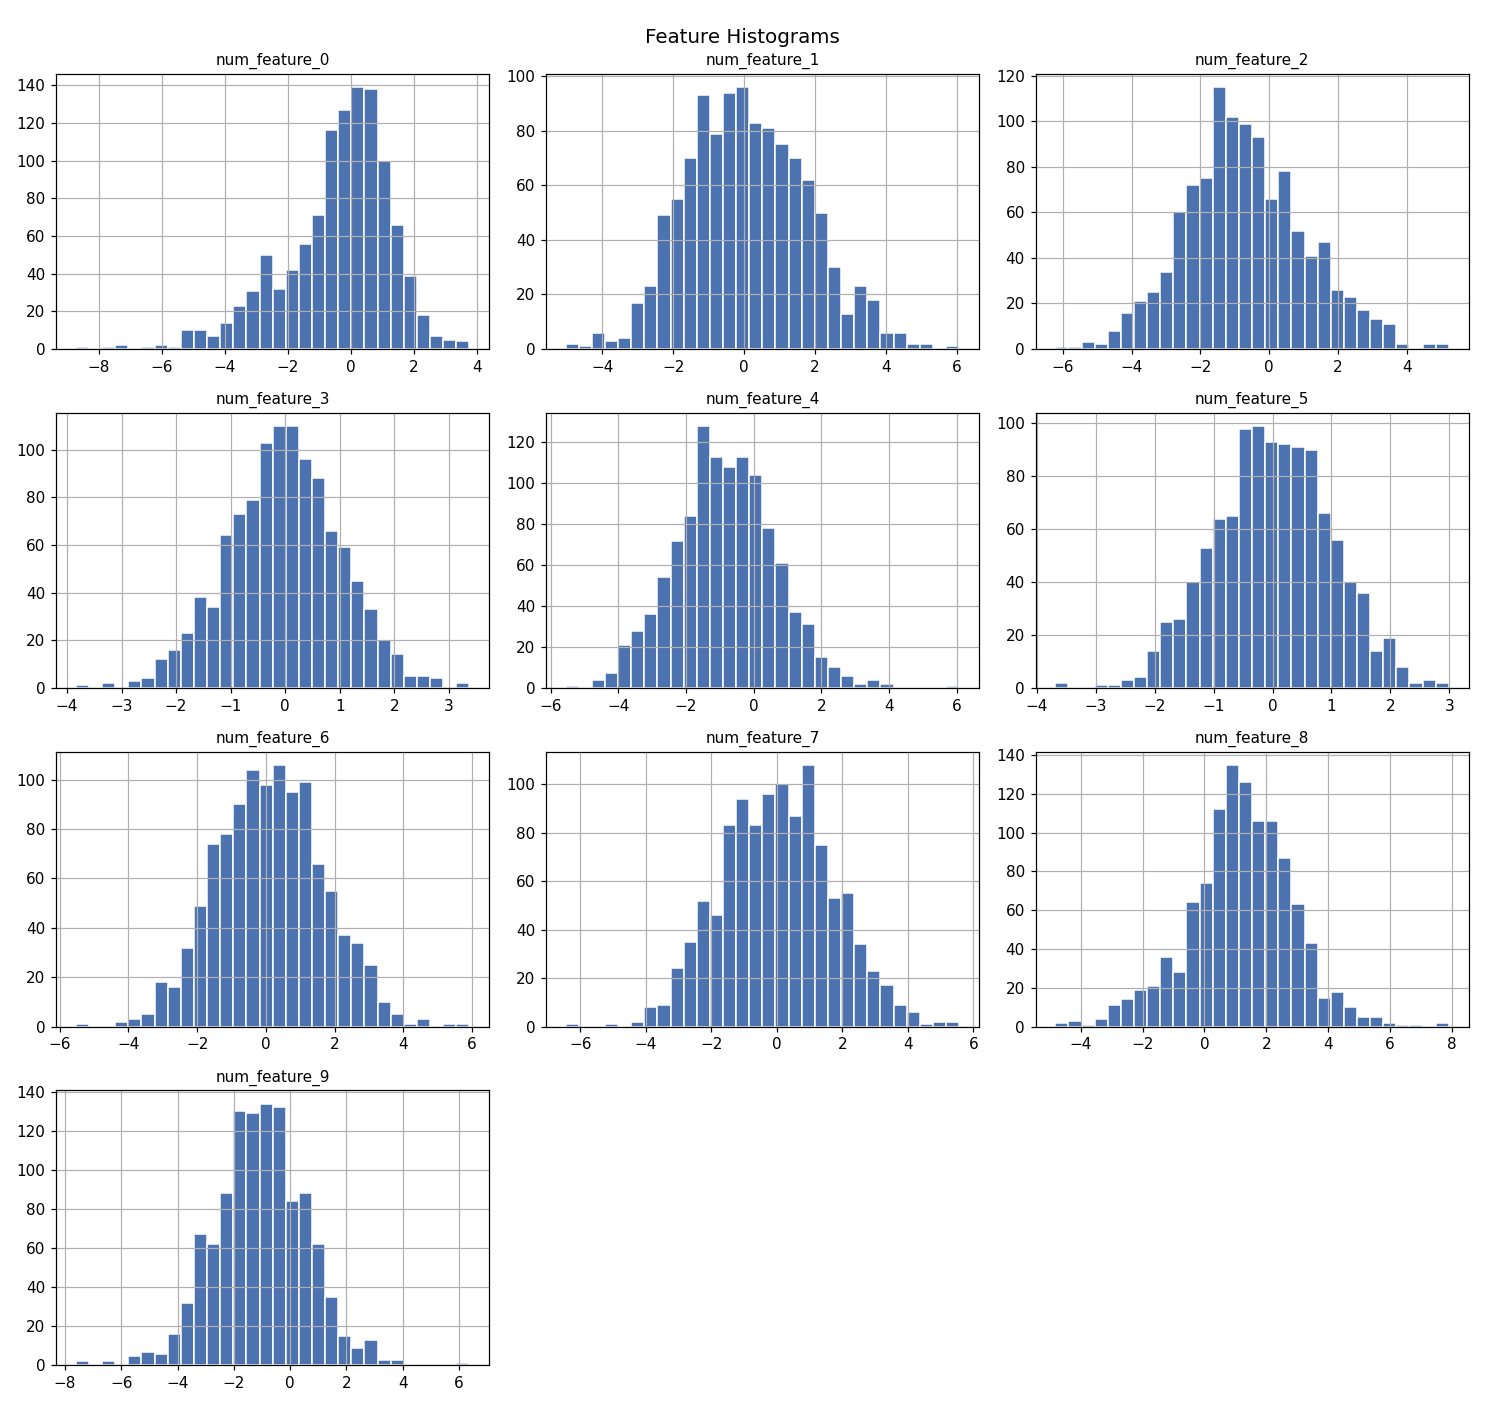

**Boxplots**

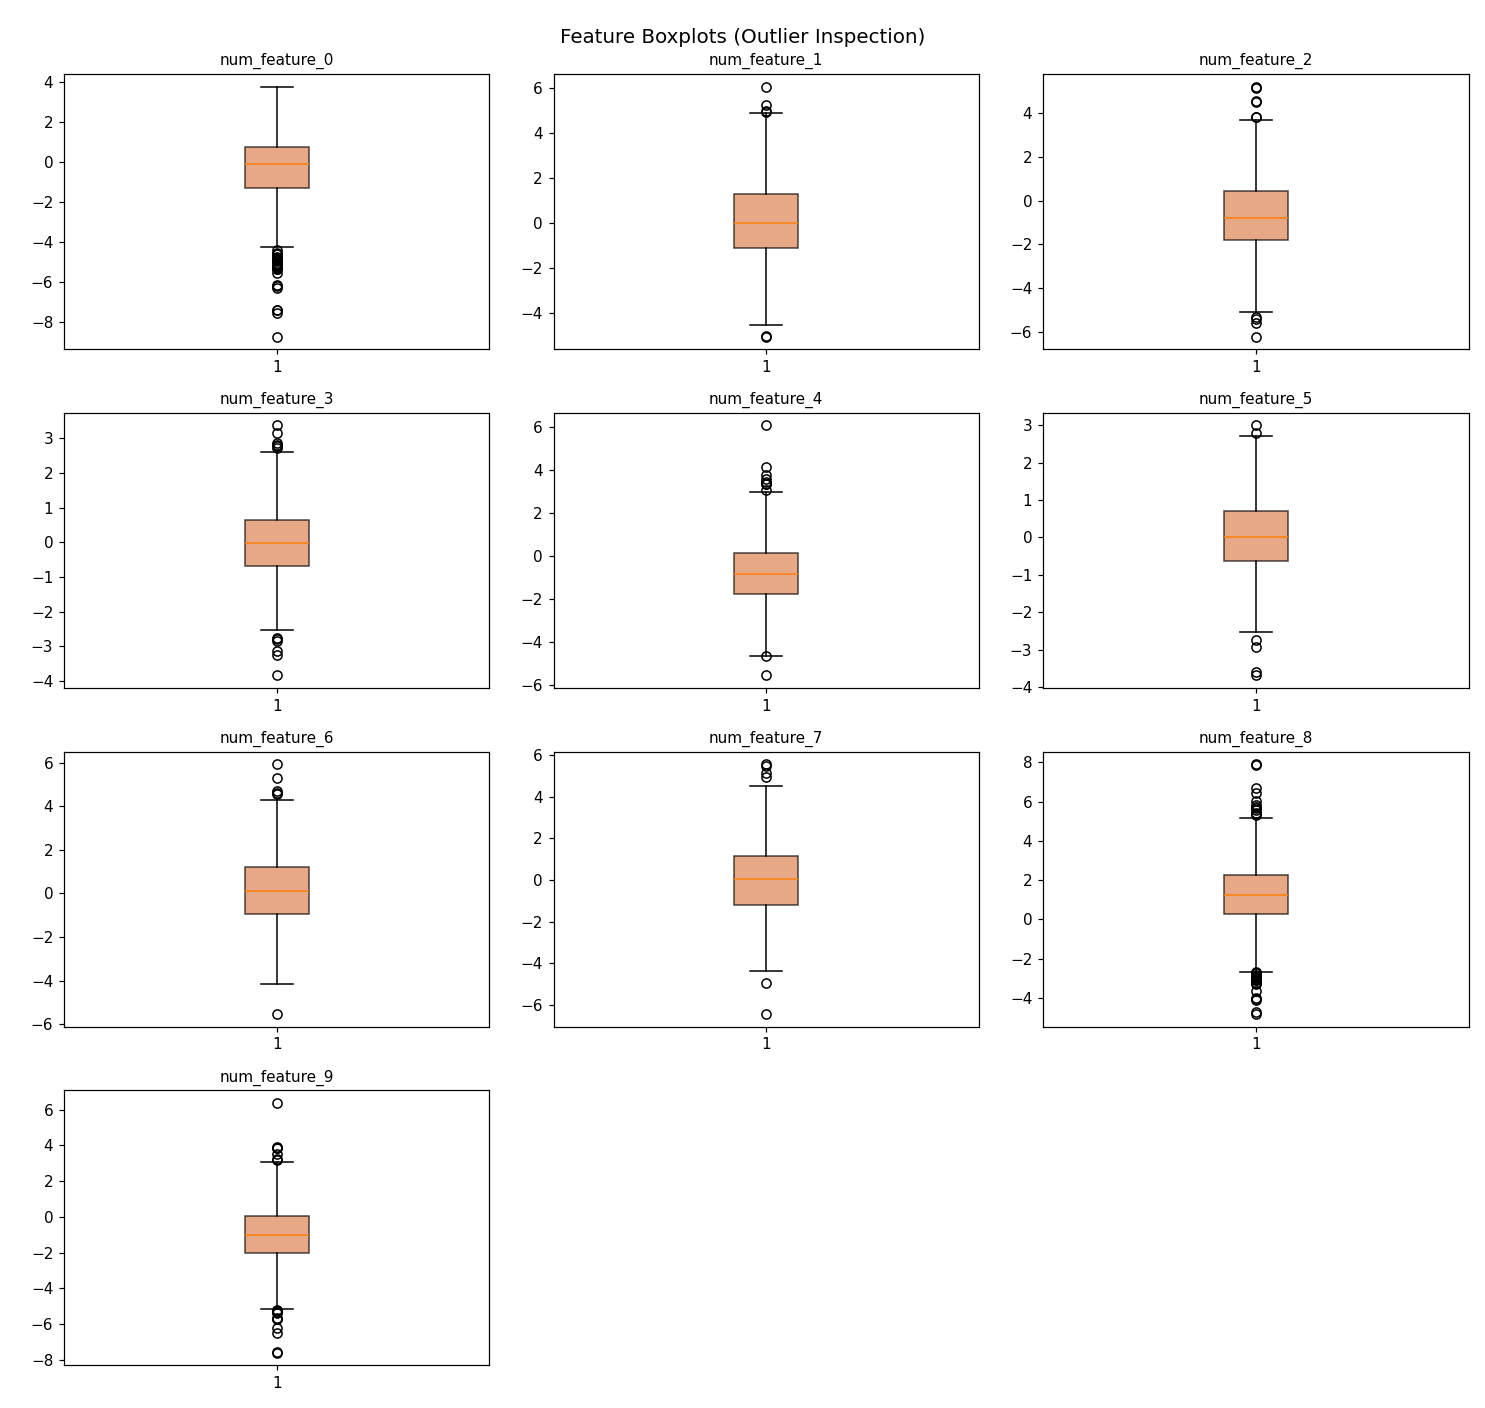

**Correlation Heatmap**

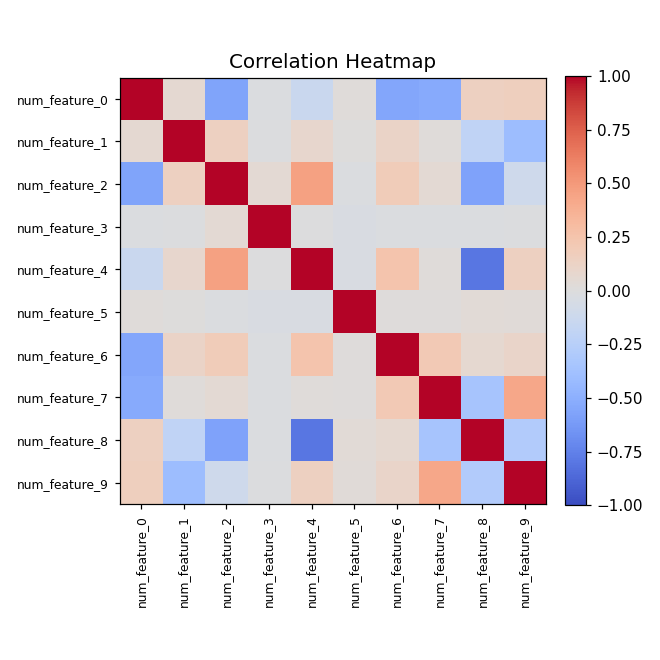

**Missing Values**

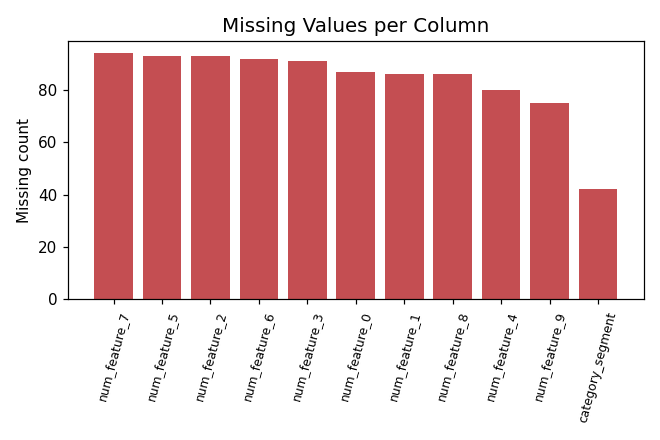

**Target Distribution**

### Agent Observations

- Dataset has 1200 rows and 13 feature columns (10 numerical, 3 categorical).

- Overall missingness is 5.47%.

- High-cardinality categorical column(s) detected: ['category_id_highcard'] — candidates for target/frequency encoding rather than one-hot.

...

## 5. Model Training Results

**Best model:** `LightGBM` (primary scorer: `f1_weighted`)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
CatBoost,0.9167,0.9127,0.9167,0.9101,0.8433
XGBoost,0.9125,0.9081,0.9125,0.9048,0.8658
LightGBM,0.9375,0.9369,0.9375,0.9330,0.8868


## 8. Explainability (SHAP)

**Explainer:** `TreeExplainer` on `LightGBM`

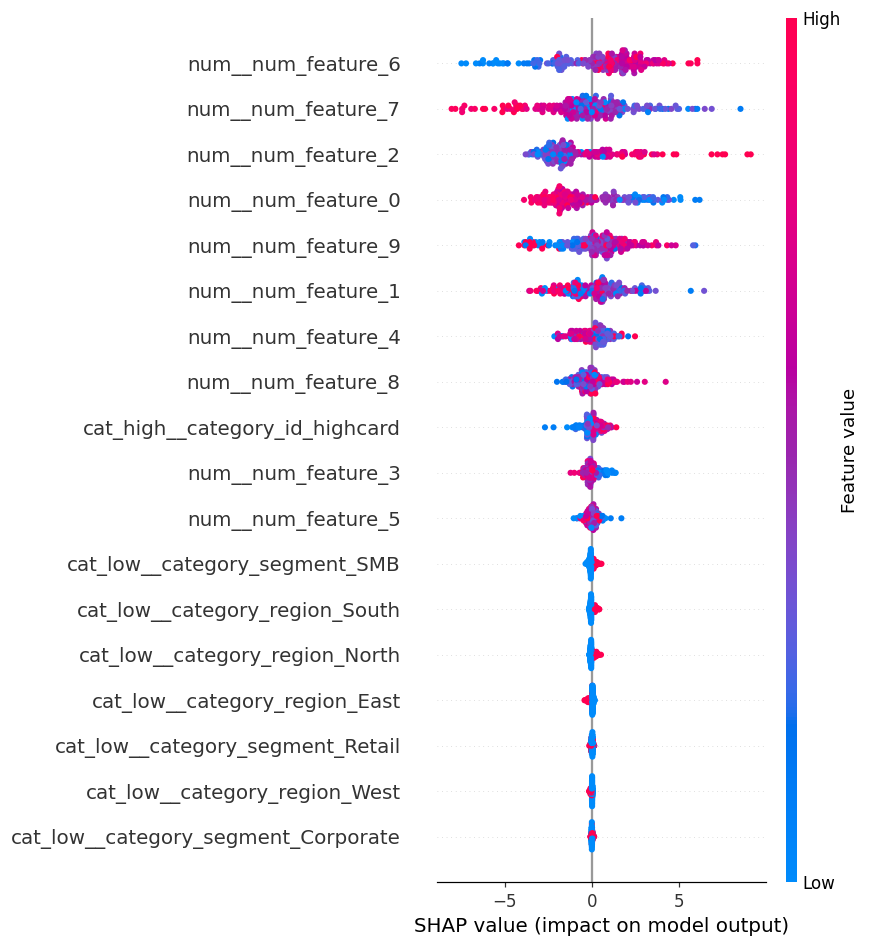

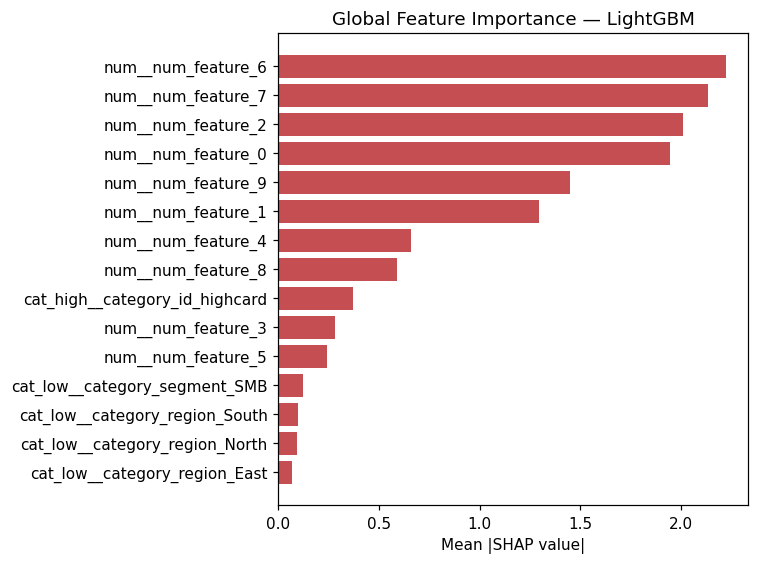

### Observations

- Top driver of `LightGBM` predictions: **num__num_feature_6** (mean |SHAP| = 2.2229).

- Explained 200 of 240 held-out rows using TreeExplainer against a 100-row background sample.

### Critic-Facing Explainability Notes

- 2 domain feature(s) contribute negligible signal and may be candidates for removal: ['category_region', 'category_segment'].

...

**Comments:** Reviewed 'LightGBM': train f1=1.000 vs held-out f1=0.933 (gap=0.067). No material issues found; approving the pipeline.

## 8. Memory

**Similar past runs retrieved before planning:**

_No similar past runs were found in memory (expected on the first run)._

**This run's experience score:** 0.812 (recommendation: `retain`)  
**Memory update decision:** `store_new` — No sufficiently similar memory found.  
**Total runs stored:** 1

In [29]:
# =============================================================================
# CELL 9 — DISPLAY OUTPUTS
# =============================================================================
from IPython.display import display, HTML, Image, Markdown, IFrame


def display_dataset_summary(state: PipelineState) -> None:
    """Render the Dataset Analyzer's metadata as a compact summary table."""
    metadata = state["metadata"]
    display(Markdown("## 1. Dataset Summary"))
    display(Markdown(
        f"**Source:** {state['dataset_source']}  \n"
        f"**Target column:** `{metadata['target_column']}`  \n"
        f"**Problem type:** `{metadata['problem_type']}`"
    ))

    summary_rows = {
        "Rows": metadata["n_rows"],
        "Feature columns": metadata["n_cols"],
        "Numerical columns": metadata["n_numerical"],
        "Categorical columns": metadata["n_categorical"],
        "High-cardinality columns": len(metadata["high_cardinality_columns"]) or "none",
        "Overall missingness": f"{metadata['pct_missing']:.2%}",
        "Class imbalance ratio": f"{metadata['imbalance_ratio']:.2f}" if metadata["problem_type"] == "classification" else "n/a",
        "Imbalanced?": metadata.get("is_imbalanced", False) if metadata["problem_type"] == "classification" else "n/a",
    }
    summary_df = pd.DataFrame(summary_rows.items(), columns=["Metric", "Value"])
    display(summary_df)

    if metadata["high_cardinality_columns"]:
        display(Markdown(f"**High-cardinality columns:** {metadata['high_cardinality_columns']}"))


def display_eda_section(state: PipelineState) -> None:
    """Render the EDA Agent's charts and structured observations."""
    eda = state["eda"]
    display(Markdown("## 2. Exploratory Data Analysis"))

    for name, path in eda["artifact_paths"].items():
        if not path or not os.path.exists(path):
            continue
        title = name.replace("_", " ").title()
        display(Markdown(f"**{title}**"))
        if path.endswith(".html"):
            display(IFrame(src=path, width=760, height=460))
        else:
            display(Image(filename=path))

    observations = eda["observations"]
    display(Markdown("### Agent Observations"))
    for obs in observations["key_observations"]:
        display(Markdown(f"- {obs}"))
    display(Markdown(
        f"- **Target balance:** {observations['target_balance_note']}\n"
        f"- **Correlation note:** {observations['correlation_note']}"
    ))


def display_feature_engineering_section(state: PipelineState) -> None:
    """Render the Feature Engineering Agent's decision and reasoning."""
    decision = state["features"]["decision"]
    display(Markdown("## 3. Feature Engineering Decision"))

    fe_rows = {
        "Imputation strategy": decision["imputation_strategy"],
        "Encoding strategy": decision["encoding_strategy"],
        "Scaling applied": decision["scaling"],
        "PCA used": decision["use_pca"],
        "PCA components": decision["pca_n_components"] or "n/a",
        "Feature selection k": decision["feature_selection_k"] or "n/a",
        "Imbalance handling": decision.get("handle_imbalance", False),
    }
    display(pd.DataFrame(fe_rows.items(), columns=["Setting", "Value"]))
    display(Markdown(f"**Reasoning:** {decision['reasoning']}"))


def display_model_recommendation_section(state: PipelineState) -> None:
    """Render the Model Recommendation Agent's ranked shortlist and rationale."""
    recommendation = state["model_recommendation"]
    display(Markdown("## 4. Model Recommendation"))

    rec_df = pd.DataFrame({
        "Rank": range(1, len(recommendation["ranked_models"]) + 1),
        "Model": recommendation["ranked_models"],
        "Reasoning": [recommendation["reasoning"][m] for m in recommendation["ranked_models"]],
    })
    display(rec_df)


def plot_model_comparison(state: PipelineState) -> None:
    """Bar chart (matplotlib) + interactive grouped bar (Plotly) comparing
    every trained candidate's held-out metrics, with the best model highlighted."""
    metrics = state["metrics"]
    per_model = metrics["per_model_test_metrics"]
    best_model_name = metrics["best_model_name"]
    problem_type = state["metadata"]["problem_type"]

    metrics_df = pd.DataFrame(per_model).T
    metrics_df.index.name = "model"

    display(Markdown("## 5. Model Training Results"))
    display(Markdown(
        f"**Best model:** `{best_model_name}` "
        f"(primary scorer: `{metrics['primary_scorer']}`)"
    ))
    display(metrics_df.round(4))

    primary_metric = "f1" if problem_type == "classification" else "rmse"
    ascending_is_better = primary_metric == "rmse"
    values = metrics_df[primary_metric]

    fig, ax = plt.subplots(figsize=(max(5, 1.3 * len(values)), 4))
    colors = [
        "#55A868" if model_name == best_model_name else "#4C72B0"
        for model_name in values.index
    ]
    ax.bar(values.index.astype(str), values.values, color=colors)
    ax.set_ylabel(primary_metric.upper())
    ax.set_title(f"Held-out {primary_metric.upper()} by Model"
                 f"{' (lower is better)' if ascending_is_better else ' (higher is better)'}")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    plt.show()

    fig_px = px.bar(
        metrics_df.reset_index(), x="model", y=primary_metric,
        color=metrics_df.reset_index()["model"].eq(best_model_name).map(
            {True: "Best model", False: "Candidate"}
        ),
        title=f"Interactive comparison — held-out {primary_metric.upper()}",
        labels={"color": ""},
    )
    fig_px.show()


def display_critic_section(state: PipelineState) -> None:
    """Render the Critic Agent's review verdict and any flagged issues."""
    critic = state["critic"]
    display(Markdown("## 7. Critic Review"))
    display(Markdown(f"**Recommendation:** `{critic['recommendation'].upper()}`"))

    critic_rows = {
        "Overfitting detected": critic["overfitting_detected"],
        "Leakage suspected": critic["leakage_suspected"],
        "Feature engineering OK": critic["feature_engineering_ok"],
        "Metrics acceptable": critic["metrics_acceptable"],
    }
    display(pd.DataFrame(critic_rows.items(), columns=["Check", "Result"]))

    if critic["issues"]:
        display(Markdown("**Issues raised:**"))
        for issue in critic["issues"]:
            display(Markdown(f"- {issue}"))
    display(Markdown(f"**Comments:** {critic['comments']}"))


def display_memory_section(state: PipelineState) -> None:
    """Render what the Memory Retrieval Agent found before planning, and
    what the Experience Scorer / Memory Update Policy decided to do with
    this run's outcome afterward."""
    display(Markdown("## 8. Memory"))

    retrieved = state.get("retrieved_memories", [])
    display(Markdown("**Similar past runs retrieved before planning:**"))
    if retrieved:
        display(pd.DataFrame([
            {"run_id": m["run_id"], "similarity": m["similarity"], "usefulness": m["usefulness"],
             "chosen_model": m.get("chosen_model"), "quality_label": m["quality_label"]}
            for m in retrieved
        ]))
    else:
        display(Markdown("_No similar past runs were found in memory (expected on the first run)._"))

    scored = state.get("experience_score")
    decision = state.get("memory_update_decision")
    if scored and decision:
        display(Markdown(
            f"**This run's experience score:** {scored['experience_score']:.3f} "
            f"(recommendation: `{scored['recommendation']}`)  \n"
            f"**Memory update decision:** `{decision['action']}` — {decision['reason']}  \n"
            f"**Total runs stored:** {decision.get('total_runs_stored', 'n/a')}"
        ))


def display_pipeline_outputs(state: PipelineState) -> None:
    """Render every section of the finished pipeline run, in actual graph
    execution order (Task 4, architecture audit — SHAP now runs between
    Training and the Critic): dataset summary -> EDA -> feature engineering
    -> model recommendation -> training results -> explainability (SHAP) ->
    critic review -> memory (retrieval + experience/update)."""
    display_dataset_summary(state)
    display_eda_section(state)
    display_feature_engineering_section(state)
    display_model_recommendation_section(state)
    plot_model_comparison(state)
    display_explainability_section(state)  # NEW — Task 4, defined in Cell 10
    display_critic_section(state)
    display_memory_section(state)


display_pipeline_outputs(final_state)


In [30]:
# =============================================================================
# CELL 11 — MARKDOWN REPORT GENERATOR
# =============================================================================
def _format_metrics_table(metrics: dict[str, float]) -> str:
    """Render a flat metrics dict as a two-column Markdown table."""
    rows = "\n".join(f"| {name} | {value:.4f} |" for name, value in metrics.items())
    return f"| Metric | Value |\n|---|---|\n{rows}"


def _format_model_comparison_table(metrics: dict[str, Any]) -> str:
    """Render every trained candidate's held-out metrics as one Markdown table,
    bolding the best model's row."""
    per_model = metrics["per_model_test_metrics"]
    best_model_name = metrics["best_model_name"]
    metric_names = list(next(iter(per_model.values())).keys())

    header = "| Model | " + " | ".join(m.upper() for m in metric_names) + " |"
    divider = "|---|" + "---|" * len(metric_names)
    rows = []
    for model_name, model_metrics in per_model.items():
        values = " | ".join(f"{model_metrics[m]:.4f}" for m in metric_names)
        label = f"**{model_name}**" if model_name == best_model_name else model_name
        rows.append(f"| {label} | {values} |")
    return "\n".join([header, divider, *rows])


def _format_experience_section(state: PipelineState) -> str:
    scored = state.get("experience_score", {})
    decision = state.get("memory_update_decision", {})
    lines = [
        "## Experience & Memory",
        f"- **Experience score:** {scored.get('experience_score', 'n/a')}",
        f"- **Generalization score:** {scored.get('generalization_score', 'n/a')}",
        f"- **Confidence:** {scored.get('confidence', 'n/a')}",
        f"- **Scorer reasoning:** {scored.get('reasoning', 'n/a')}",
        "",
        f"- **Memory update action:** {decision.get('action', 'n/a')}",
        f"- **Stored?** {'Yes' if decision.get('action') in ('store_new', 'replace', 'merge') else 'No'}",
        f"- **Replaced existing memory?** {'Yes — run ' + str(decision.get('replaced_run_id')) if decision.get('action') == 'replace' else 'No'}",
        f"- **Reason:** {state.get('update_reason', 'n/a')}",
    ]
    similar = state.get("similar_memories", [])
    if similar:
        lines.append("\n**Retrieved similar memories considered:**")
        for m in similar:
            lines.append(f"- run {m['run_id']} (similarity={m['similarity']:.2f}, model={m.get('chosen_model')})")
    return "\n".join(lines)

def _generate_future_improvements(state: PipelineState) -> list[str]:
    """Deterministic, rule-based suggestions for next iterations — derived
    from the same dataset/critic signals the Planner and Critic already
    reasoned over, rather than free-form LLM speculation."""
    metadata = state["metadata"]
    critic = state["critic"]
    retrieved_memories = state.get("retrieved_memories", [])
    suggestions: list[str] = []

    if metadata["is_imbalanced"]:
        suggestions.append(
            "Address class imbalance explicitly (e.g. class weighting, SMOTE, "
            "or a threshold-tuned decision boundary) rather than relying on "
            "weighted averaging in the metrics alone."
        )
    if metadata["pct_missing"] > 0.05:
        suggestions.append(
            "Investigate the missingness mechanism (MCAR/MAR/MNAR) rather "
            "than defaulting to median/most-frequent imputation, since >5% "
            "of cells are missing overall."
        )
    if metadata["high_cardinality_columns"]:
        suggestions.append(
            "Revisit encoding for high-cardinality columns "
            f"({', '.join(metadata['high_cardinality_columns'])}) — target or "
            "frequency encoding may generalize better than the current strategy."
        )
    if critic["issues"]:
        suggestions.append(
            "Resolve the Critic's outstanding issues before treating this "
            "run's metrics as final: " + "; ".join(critic["issues"])
        )
    if not retrieved_memories:
        suggestions.append(
            "No similar past runs existed in memory for this dataset fingerprint — "
            "future runs on related datasets should retrieve and reuse this run's "
            "successful configuration."
        )
    suggestions.append(
        f"Expand the Optuna budget past {CFG.n_optuna_trials} trials on "
        f"`{state['models']['best_model_name']}` specifically, now that it is "
        "the identified best candidate rather than one of several unknowns."
    )
    return suggestions


def generate_markdown_report(state: PipelineState) -> str:
    """Assemble the full run report as a single Markdown string, in the order
    specified by the master prompt: dataset summary, EDA, preprocessing,
    model, metrics, critic comments, memory usage, future improvements.
    """
    metadata = state["metadata"]
    eda = state["eda"]
    decision = state["features"]["decision"]
    recommendation = state["model_recommendation"]
    metrics = state["metrics"]
    critic = state["critic"]
    explainability_summary = state.get("explainability", {})

    sections: list[str] = []

    sections.append(
        f"# Pipeline Report — {state['dataset_source']}\n\n"
        f"_Generated {datetime.now().isoformat(timespec='seconds')}_"
    )

    sections.append(
        "## 1. Dataset Summary\n\n"
        f"- **Target column:** `{metadata['target_column']}`\n"
        f"- **Problem type:** `{metadata['problem_type']}`\n"
        f"- **Shape:** {metadata['n_rows']} rows × {metadata['n_cols']} feature columns "
        f"({metadata['n_numerical']} numerical, {metadata['n_categorical']} categorical)\n"
        f"- **Missingness:** {metadata['pct_missing']:.2%} overall\n"
        f"- **Class imbalance ratio:** "
        f"{metadata['imbalance_ratio']:.2f} (imbalanced={metadata['is_imbalanced']})"
        if metadata["problem_type"] == "classification"
        else f"- **Missingness:** {metadata['pct_missing']:.2%} overall"
    )

    observations = eda["observations"]
    sections.append(
        "## 2. Exploratory Data Analysis\n\n"
        + "\n".join(f"- {obs}" for obs in observations["key_observations"])
        + f"\n- **Target balance:** {observations['target_balance_note']}"
        + f"\n- **Correlation note:** {observations['correlation_note']}"
    )

    sections.append(
        "## 3. Feature Engineering\n\n"
        f"- **Imputation:** {decision['imputation_strategy']}\n"
        f"- **Encoding:** {decision['encoding_strategy']}\n"
        f"- **Scaling:** {decision['scaling']}\n"
        f"- **PCA:** {decision['use_pca']}"
        + (f" ({decision['pca_n_components']} components)" if decision["use_pca"] else "")
        + f"\n- **Feature selection k:** {decision['feature_selection_k'] or 'n/a'}"
        + f"\n- **Imbalance handling:** {decision.get('handle_imbalance', False)}\n\n"
        f"**Reasoning:** {decision['reasoning']}"
    )

    sections.append(
        "## 4. Model Selection\n\n"
        f"**Chosen model:** `{metrics['best_model_name']}`\n\n"
        "**Candidates considered, in ranked order:**\n\n"
        + "\n".join(
            f"{i}. **{m}** — {recommendation['reasoning'][m]}"
            for i, m in enumerate(recommendation["ranked_models"], start=1)
        )
    )

    sections.append(
        "## 5. Metrics\n\n"
        f"Primary scorer: `{metrics['primary_scorer']}`\n\n"
        "**Best model held-out metrics:**\n\n"
        f"{_format_metrics_table(metrics['best_model_metrics'])}\n\n"
        "**All candidates compared:**\n\n"
        f"{_format_model_comparison_table(metrics)}"
    )

    # Task 4/12: the report is a presentation-layer consumer of PipelineState,
    # not part of the graph, so it recomputes SHAP with plots-off to get the
    # full ranked feature list for the write-up (state["explainability"] only
    # holds the compact ExplainabilitySummary the Critic reasoned over —
    # Task 5 — which is included below as "Critic-facing notes").
    try:
        shap_full = run_shap_explainability(state, generate_plots=False)
        top5 = list(zip(shap_full["ranked_features"][:5], shap_full["ranked_importance"][:5]))
        critic_notes = explainability_summary.get("critic_explainability_notes", [])
        sections.append(
            "## 6. Explainability (SHAP)\n\n"
            f"Explainer: `{shap_full['explainer_type']}`\n\n"
            "**Top 5 features by mean |SHAP|:**\n\n"
            + "\n".join(f"{i}. `{name}` — {value:.4f}" for i, (name, value) in enumerate(top5, start=1))
            + "\n\n"
            + "\n".join(f"- {obs}" for obs in shap_full["observations"])
            + ("\n\n**Critic-facing explainability notes:**\n\n" + "\n".join(f"- {n}" for n in critic_notes)
               if critic_notes else "")
        )
    except Exception as exc:
        sections.append(f"## 6. Explainability (SHAP)\n\n_Not available: {exc}_")

    sections.append(
        "## 7. Critic Review\n\n"
        f"**Recommendation:** `{critic['recommendation'].upper()}`\n\n"
        f"- Overfitting detected: {critic['overfitting_detected']}\n"
        f"- Leakage suspected: {critic['leakage_suspected']}\n"
        f"- Feature engineering OK: {critic['feature_engineering_ok']}\n"
        f"- Metrics acceptable: {critic['metrics_acceptable']}\n\n"
        + ("**Issues raised:**\n" + "\n".join(f"- {issue}" for issue in critic["issues"]) + "\n\n" if critic["issues"] else "")
        + f"**Comments:** {critic['comments']}"
    )

    sections.append(
        "## 8. Memory\n\n"
        + (
            "**Similar past runs retrieved before planning:**\n"
            + "\n".join(
                f"  - run {m['run_id']} (similarity={m['similarity']:.2f}, "
                f"usefulness={state.get('retrieval_scores', {}).get(m['run_id'], m.get('usefulness', 0.0)):.2f}, "
                f"model={m.get('chosen_model')})"
                for m in state.get("retrieved_memories", [])
            )
            if state.get("retrieved_memories")
            else "No similar past runs were found in memory (expected on the first run)."
        )
    )

    sections.append(
        "## 9. Future Improvements\n\n"
        + "\n".join(f"- {s}" for s in _generate_future_improvements(state))
    )

    sections.append(_format_experience_section(state))

    n_iterations = max((e.get("iteration", 0) for e in state.get("history", [])), default=0)
    sections.append(
        "## Appendix: Execution Trace\n\n"
        f"Total revision iterations: {state.get('iteration', 0)}\n\n"
        + "\n".join(
            f"{i}. `{e['node']}` — status={e['status']}"
            for i, e in enumerate(state.get("history", []), start=1)
        )
    )

    return "\n\n".join(sections) + "\n"


def report_generation_node(state: PipelineState) -> PipelineState:
    """LangGraph-style node: build the Markdown report and persist it to
    `CFG.artifacts_dir/pipeline_report.md`."""
    report_md = generate_markdown_report(state)
    report_path = os.path.join(CFG.artifacts_dir, "pipeline_report.md")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_md)

    state["report"] = report_md
    state.setdefault("history", []).append({"node": "report_generation", "status": "ok", "path": report_path})
    return state


# ---- Smoke test (reuses final_state populated by Cells 8-9; run_shap_explainability
# is recomputed above for the report, since state["explainability"] only carries
# the compact Critic-facing summary, not the full ranked feature list) ------
final_state = report_generation_node(final_state)
print(f"Report written to: {os.path.join(CFG.artifacts_dir, 'pipeline_report.md')} "
      f"({len(final_state['report'])} characters)")
display(Markdown(final_state["report"]))


Report written to: artifacts/pipeline_report.md (6552 characters)


# Pipeline Report — synthetic fallback dataset (make_classification-based)

_Generated 2026-07-26T06:55:44_

## 1. Dataset Summary

- **Target column:** `target`
- **Problem type:** `classification`
- **Shape:** 1200 rows × 13 feature columns (10 numerical, 3 categorical)
- **Missingness:** 5.47% overall
- **Class imbalance ratio:** 5.35 (imbalanced=True)

## 2. Exploratory Data Analysis

- Dataset has 1200 rows and 13 feature columns (10 numerical, 3 categorical).
- Overall missingness is 5.47%.
- High-cardinality categorical column(s) detected: ['category_id_highcard'] — candidates for target/frequency encoding rather than one-hot.
- Strongest numerical correlation is between 'num_feature_4' and 'num_feature_8' (r=-0.80).
- **Target balance:** Target is imbalanced (majority:minority ratio = 5.35).
- **Correlation note:** Top correlated numerical pairs: [('num_feature_4', 'num_feature_8', -0.8), ('num_feature_2', 'num_feature_8', -0.57), ('num_feature_0', 'num_feature_2', -0.57)].

## 3. Feature Engineering

- **Imputation:** median
- **Encoding:** mixed
- **Scaling:** True
- **PCA:** False
- **Feature selection k:** n/a
- **Imbalance handling:** True

**Reasoning:** Planner decision supplied — used as the primary execution plan; metadata heuristics applied only where the Planner was silent. 10 numerical / 3 categorical columns detected. Imputation='median' chosen based on the Planner recommendation. Encoding='mixed': low-cardinality categoricals (['category_region', 'category_segment']) get one-hot, high-cardinality columns (['category_id_highcard']) get ordinal encoding to avoid dimensionality blow-up. Scaling=enabled (per Planner). Imbalance handling enabled (class_weight='balanced' where supported) (per Planner).

## 4. Model Selection

**Chosen model:** `LightGBM`

**Candidates considered, in ranked order:**

1. **CatBoost** — (score=4.5) Gradient/ensemble tree model — robust to feature scale and nonlinear interactions. Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models. Supports native class-weighting to counter the observed target imbalance. Best native categorical-feature handling of the ensemble family.
2. **XGBoost** — (score=4.0) Gradient/ensemble tree model — robust to feature scale and nonlinear interactions. Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models. Supports native class-weighting to counter the observed target imbalance.
3. **LightGBM** — (score=4.0) Gradient/ensemble tree model — robust to feature scale and nonlinear interactions. Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models. Supports native class-weighting to counter the observed target imbalance.
4. **Random Forest** — (score=3.5) Gradient/ensemble tree model — robust to feature scale and nonlinear interactions. Tolerates the high-cardinality categorical column(s) better than one-hot-heavy linear models.
5. **Logistic Regression** — (score=2.0) Simple, interpretable, fast-to-train baseline; well suited to a low-dimensional (13 feature) setting where linear decision boundaries are a reasonable prior.
6. **SVM** — (score=1.7) Kernel methods can capture nonlinear boundaries on small-to-medium data (1200 rows), but training cost grows poorly beyond a few thousand rows.

## 5. Metrics

Primary scorer: `f1_weighted`

**Best model held-out metrics:**

| Metric | Value |
|---|---|
| accuracy | 0.9375 |
| precision | 0.9369 |
| recall | 0.9375 |
| f1 | 0.9330 |
| roc_auc | 0.8868 |

**All candidates compared:**

| Model | ACCURACY | PRECISION | RECALL | F1 | ROC_AUC |
|---|---|---|---|---|---|
| CatBoost | 0.9167 | 0.9127 | 0.9167 | 0.9101 | 0.8433 |
| XGBoost | 0.9125 | 0.9081 | 0.9125 | 0.9048 | 0.8658 |
| **LightGBM** | 0.9375 | 0.9369 | 0.9375 | 0.9330 | 0.8868 |

## 6. Explainability (SHAP)

Explainer: `TreeExplainer`

**Top 5 features by mean |SHAP|:**

1. `num__num_feature_6` — 2.2229
2. `num__num_feature_7` — 2.1330
3. `num__num_feature_2` — 2.0123
4. `num__num_feature_0` — 1.9454
5. `num__num_feature_9` — 1.4495

- Top driver of `LightGBM` predictions: **num__num_feature_6** (mean |SHAP| = 2.2229).
- Explained 200 of 240 held-out rows using TreeExplainer against a 100-row background sample.

**Critic-facing explainability notes:**

- 2 domain feature(s) contribute negligible signal and may be candidates for removal: ['category_region', 'category_segment'].

## 7. Critic Review

**Recommendation:** `APPROVE`

- Overfitting detected: False
- Leakage suspected: False
- Feature engineering OK: True
- Metrics acceptable: True

**Comments:** Reviewed 'LightGBM': train f1=1.000 vs held-out f1=0.933 (gap=0.067). No material issues found; approving the pipeline.

## 8. Memory

No similar past runs were found in memory (expected on the first run).

## 9. Future Improvements

- Address class imbalance explicitly (e.g. class weighting, SMOTE, or a threshold-tuned decision boundary) rather than relying on weighted averaging in the metrics alone.
- Investigate the missingness mechanism (MCAR/MAR/MNAR) rather than defaulting to median/most-frequent imputation, since >5% of cells are missing overall.
- Revisit encoding for high-cardinality columns (category_id_highcard) — target or frequency encoding may generalize better than the current strategy.
- No similar past runs existed in memory for this dataset fingerprint — future runs on related datasets should retrieve and reuse this run's successful configuration.
- Expand the Optuna budget past 20 trials on `LightGBM` specifically, now that it is the identified best candidate rather than one of several unknowns.

## Experience & Memory
- **Experience score:** 0.8116
- **Generalization score:** 0.75
- **Confidence:** 0.7
- **Scorer reasoning:** performance=0.93, robustness=0.50, overfitting_penalty=1.00, critic_confidence=0.90, planner_confidence=0.50, preprocessing_quality=1.00 => experience_score=0.812 (retain)

- **Memory update action:** store_new
- **Stored?** Yes
- **Replaced existing memory?** No
- **Reason:** No sufficiently similar memory found.

## Appendix: Execution Trace

Total revision iterations: 1

1. `dataset_analyzer` — status=ok
2. `memory_retrieval` — status=ok
3. `planner` — status=ok
4. `eda_agent` — status=ok
5. `feature_engineering_agent` — status=ok
6. `model_recommendation_agent` — status=ok
7. `training_agent` — status=ok
8. `shap_explainability` — status=ok
9. `critic_agent` — status=ok
10. `experience_scorer` — status=ok
11. `memory_update_policy` — status=ok
